In [1]:
import re
import string
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
import emoji
import langdetect
import langid
import itertools
import contractions
import enchant
import scipy.stats as stats
import pickle

from scipy.stats import chi2_contingency, ttest_ind, uniform
from scipy.sparse import save_npz, load_npz
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from spellchecker import SpellChecker
from nltk import pos_tag, ngrams
from nltk.tokenize import word_tokenize, regexp_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from collections import Counter
from langdetect import detect, DetectorFactory, LangDetectException
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [2]:
data = pd.read_csv('Financial Consumer Complaint.csv')
data

C:\Users\KELLY CHONG\AppData\Local\Temp\ipykernel_25564\3119238246.py:1: DtypeWarning: Columns (4,5,6,11,16) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('Financial Consumer Complaint.csv')


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282350,12/01/2011,Credit card,NaN,Credit determination,NaN,NaN,NaN,"CITIBANK, N.A.",MO,63301,NaN,NaN,Web,12/02/2011,Closed with relief,Yes,No,2396
1282351,12/01/2011,Mortgage,Conventional fixed mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,"BANK OF AMERICA, NATIONAL ASSOCIATION",OH,45248,NaN,NaN,Web,12/06/2011,Closed without relief,No,No,2323
1282352,12/01/2011,Credit card,NaN,Billing disputes,NaN,NaN,NaN,JPMORGAN CHASE & CO.,OH,43207,NaN,NaN,Referral,12/01/2011,Closed with relief,Yes,No,2126
1282353,12/01/2011,Mortgage,Conventional adjustable mortgage (ARM),"Loan servicing, payments, escrow account",NaN,NaN,NaN,"BANK OF AMERICA, NATIONAL ASSOCIATION",CO,80920,NaN,NaN,Web,12/01/2011,Closed with relief,Yes,No,2315


In [4]:
# Display dataset column basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 18 columns):
 #   Column                        Non-Null Count    Dtype   
---  ------                        --------------    -----   
 0   Date received                 1282355 non-null  object  
 1   Product                       1282355 non-null  object  
 2   Sub-product                   1047189 non-null  object  
 3   Issue                         1282355 non-null  object  
 4   Sub-issue                     751169 non-null   object  
 5   Consumer complaint narrative  383564 non-null   object  
 6   Company public response       449082 non-null   object  
 7   Company                       1282355 non-null  object  
 8   State                         1262955 non-null  object  
 9   ZIP code                      1167057 non-null  object  
 10  Tags                          175643 non-null   object  
 11  Consumer consent provided?    690654 non-null   object  
 12  Submitted via 

In [3]:
# Convert Complaint ID column to categorical to see the actual statistics
data['Complaint ID'] = data['Complaint ID'].astype('category')

# Display basic information of each columns
data.describe(include='all')

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
count,1282355,1282355,1047189,1282355,751169,383564,449082,1282355,1262955,1167057,175643,690654,1282355,1282355,1282348,1282355,768501,1282355
unique,2717,18,76,167,218,366945,10,5275,63,22591,3,4,6,2666,8,2,2,1282355
top,09/08/2017,Mortgage,Credit reporting,Incorrect information on your report,Information belongs to someone else,There are many mistakes appear in my report wi...,Company has responded to the consumer and the ...,"EQUIFAX, INC.",CA,300XX,Servicemember,Consent provided,Web,09/08/2017,Closed with explanation,Yes,No,3238682
freq,3553,278098,221652,134338,59168,978,311852,115703,176009,7294,84654,383885,945329,3387,993221,1250162,620123,1


In [5]:
# Check for missing values of each column
print("Null or NAN value count:")
print(data.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", data.duplicated().sum())

Null or NAN value count:
Date received                         0
Product                               0
Sub-product                      235166
Issue                                 0
Sub-issue                        531186
Consumer complaint narrative     898791
Company public response          833273
Company                               0
State                             19400
ZIP code                         115298
Tags                            1106712
Consumer consent provided?       591701
Submitted via                         0
Date sent to company                  0
Company response to consumer          7
Timely response?                      0
Consumer disputed?               513854
Complaint ID                          0
dtype: int64

Duplicate rows: 0


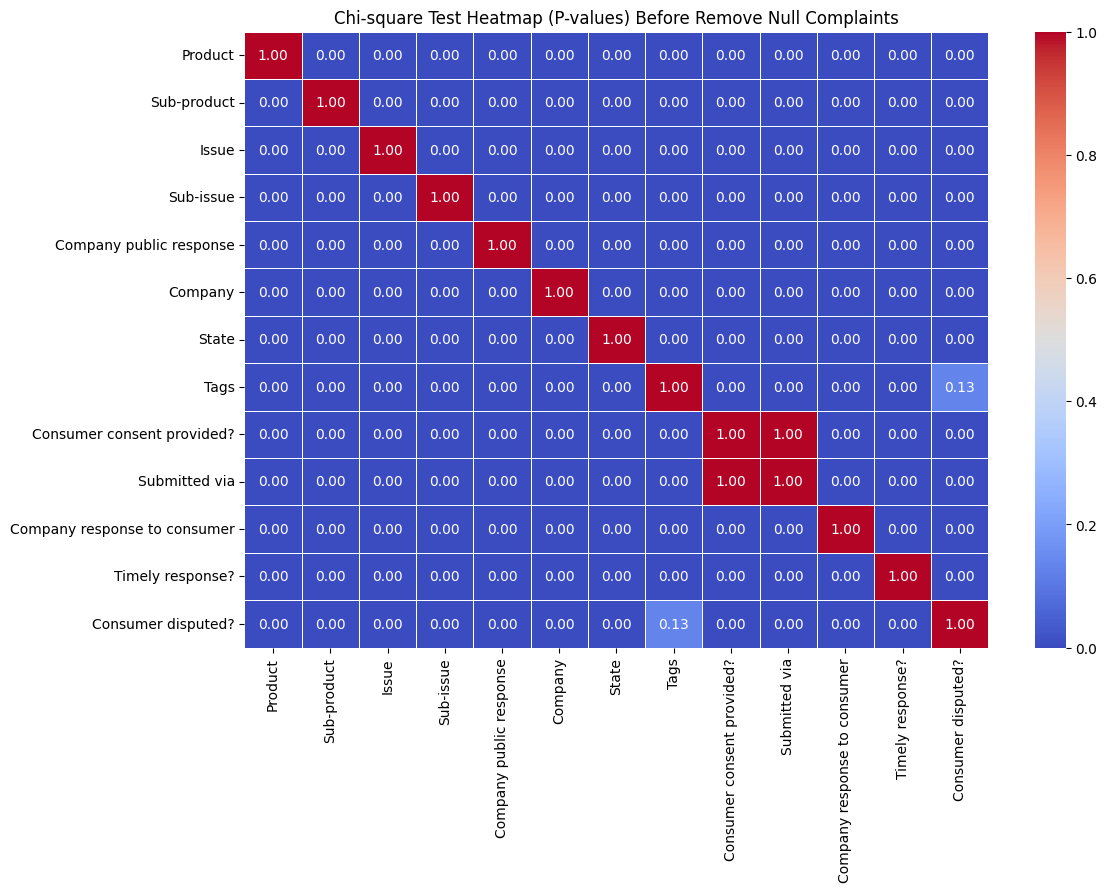

In [6]:
""" Conduct Chi-Square test for categorical variables"""

# Select only categorical columns
categorical_cols = ['Product', 'Sub-product', 'Issue', 'Sub-issue', 
                    'Company public response', 'Company', 'State', 'Tags', 
                    'Consumer consent provided?', 'Submitted via', 
                    'Company response to consumer', 'Timely response?', 'Consumer disputed?']

# Create an empty DataFrame to store p-values
chi2_results = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

# Compute Chi-square test and p-value for each pair of categorical variables
for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            chi2_results.loc[col1, col2] = 1.0  # Set diagonal to 1
        else:
            # Create contingency table
            contingency_table = pd.crosstab(data[col1], data[col2])
            # Perform Chi-square test
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            # Store p-value in the matrix
            chi2_results.loc[col1, col2] = p

chi2_results = chi2_results.astype(float)

# Plot heatmap
plt.figure(figsize=(12, 8))
sb.heatmap(chi2_results, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Chi-square Test Heatmap (P-values) Before Remove Null Complaints")
plt.show()

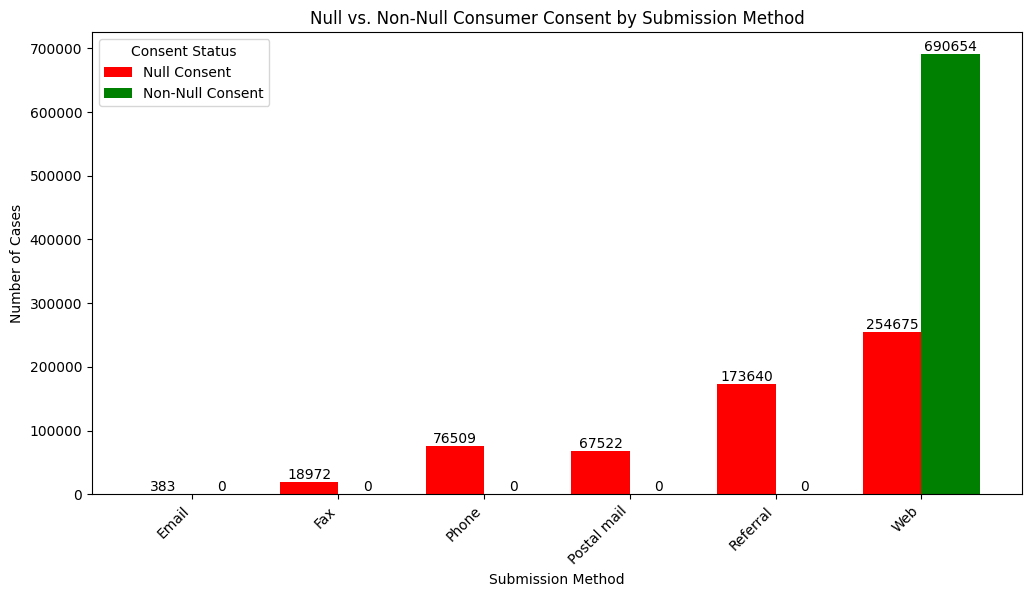

In [7]:
""" Examine why Submitted via and Consumer consent provided? is 1.0 p-value """

# Group by 'Submitted via' and count null/non-null consent provided
consent_null_counts = data.groupby('Submitted via')['Consumer consent provided?'].agg([
    lambda x: x.isna().sum(),
    lambda x: x.notna().sum()
]).rename(columns={'<lambda_0>': 'Null Consent', '<lambda_1>': 'Non-Null Consent'})

# Create separate bar charts (side-by-side)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(consent_null_counts))
width = 0.4
bars1 = ax.bar(x - width/2, consent_null_counts['Null Consent'], 
               width=width, label='Null Consent', color='red')
bars2 = ax.bar(x + width/2, consent_null_counts['Non-Null Consent'], 
               width=width, label='Non-Null Consent', color='green')
for bars in [bars1, bars2]:  
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', 
                ha='center', va='bottom', fontsize=10, color='black')
ax.set_xlabel('Submission Method')
ax.set_ylabel('Number of Cases')
ax.set_title('Null vs. Non-Null Consumer Consent by Submission Method')
ax.set_xticks(x)
ax.set_xticklabels(consent_null_counts.index, rotation=45, ha='right')
ax.legend(title="Consent Status")
plt.show()

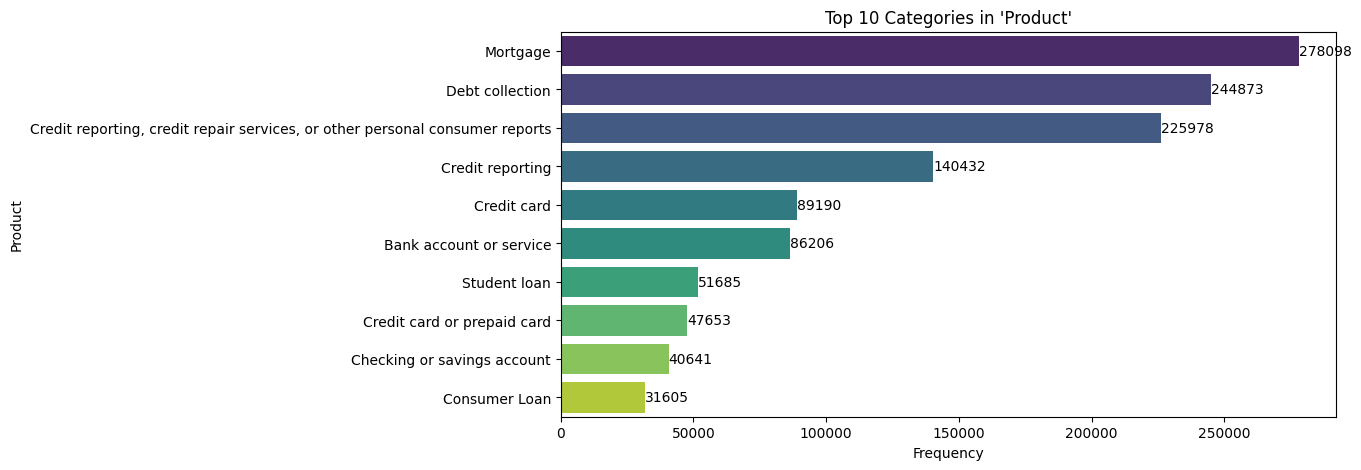

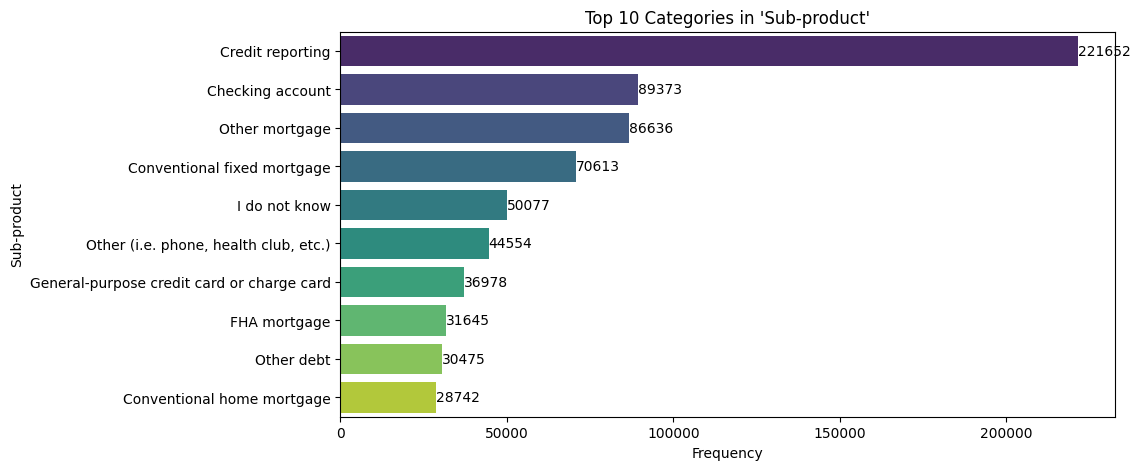

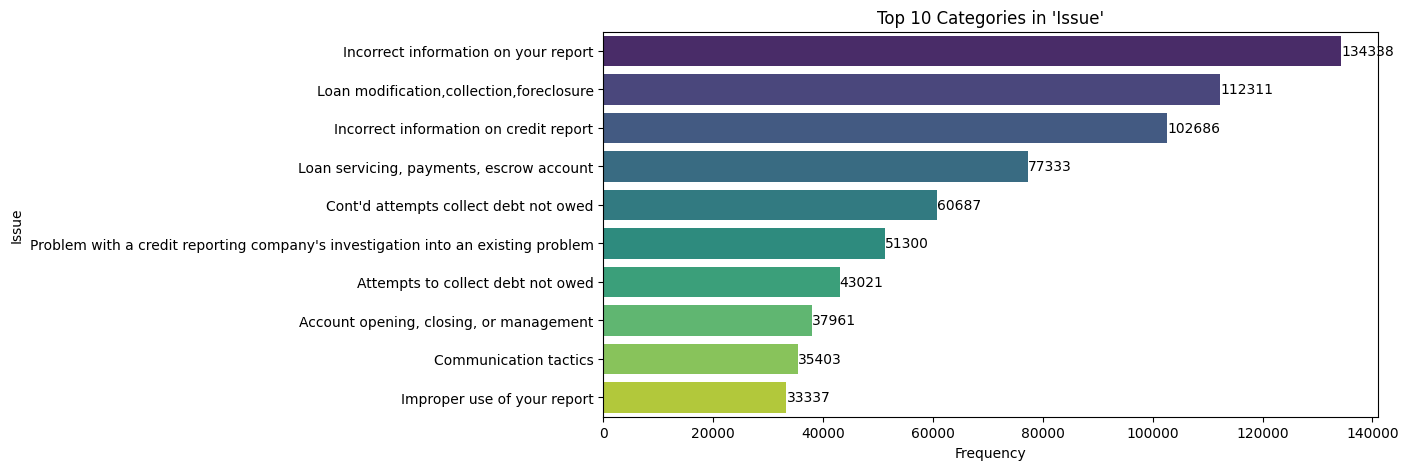

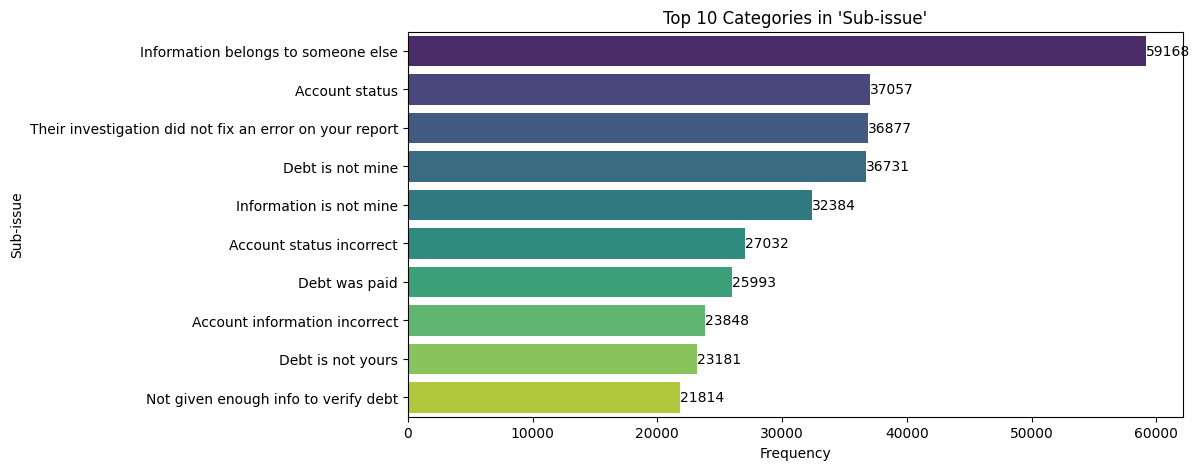

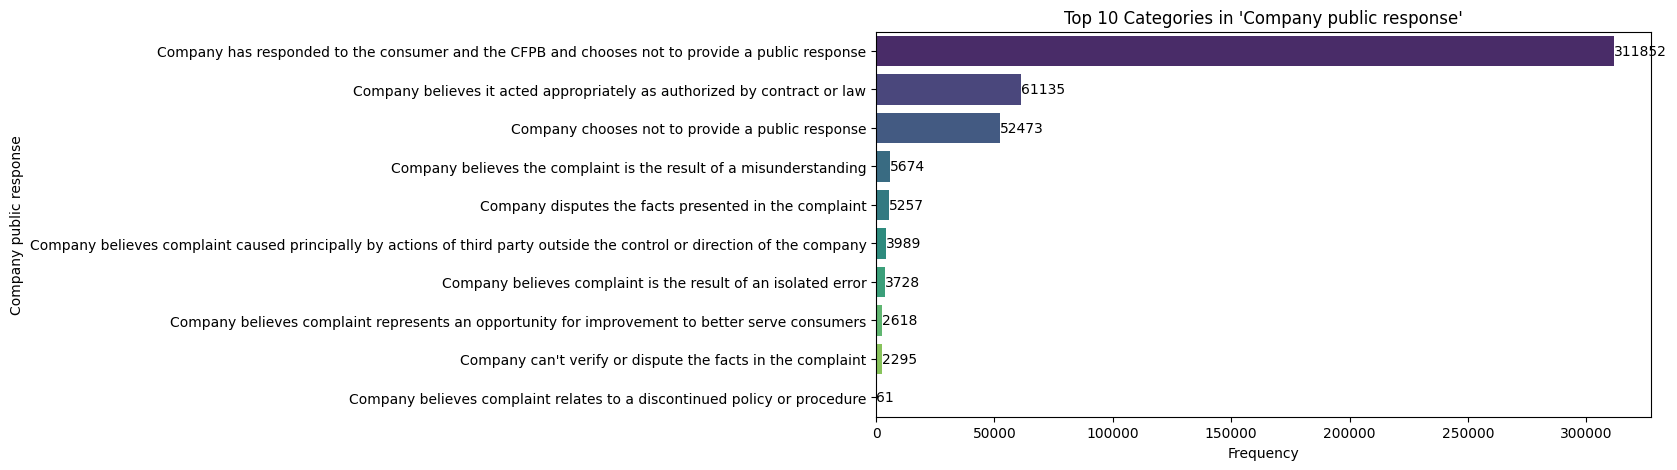

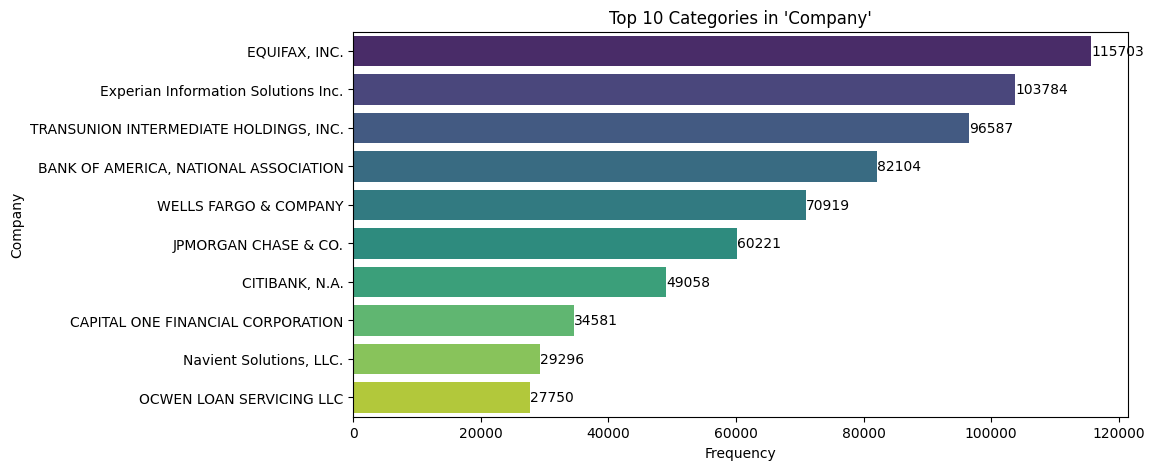

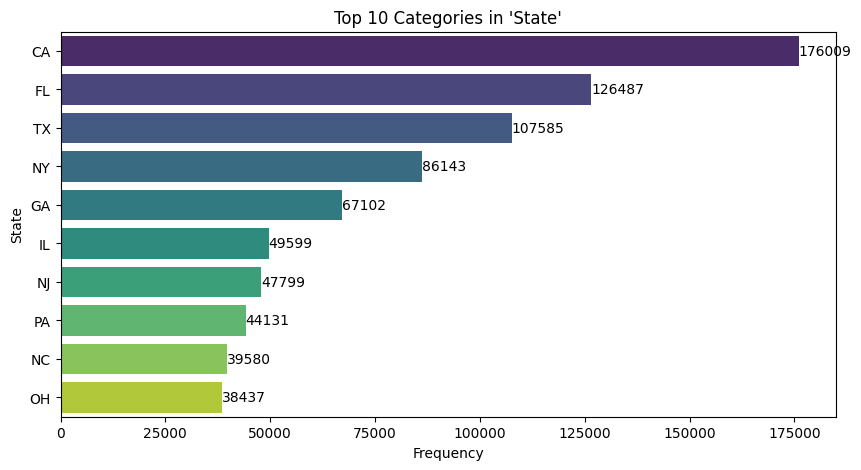

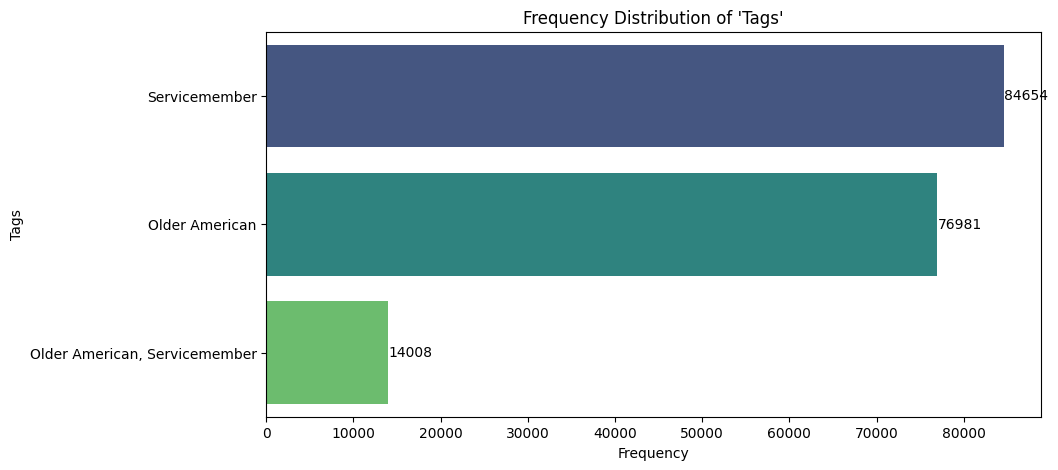

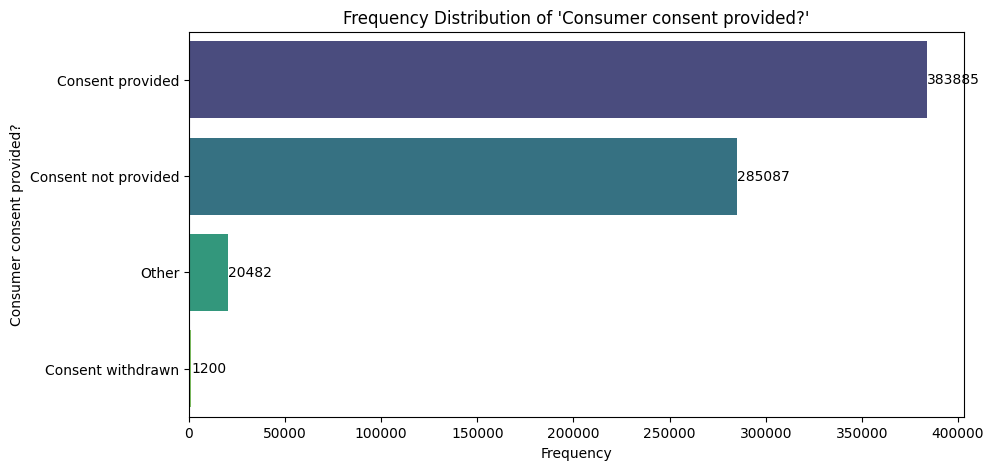

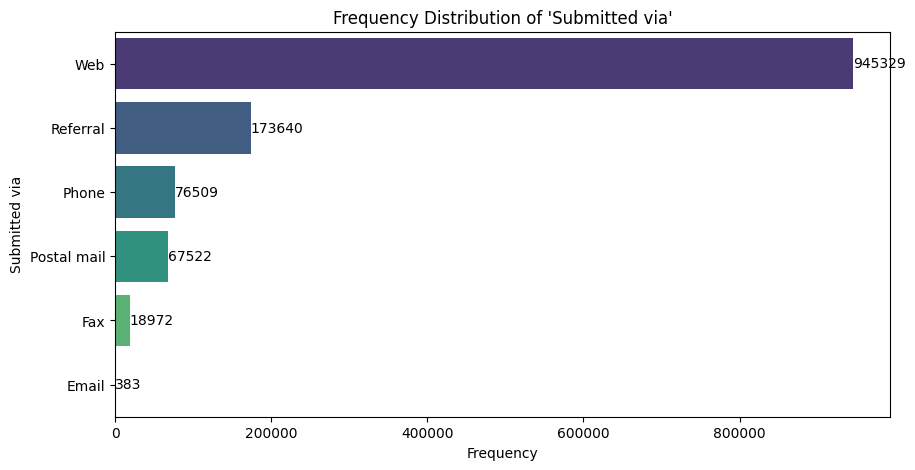

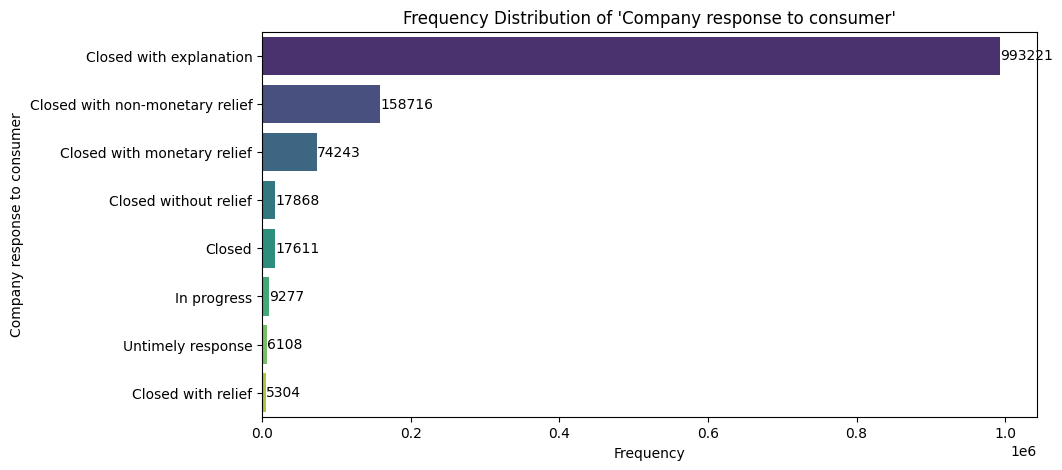

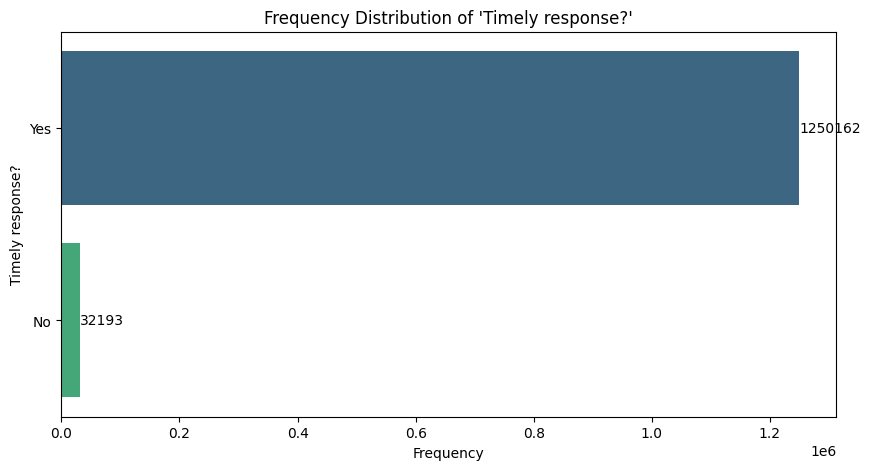

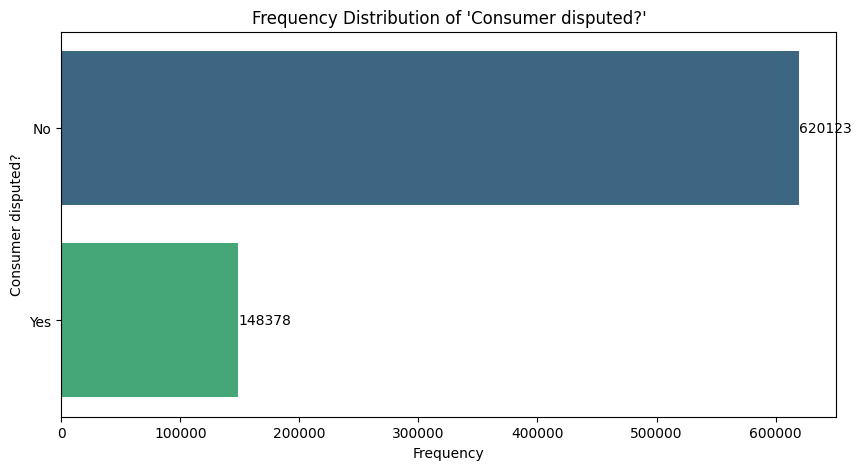

In [8]:
""" Frequency distribution of categorical variables """

# Exclude columns 
exclude_cols = ['Consumer complaint narrative', 'Complaint ID', 'Date sent to company',
                'ZIP code', 'Date received']

# Select only categorical columns and exclude specified ones
categorical_cols = [col for col in data.select_dtypes(include=['object', 'category']).columns if col not in exclude_cols]

# Loop through each categorical column and plot bar chart
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    value_counts = data[col].value_counts()
    # Show only the top 10 if there are more than 10 unique values
    if len(value_counts) > 10:
        value_counts = value_counts.head(10)

    sb.barplot(x=value_counts.values, y=value_counts.index, 
               hue=value_counts.index, palette="viridis", legend=False)
    for index, value in enumerate(value_counts.values):
        plt.text(value, index, f'{value}', va='center', fontsize=10)
    plt.xlabel("Frequency")
    plt.ylabel(col)
    plt.title(f"Top 10 Categories in '{col}'" if len(value_counts) == 10 else f"Frequency Distribution of '{col}'")
    plt.show()

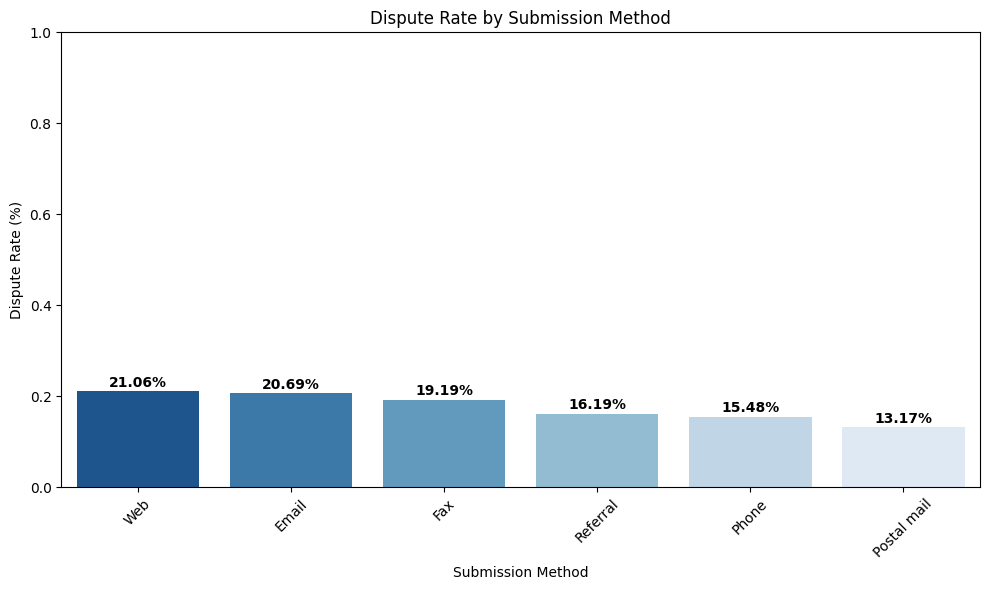

In [9]:
""" Hypothesis 1: Submission channel affects the consumer's dispute rate """

# Compute dispute rate per submission method
dispute_rates = data.groupby('Submitted via')['Consumer disputed?'].value_counts(normalize=True).unstack()

# Rename columns
dispute_rates.columns = ['No Dispute', 'Disputed']

# Sort by highest dispute rate
dispute_rates = dispute_rates.sort_values(by='Disputed', ascending=False)

# Plot bar graph
plt.figure(figsize=(10, 6))
sb.barplot(x=dispute_rates.index, y=dispute_rates['Disputed'], hue=dispute_rates.index, palette="Blues_r", legend=False)

# Label the bars with dispute rate percentage
for i, rate in enumerate(dispute_rates['Disputed']):
    plt.text(i, rate + 0.01, f'{rate:.2%}', ha='center', fontsize=10, fontweight='bold')

plt.xticks(rotation=45)
plt.xlabel("Submission Method")
plt.ylabel("Dispute Rate (%)")
plt.title("Dispute Rate by Submission Method")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [10]:
""" Hypothesis 1: Submission channel affects the consumer's dispute rate """

# Perform Chi-Square test and Cramer's V calculation

# Create a contingency table
contingency_table = pd.crosstab(data["Submitted via"], data["Consumer disputed?"])

# Perform Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Function to calculate Cramér's V
def cramers_v(conf_matrix):
    chi2 = stats.chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    min_dim = min(conf_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))
# Compute Cramér's V
cramer_v_value = cramers_v(contingency_table)

# Print results
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Cramér's V: {cramer_v_value:.4f}")

Chi-Square Statistic: 3530.3828
P-value: 0.0000
Degrees of Freedom: 5
Cramér's V: 0.0678


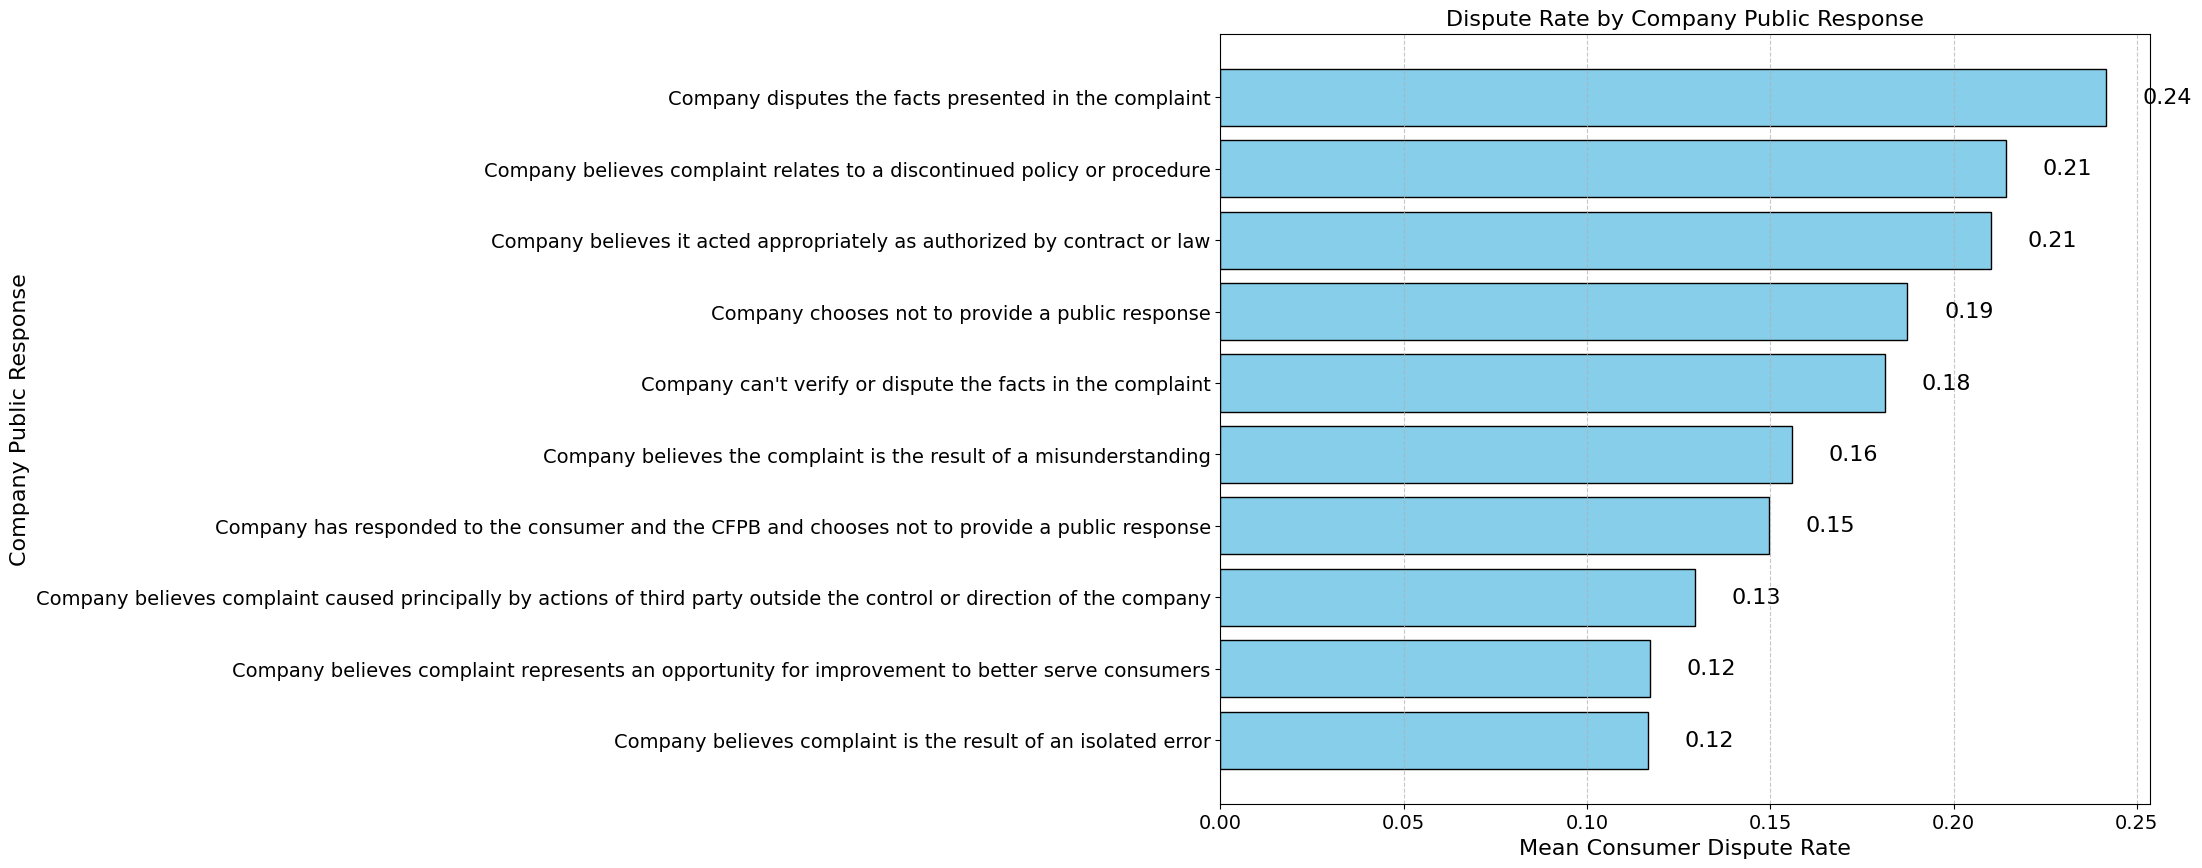

In [11]:
""" Hypothesis 2: Companies that provide bad public response have 
higher consumer dispute rate """

# Creata a temporal data to modify Consumer disputed? column
temp_data = data.copy()
# Map value of Consumer disputed? column to number
temp_data["Consumer disputed?"] = temp_data["Consumer disputed?"].map({"Yes": 1, "No": 0})
temp_data["Consumer disputed?"] = pd.to_numeric(temp_data["Consumer disputed?"], errors="coerce")
# Calculate dispute rate
dispute_rate = temp_data.groupby("Company public response")["Consumer disputed?"].mean()

# Sort the bar by dispute rate
dispute_rate = dispute_rate.sort_values()

# Create the figure
plt.figure(figsize=(12, 10))
bars = plt.barh(dispute_rate.index, dispute_rate, color="skyblue", edgecolor="black")
# Add value label to each bar
for bar in bars:
    plt.text(bar.get_width() + 0.01, 
             bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.2f}", 
             va="center", fontsize=16)
plt.title("Dispute Rate by Company Public Response", fontsize=16)
plt.xlabel("Mean Consumer Dispute Rate", fontsize=16)
plt.ylabel("Company Public Response", fontsize=16)
plt.yticks(fontsize=14) 
plt.xticks(fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [12]:
""" Hypothesis 2: Companies that provide bad public response have 
higher consumer dispute rate """

# Perform Chi-Square test and Cramer's V calculation

# Create a contingency table
contingency_table = pd.crosstab(data["Company public response"], data["Consumer disputed?"])

# Perform Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Function to calculate Cramér's V
def cramers_v(conf_matrix):
    chi2 = stats.chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    min_dim = min(conf_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))
# Compute Cramér's V
cramer_v_value = cramers_v(contingency_table)

# Print results
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Cramér's V: {cramer_v_value:.4f}")

Chi-Square Statistic: 984.1588
P-value: 0.0000
Degrees of Freedom: 9
Cramér's V: 0.0709


In [13]:
""" Hypothesis 3: Older Americans are more likely to be involved 
in fraud or scam related cases"""

# Filter issue categories that contain "fraud" or "scam" (case insensitive)
fraud_related_issues = data[data['Issue'].str.contains(r'fraud|scam', case=False, na=False)]

# Display unique fraud-related issues
print(fraud_related_issues['Issue'].unique())

['Problem with fraud alerts or security freezes' 'Fraud or scam'
 'Identity theft / Fraud / Embezzlement']


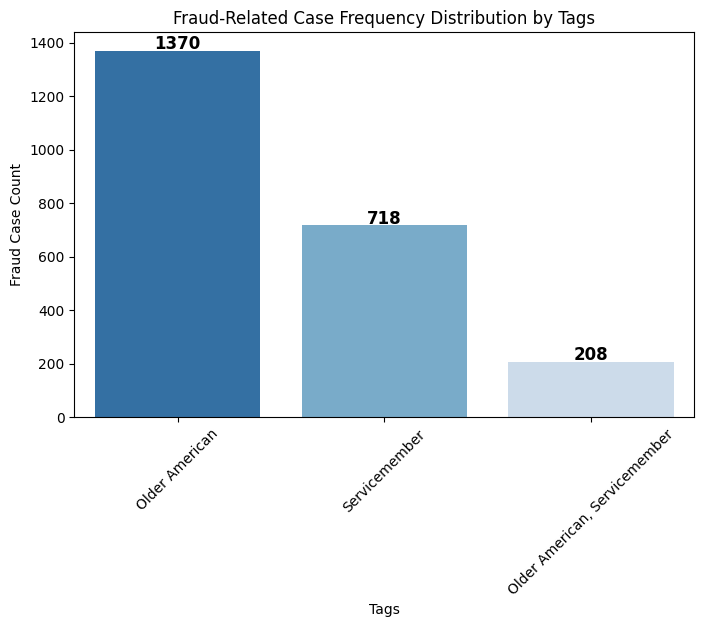

In [14]:
""" Hypothesis 3: Older Americans are more likely to be involved 
in fraud or scam related cases"""

# Define fraud-related issues
fraud_issues = ["Fraud or scam", "Identity theft / Fraud / Embezzlement"]

# Filter only fraud-related cases
fraud_data = data[data['Issue'].isin(fraud_issues)]

# Count fraud cases by tag
fraud_counts = fraud_data['Tags'].value_counts()

# Plot bar chart
plt.figure(figsize=(8, 5))
sb.barplot(x=fraud_counts.index, y=fraud_counts.values, hue=fraud_counts.index, 
           palette="Blues_r", legend=False)
for i, count in enumerate(fraud_counts.values):
    plt.text(i, count + 5, f"{count}", ha='center', fontsize=12, fontweight='bold')
plt.xlabel("Tags")
plt.ylabel("Fraud Case Count")
plt.title("Fraud-Related Case Frequency Distribution by Tags")
plt.xticks(rotation=45)
plt.show()

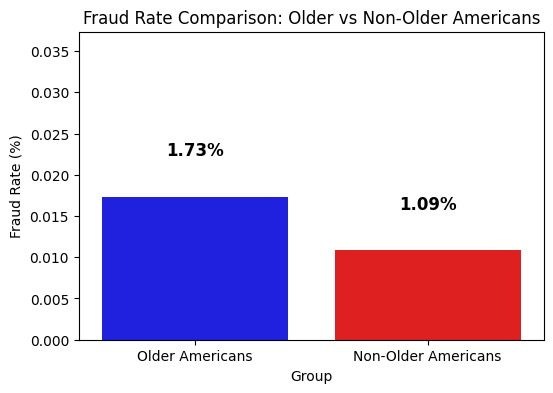

In [15]:
""" Hypothesis 3: Older Americans are more likely to be involved 
in fraud or scam related cases"""

fraud_issues = ["Fraud or scam", "Identity theft / Fraud / Embezzlement"]

# Filter data
older_american = data[data['Tags'].str.contains("Older American", na=False)]
non_older_american = data[~data['Tags'].str.contains("Older American", na=False)]

# Calculate fraud rates
older_fraud_rate = older_american['Issue'].isin(fraud_issues).mean()
non_older_fraud_rate = non_older_american['Issue'].isin(fraud_issues).mean()

# Create DataFrame for plotting
fraud_rates = pd.DataFrame({
    "Group": ["Older Americans", "Non-Older Americans"],
    "Fraud Rate": [older_fraud_rate, non_older_fraud_rate]
})

# Plot bar chart
plt.figure(figsize=(6, 4))
sb.barplot(x="Group", y="Fraud Rate", hue="Group", data=fraud_rates, 
           palette=["blue", "red"], legend=False)
# Add labels
for i, rate in enumerate(fraud_rates["Fraud Rate"]):
    plt.text(i, rate + 0.005, f'{rate:.2%}', ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, max(fraud_rates["Fraud Rate"]) + 0.02)
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate Comparison: Older vs Non-Older Americans")
plt.show()

In [6]:
"""Handling Null & Duplicate Record in Consumer complaint narrative & Issue """

# Check null values in Consumer complaint narrative and Issue columns
null_count = data[['Consumer complaint narrative', 'Issue']].isnull().sum()
print(f'Number of null values in "Consumer complaint narrative" and "Issue" (before):\n{null_count}')

# Create a copy of the data to prepocess and EDA
# Remove rows with null values in 'Consumer complaint narrative' and 'Issue'
data_eda = data.dropna(subset=['Consumer complaint narrative', 'Issue'])

# Check null values after removal
null_count_after = data_eda[['Consumer complaint narrative', 'Issue']].isnull().sum()
print(f'\nNumber of null values in "Consumer complaint narrative" and "Issue" (after):\n{null_count_after}')

# Check duplicate records before removal
duplicates = data_eda.duplicated(subset=['Consumer complaint narrative', 'Issue']).sum()
print(f'\nNumber of duplicate records (before): \n{duplicates}')

# Remove duplicates
data_eda = data_eda.drop_duplicates(subset=['Consumer complaint narrative', 'Issue'])

# Check duplicates after removal
duplicates_after = data_eda.duplicated(subset=['Consumer complaint narrative', 'Issue']).sum()
print(f'\nNumber of duplicate records (after): \n{duplicates_after}')

Number of null values in "Consumer complaint narrative" and "Issue" (before):
Consumer complaint narrative    898791
Issue                                0
dtype: int64

Number of null values in "Consumer complaint narrative" and "Issue" (after):
Consumer complaint narrative    0
Issue                           0
dtype: int64

Number of duplicate records (before): 
16297

Number of duplicate records (after): 
0


In [7]:
print("\nUpdated Data Statistics")
data_eda.describe(include='all')


Updated Data Statistics


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
count,367267,367267,316921,367267,253959,367267,173301,367267,365901,281676,64405,367267,367267,367267,367263,367267,161100,367267
unique,1464,18,75,161,215,366945,10,4108,63,9994,3,1,1,1472,6,2,2,367267
top,09/08/2017,Debt collection,Credit reporting,Incorrect information on your report,Their investigation did not fix an error on yo...,I was part of the Equifax credit information h...,Company has responded to the consumer and the ...,"EQUIFAX, INC.",CA,300XX,Servicemember,Consent provided,Web,09/08/2017,Closed with explanation,Yes,No,1485711
freq,1753,84356,78319,41370,15596,4,115119,34036,49847,6002,36686,367267,367267,1661,296624,356144,125725,1


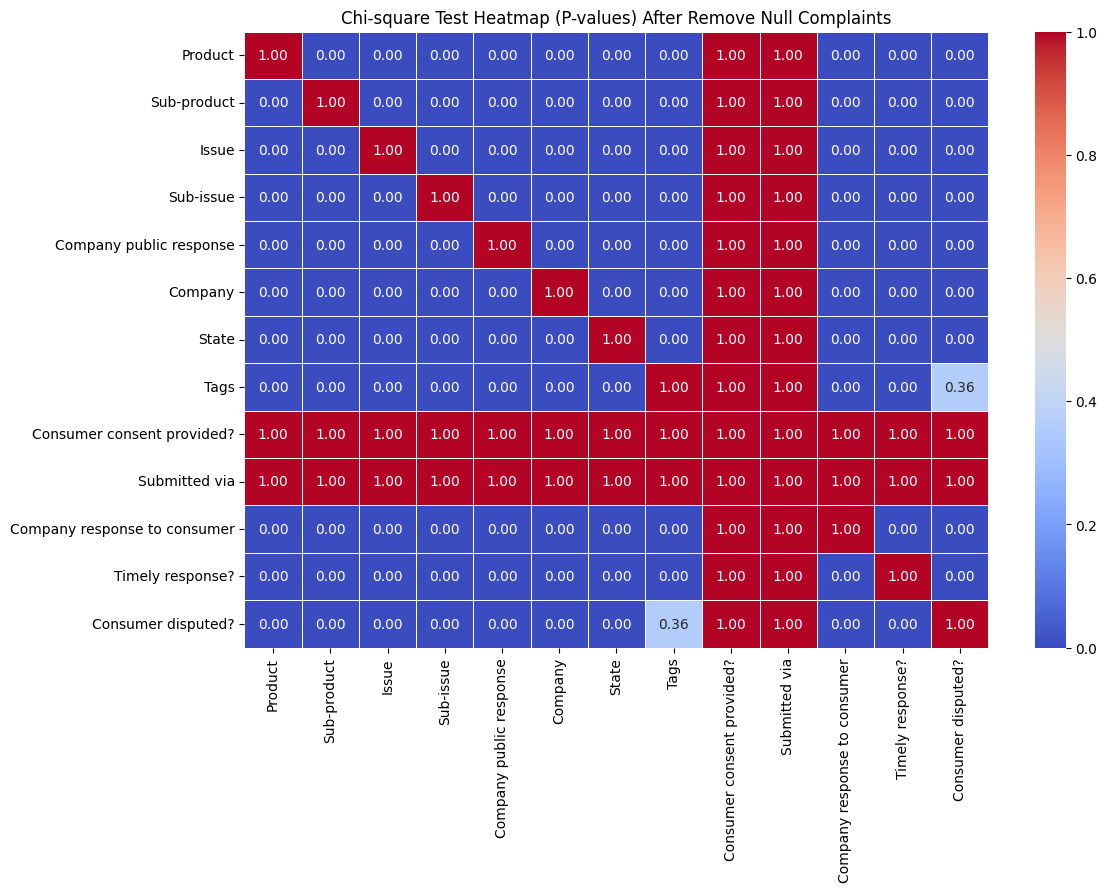

In [18]:
""" Conduct Chi-Square test for categorical variables """

# Select only categorical columns
categorical_cols = ['Product', 'Sub-product', 'Issue', 'Sub-issue', 
                    'Company public response', 'Company', 'State', 'Tags', 
                    'Consumer consent provided?', 'Submitted via', 
                    'Company response to consumer', 'Timely response?', 'Consumer disputed?']

# Create an empty DataFrame to store p-values
chi2_results = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

# Perform Chi-square test for each pair of categorical variables
for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            chi2_results.loc[col1, col2] = 1.0  # Set diagonal to 1
        else:
            # Create contingency table
            contingency_table = pd.crosstab(data_eda[col1], data_eda[col2])
            
            # Perform Chi-square test
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            
            # Store p-value in the matrix
            chi2_results.loc[col1, col2] = p

# Convert to float type
chi2_results = chi2_results.astype(float)

# Plot heatmap
plt.figure(figsize=(12, 8))
sb.heatmap(chi2_results, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Chi-square Test Heatmap (P-values) After Remove Null Complaints")
plt.show()


# chi-square of certain columns become 1 because their categories are stripped
# making them too uniform to observe any variability

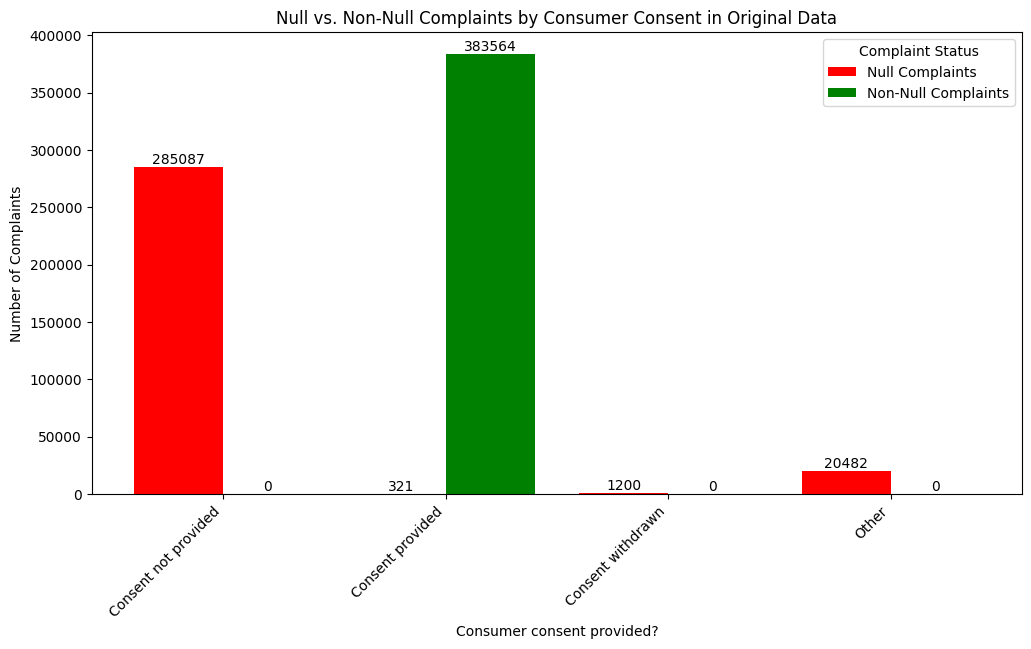

In [19]:
""" Examine why "Consumer consent provided?" chi-square p-value becomes 1.0 
 for every variable """

# Count null/non-null "Consumer complaint narrative" in "Consumer consent provided?" column
complaint_null_counts = data.groupby('Consumer consent provided?')['Consumer complaint narrative'].agg([
    lambda x: x.isna().sum(),
    lambda x: x.notna().sum() 
]).rename(columns={'<lambda_0>': 'Null Complaints', '<lambda_1>': 'Non-Null Complaints'})


fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(complaint_null_counts))
width = 0.4
bars1 = ax.bar(x - width/2, complaint_null_counts['Null Complaints'], 
               width=width, label='Null Complaints', color='red')
bars2 = ax.bar(x + width/2, complaint_null_counts['Non-Null Complaints'], 
               width=width, label='Non-Null Complaints', color='green')
for bars in [bars1, bars2]:  
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', 
                ha='center', va='bottom', fontsize=10, color='black')
ax.set_xlabel('Consumer consent provided?')
ax.set_ylabel('Number of Complaints')
ax.set_title('Null vs. Non-Null Complaints by Consumer Consent in Original Data')
ax.set_xticks(x)
ax.set_xticklabels(complaint_null_counts.index, rotation=45, ha='right')
ax.legend(title="Complaint Status")
plt.show()

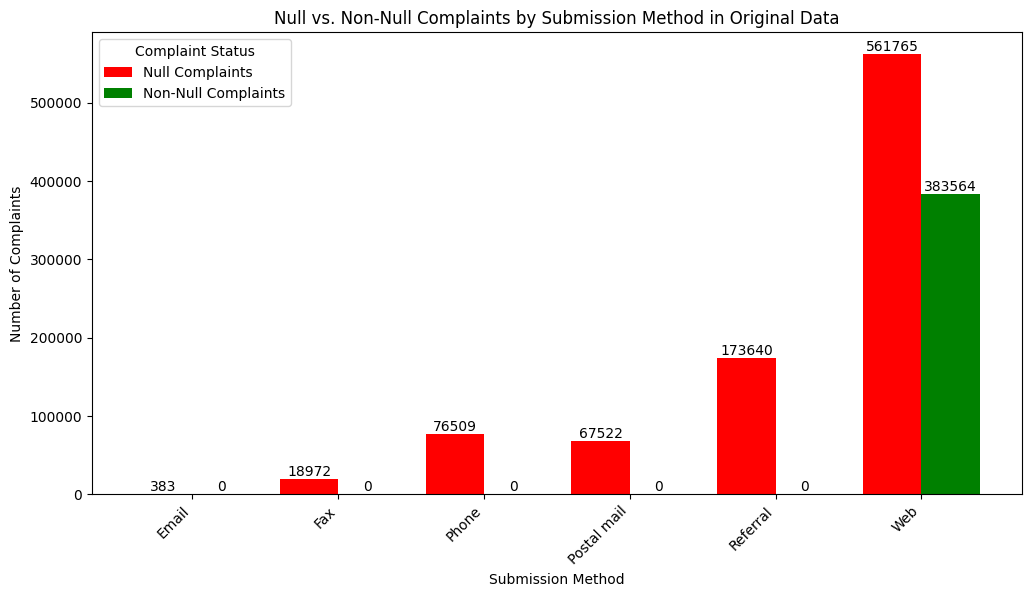

In [20]:
""" Examine why "Submitted via" chi-square p-value becomes 1.0 
for every variable """

# Count null/non-null "Consumer complaint narrative" in "Submitted via" column
complaint_null_counts = data.groupby('Submitted via')['Consumer complaint narrative'].agg([
    lambda x: x.isna().sum(),
    lambda x: x.notna().sum() 
]).rename(columns={'<lambda_0>': 'Null Complaints', '<lambda_1>': 'Non-Null Complaints'})


fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(complaint_null_counts))
width = 0.4
bars1 = ax.bar(x - width/2, complaint_null_counts['Null Complaints'], 
               width=width, label='Null Complaints', color='red')
bars2 = ax.bar(x + width/2, complaint_null_counts['Non-Null Complaints'], 
               width=width, label='Non-Null Complaints', color='green')
for bars in [bars1, bars2]:  
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', 
                ha='center', va='bottom', fontsize=10, color='black')
ax.set_xlabel('Submission Method')
ax.set_ylabel('Number of Complaints')
ax.set_title('Null vs. Non-Null Complaints by Submission Method in Original Data')
ax.set_xticks(x)
ax.set_xticklabels(complaint_null_counts.index, rotation=45, ha='right')
ax.legend(title="Complaint Status")
plt.show()

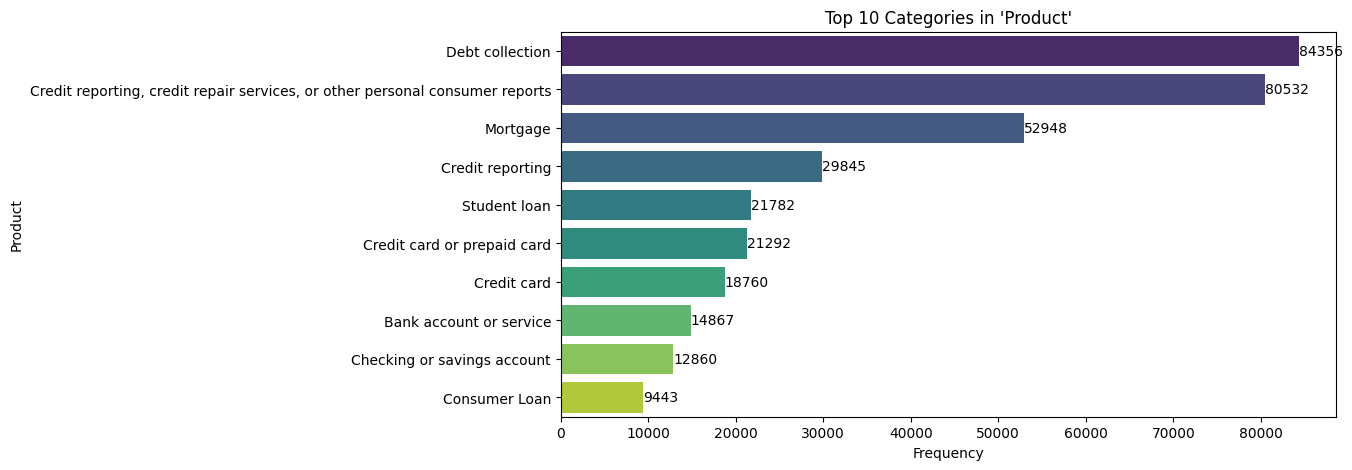

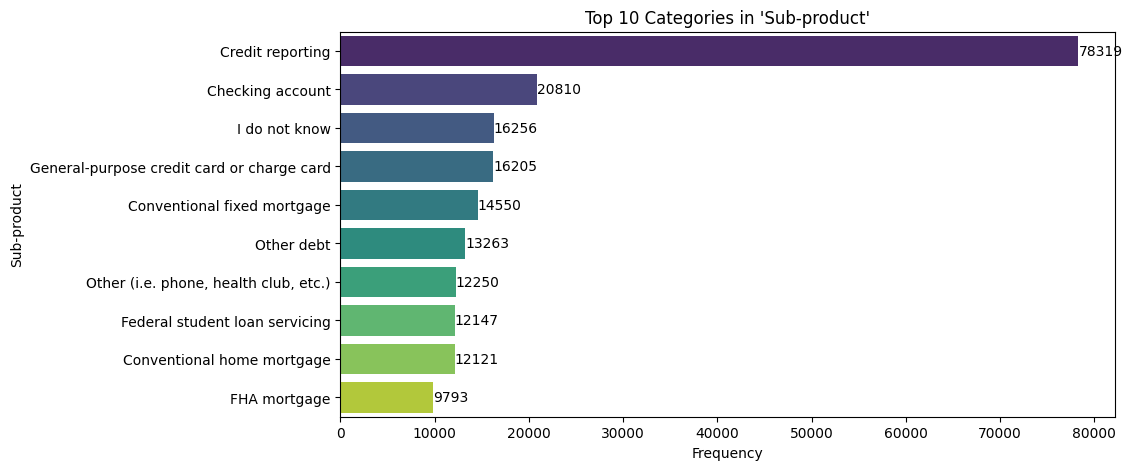

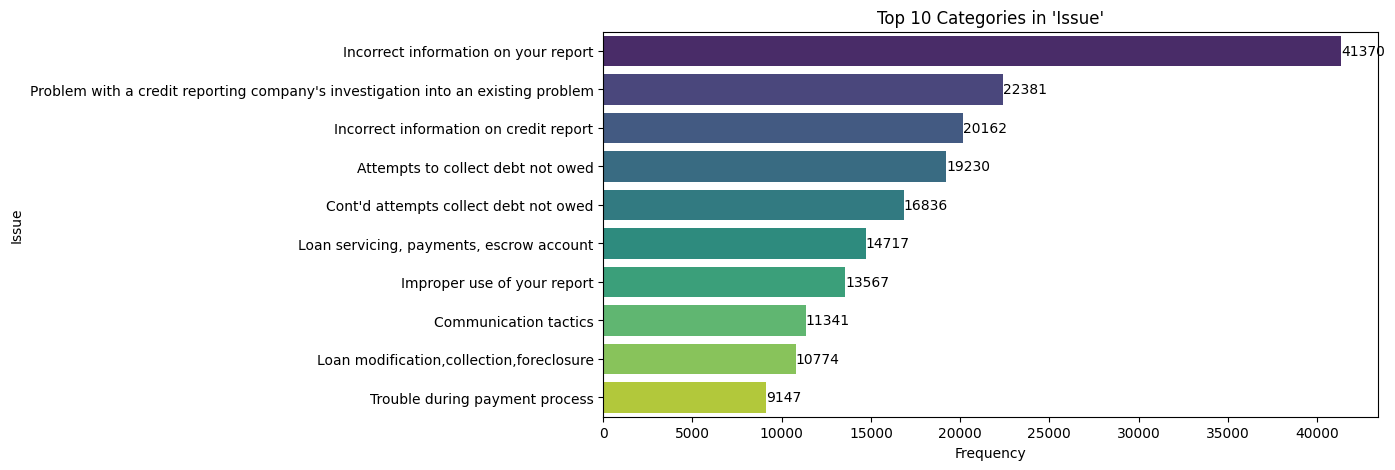

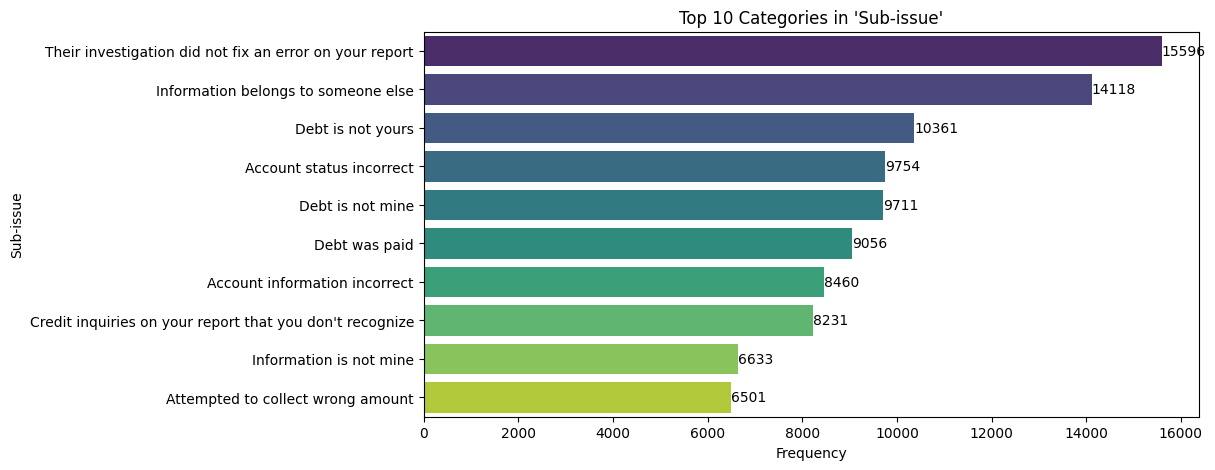

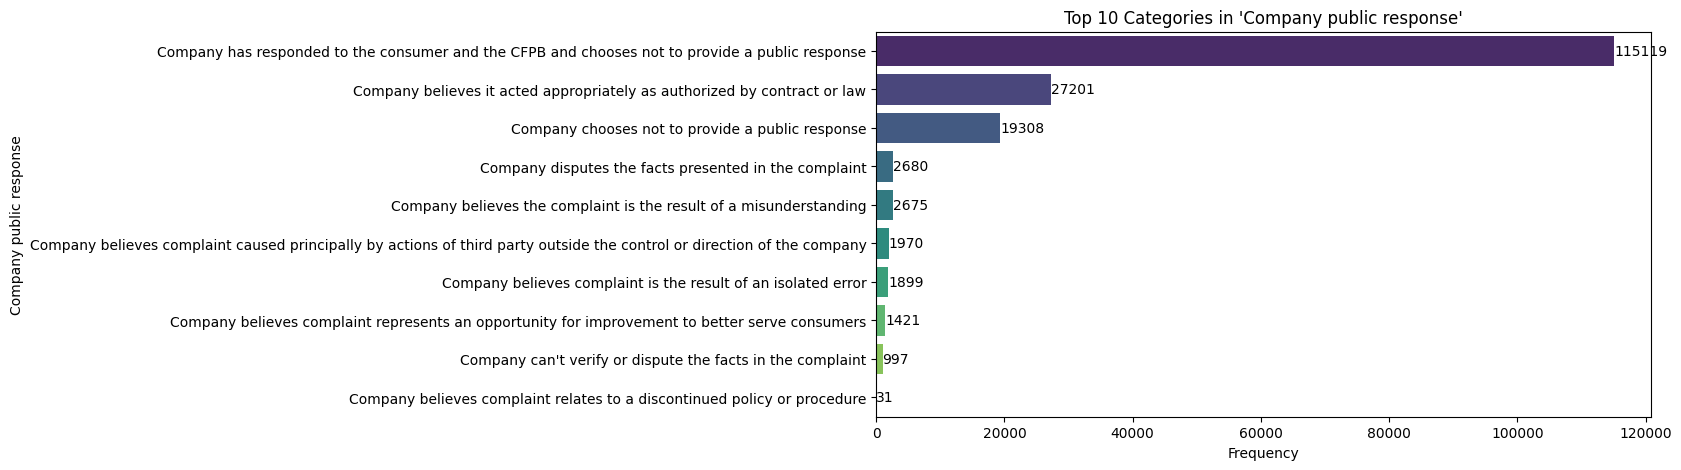

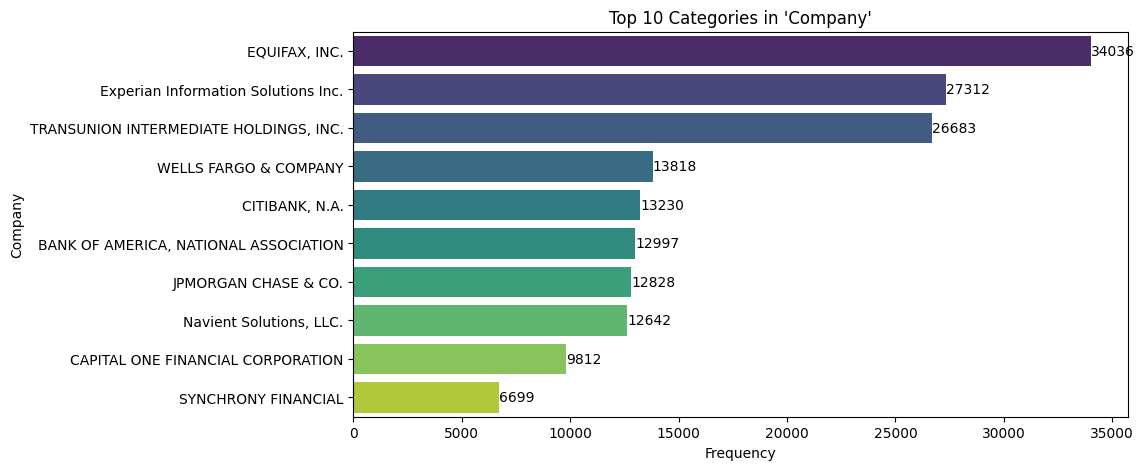

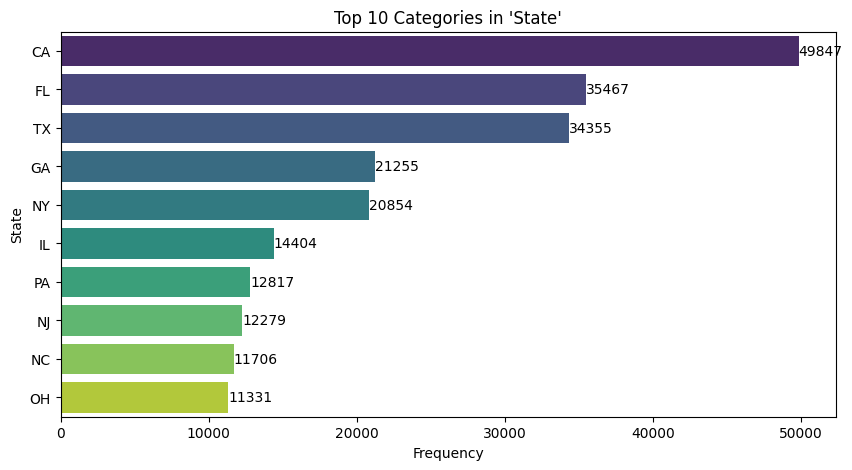

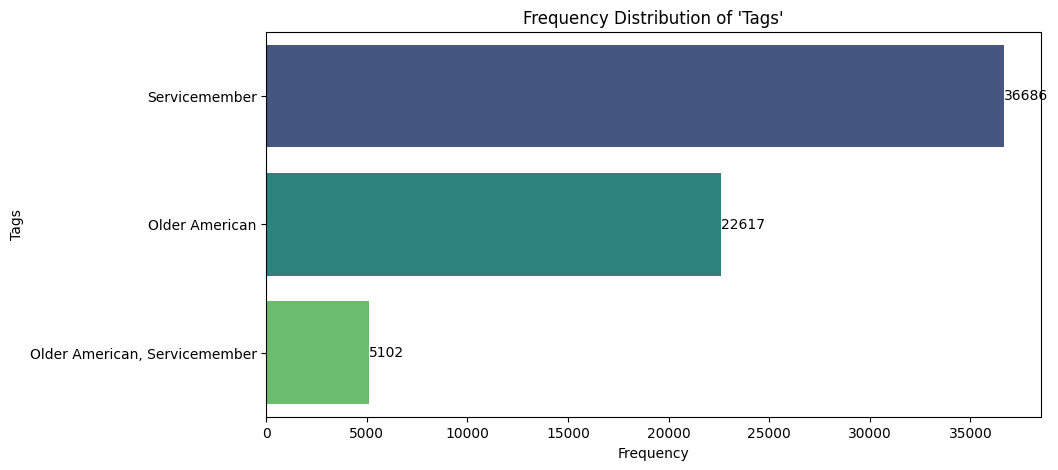

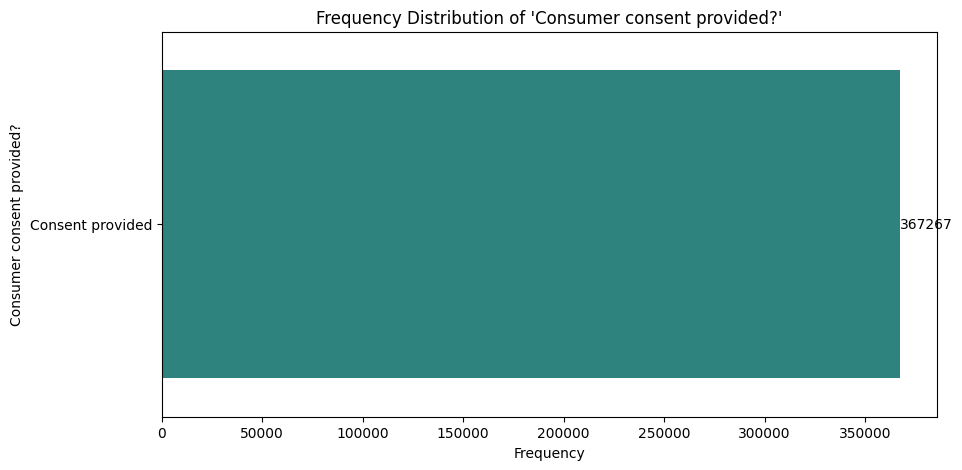

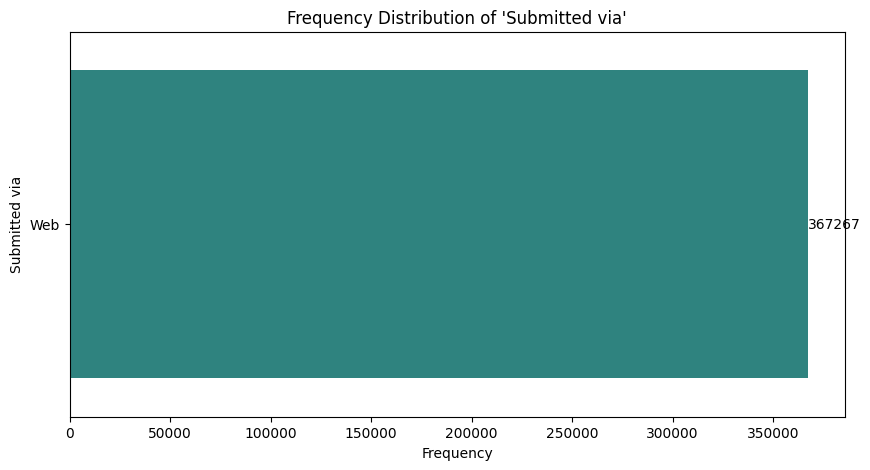

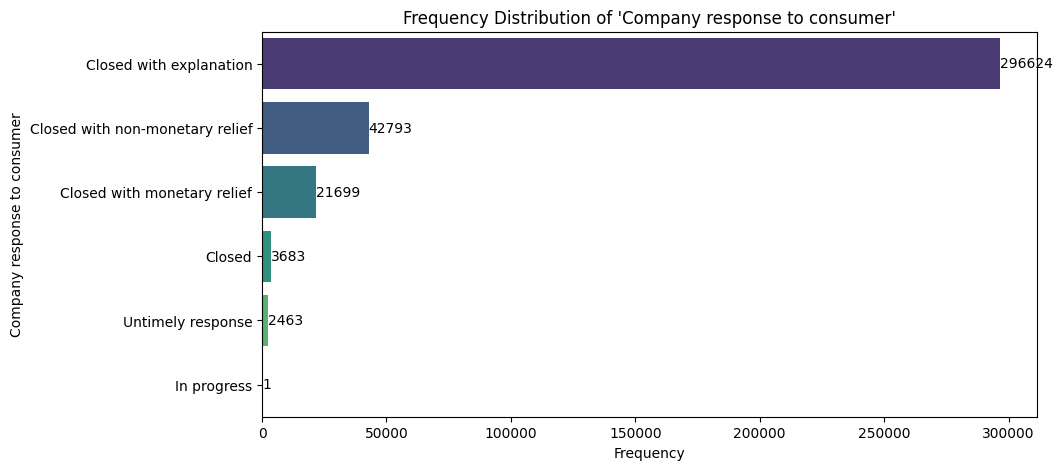

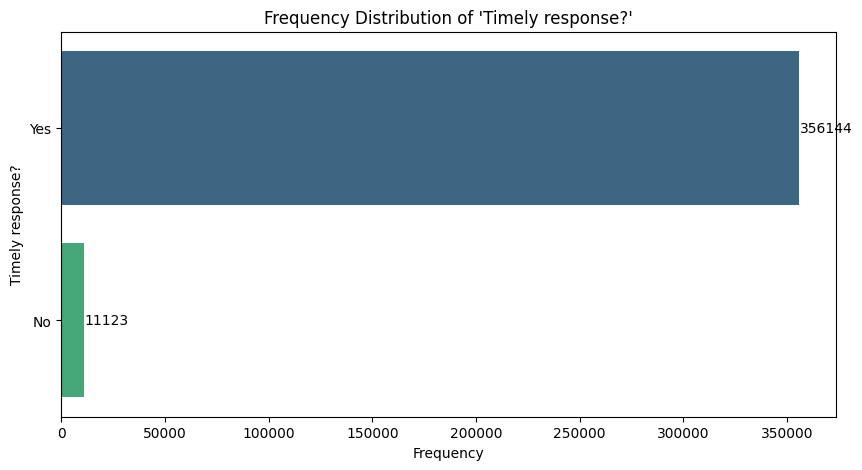

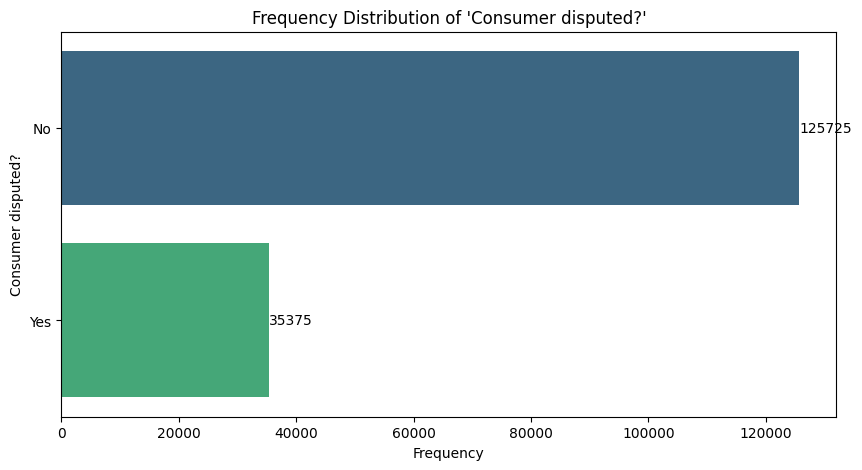

In [21]:
"""Frequency distribution of categorical variables 
after handling missing value & duplicate record"""

# Exclude columns 
exclude_cols = ['Consumer complaint narrative', 'Complaint ID', 'Date sent to company',
                'ZIP code', 'Date received']

# Select only categorical columns and exclude specified ones
categorical_cols = [col for col in 
                    data_eda.select_dtypes(include=['object', 'category']).columns 
                    if col not in exclude_cols]

# Loop through each categorical column and plot bar chart
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    value_counts = data_eda[col].value_counts()
    # Show only the top 10 if there are more than 10 unique values
    if len(value_counts) > 10:
        value_counts = value_counts.head(10)

    sb.barplot(x=value_counts.values, y=value_counts.index, 
               hue=value_counts.index, palette="viridis", legend=False)
    for index, value in enumerate(value_counts.values):
        plt.text(value, index, f'{value}', va='center', fontsize=10)
    plt.xlabel("Frequency")
    plt.ylabel(col)
    plt.title(f"Top 10 Categories in '{col}'" if len(value_counts) == 10 else f"Frequency Distribution of '{col}'")
    plt.show()


In [8]:
""" Compute sentence length and word count for Consumer complaint narrative"""

# Create a copy for EDA 
data_eda = data_eda.copy()

# Create new columns for the text length and word count of Consumer complaint narrative
data_eda['Complaint_Length'] = data_eda['Consumer complaint narrative'].apply(len)

data_eda['Word_Count'] = data_eda['Consumer complaint narrative'].apply(lambda x: len(x.split()))

print(data_eda[['Complaint_Length', 'Word_Count']].describe())

# Show full complaint text without being cut
pd.set_option('display.max_colwidth', None) 
data_eda[['Consumer complaint narrative', 'Issue', 'Complaint_Length', 'Word_Count']].head()

       Complaint_Length     Word_Count
count     367267.000000  367267.000000
mean        1109.005315     201.786518
std         1185.919699     213.269774
min            5.000000       1.000000
25%          411.000000      75.000000
50%          771.000000     141.000000
75%         1397.000000     255.000000
max        31735.000000    6314.000000


,Consumer complaint narrative,Issue,Complaint_Length,Word_Count
29904,The Summer of XX/XX/2018 I was denied a mortgage loan due to a charge off from XXXX XXXX credit card. I both mailed an account validation letter and disputed this debt with the credit bureaus and the credit card company several times. Only the credit bureaus responded that this debt was verified but showed no proof as I requested. XXXX XXXX still has not responded to any of my letters since XX/XX/2018. All I asked was that the credit bureaus show me how they verified this debt and what XXXX XXXX sent them as proof of my debt other than a bill that could be fabricated. I really need to know why I haven't been shown proof of this after multiple disputes and certified letters letters sent.,Incorrect information on your report,695,127
30629,There are many mistakes appear in my report without my understanding.,Incorrect information on your report,69,11
31078,"There is an account reporting on my credit report from XXXX XXXX which is saying the balance is coming from XXXX XXXX XXXX XXXX from XX/XX/2012. I never signed a joint lease with anyone, I have asked several times for a copy of this lease I supposed I signed. The credit bureau is allowing this allow to report on my credit report when it does not belong to me, Please have this account investigated and removed from my credit report. I contact the original credit XXXX XXXX and they are telling me they don't have a lease agreement with me or never had one with me. So I'm not sure where they are getting this information from. Please remove immediately. Thanks, XXXX",Problem with a credit reporting company's investigation into an existing problem,668,122
31458,"The reason for my writing is to inform you that this company is being unreasonable and not adhering to the law. I am a victim of identity theft. My personal information was compromised and as a result fraudulent charges were included on my accounts without my consent or authorization. I disputed this identity fraud with this company on XXXX by providing my written explanation and attaching relevant documentation e.g. Identity Theft Report, Proof of identity and Section 605B of the Fair Credit Reporting Act to proof my case. But until now, as I am writing to you, this company is still reporting these fraudulent accounts contrary to law, which gives them at least 4 days to remove it upon receipt of fraud dispute letter. Let this be a final written notice of my intent to sue this company for failing to remove fraudulent items even after receiving a well-documented dispute coupled with exhibits for reference. For yet another time I am reaching out to this company to find a concrete resolution to this matter once and for all. Failure to this I will go ahead and file my already filled small claims forms with the courts. Please REMOVE this fraudulent information from my credit report, as per 605B of the Fair Credit Reporting Act : 1.XXXX XXXX XXXX # XXXX, Opened Date XX/XX/XXXX, Original Creditor XXXX XXXX XXXX XXXX XXXX , High Balance {$1500.00}. 2. XXXX XXXX XXXX, ACC # XXXX, Original Creditor XXXX XXXX , Opened Date XX/XX/XXXX, Balance {$190.00}. I am attaching the dispute letter/documents I sent to this company on the XXXX and my FTC report, in case they need to reference or review.",Problem with a credit reporting company's investigation into an existing problem,1608,277
33083,XXXX and Transunion are reporting incorrectly that I am 120 days past due on a loan with the XXXX - partial account numberXXXX. This account reflects a {$0.00} balance and a {$0.00} past due. I have contacted the two bureaus and requested these coding errors be corrected. This incorrect reporting is harming my credit score. It is impossible to be past due on accounts that have a {$0.00} balance and {$0.00} past due.,Problem with a credit reporting company's investigation into an existing problem,419,73


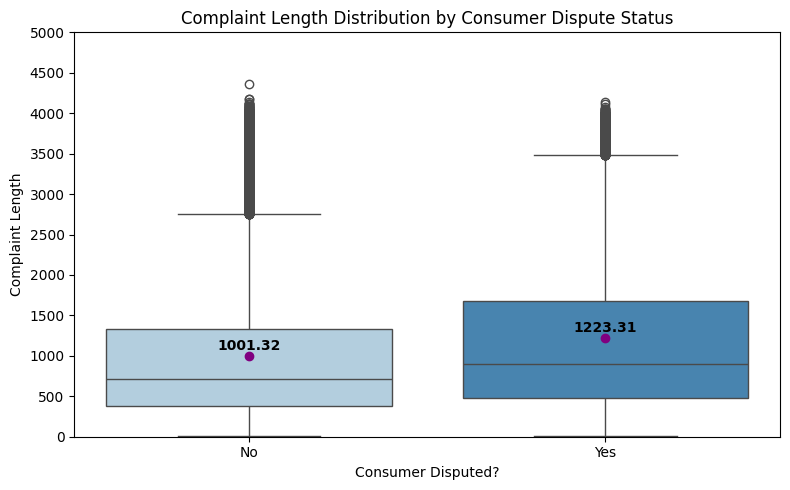

In [23]:
""" Hypothesis 4: Longer complaint are more likely to be disputed too """

plt.figure(figsize=(8, 5))
ax = sb.boxplot(x="Consumer disputed?", y="Complaint_Length", data=data_eda, 
                hue="Consumer disputed?", palette="Blues", legend=False)

# Calculate mean complaint length
means = data_eda.groupby("Consumer disputed?")["Complaint_Length"].mean()

# Plot the mean values as points and add labels
for i, mean in enumerate(means):
    plt.scatter(x=i, y=mean, color='purple', zorder=10, label='Mean' if i == 0 else "")
    plt.text(i, mean + 30, f'{mean:.2f}', ha='center', va='bottom', color='black', 
             fontsize=10, fontweight='bold')

plt.title('Complaint Length Distribution by Consumer Dispute Status')
plt.xlabel('Consumer Disputed?')
plt.ylabel('Complaint Length')
plt.ylim(0, 5000)
plt.yticks(range(0, 5001, 500))
plt.tight_layout()
plt.show()

In [9]:
""" Remove X symbols in complaint narrative that anonymized sensitive info"""

# Check for complaints that have multiple "X" symbols
complaints_with_x = data_eda[data_eda['Consumer complaint narrative'].str.contains(r'X{2,}', na=False)]
pd.set_option('display.max_colwidth', None) 
# Show random samples
sample_before = complaints_with_x[['Consumer complaint narrative']].sample(n=3, random_state=42)
print("Before removing X symbols:")
display(sample_before)

# Remove multiple "X" symbols and clean extra whitespace
data_eda['Consumer complaint narrative'] = data_eda['Consumer complaint narrative'].str.replace(
    r'X+', '', regex=True)
data_eda['Consumer complaint narrative'] = data_eda['Consumer complaint narrative'].str.replace(
    r'\s+', ' ', regex=True).str.strip()

# Show the sample after remove X and extra whitespace
sample_after = data_eda.loc[sample_before.index, ['Consumer complaint narrative']]
print("\nAfter removing X symbols and extra spaces:")
display(sample_after)

Before removing X symbols:


,Consumer complaint narrative
395949,On XXXX XXXX I applied for a Merrill Lynch Visa Signature card from Bank of America. They pulled my credit twice on XXXX XXXX resulting in two credit inquiries. I only authorized one inquiry for the one account. XXXX XXXX needs a letter from Bank of America stating that only one credit inquiry should have been pulled. They have thus far refused my request for a letter of deletion to remove the duplicate inquiry from my account.
55948,I have many incorrect accounts on my credit report that I have never been affiliated with. Even some of the names and addresses on my report are wrong. I do not understand how these things are being tied to my name but i have nothing to do with this. \n\nName : XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX {$1200.00} XXXX XXXX XXXX XXXX {$810.00} XXXX XXXX XXXX {$430.00} XXXX XXXX XXXX {$540.00} XXXX XXXX $ {$680.00} XXXX XXXX XXXX {$50.00}
550117,"Please note that all Assignments that were recorded for Property located at XXXX XXXX XXXX XXXX, XXXX XXXX notarized by XXXX XXXX need to be investigated for fraud and misuse of the Notary Certification for the Nationstar Mortgage LLC. personal gain. \n\nAll persons who notarized the assignment has lack of capacity, authority and personal knowledge of the facts regarding the transferring of the note to the current Servicer, Nationstar Mortgage LLC/ The Assignments recorded also shows lack authenticity. Under the Consent Order with the CFPB, Nationstar Mortgage has the due diligence to make sure the consumer protection laws were adhered to. \n\nWe requested a principal modification, principal reduction based on the assignments and Nationstar LLC has failed to honor such request and did not give us an explanation why we were denied A complaint will be filed against the Notary in the Executive Governors Office in XXXX for their errors and omission by not validating the reference document."



After removing X symbols and extra spaces:


,Consumer complaint narrative
395949,On I applied for a Merrill Lynch Visa Signature card from Bank of America. They pulled my credit twice on resulting in two credit inquiries. I only authorized one inquiry for the one account. needs a letter from Bank of America stating that only one credit inquiry should have been pulled. They have thus far refused my request for a letter of deletion to remove the duplicate inquiry from my account.
55948,I have many incorrect accounts on my credit report that I have never been affiliated with. Even some of the names and addresses on my report are wrong. I do not understand how these things are being tied to my name but i have nothing to do with this. Name : {$1200.00} {$810.00} {$430.00} {$540.00} $ {$680.00} {$50.00}
550117,"Please note that all Assignments that were recorded for Property located at , notarized by need to be investigated for fraud and misuse of the Notary Certification for the Nationstar Mortgage LLC. personal gain. All persons who notarized the assignment has lack of capacity, authority and personal knowledge of the facts regarding the transferring of the note to the current Servicer, Nationstar Mortgage LLC/ The Assignments recorded also shows lack authenticity. Under the Consent Order with the CFPB, Nationstar Mortgage has the due diligence to make sure the consumer protection laws were adhered to. We requested a principal modification, principal reduction based on the assignments and Nationstar LLC has failed to honor such request and did not give us an explanation why we were denied A complaint will be filed against the Notary in the Executive Governors Office in for their errors and omission by not validating the reference document."


In [10]:
"""Compute sentiment score of each complaint"""

# Apply TextBlob sentiment analysis
data_eda['sentiment_score'] = data_eda['Consumer complaint narrative'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity)

# Show random 5 samples
pd.set_option('display.max_colwidth', None) 
data_eda[['Consumer complaint narrative', 'sentiment_score']].sample(5)

,Consumer complaint narrative,sentiment_score
96194,"I realized on //2018, that my little wallet with my ATM card and checks for my Wells Fargo checking account was missing. I knew there was a very good chance it had been stolen from my car. I called Wells Fargo to tell them and to place a hold on all debits from my account. I spoke with a representative who I did not have ultimate confidence in, although she told me a "" hard hold '' had been placed, and NOTHING would go out from my account. I called back again a short while later, explaining that I wanted to confirm that information. A second representative confirmed there was a "" hard hold '', that NO debits would go through, and that until I removed the hold, only deposits would go through. I asked for this because I was expecting my Social Security direct deposit soon, and I did not want that to bounce off the account and not deposit. They assured me it would deposit as usual, but no debits would come out. I planned to go into a branch to open another checking account in place of the compromised one. I got ill, and was not able to go into the branch until //2018. At that time, my account was overdrawn due to a loan payment debit the bank allowed to go through on //. I asked them why that happened when I had a "" hard hold '', and they just said they were sorry, they didnt know why. The account rep, , said he would call customer service to find out why that happened. A while later he asked me to speak with the person he had on the phone. That person warned me I was being recorded, and said to file a claim he needed to take a recorded statement. I asked why, since it was pretty clear to see what happened. He got brusk and defensive, and asked me if I wanted to quit the claim. There was so much accusation and condescension in his voice, I put the phone down and told just to close my account. A short while later, they gave me my cash ( my social security deposited that day, minus the debit they should not have let be paid ... ). I walked out and they told me "" Your account is closed. '' When I got up today, the day after, I had an email from Wells Fargo dated this morning, //18, at , saying that I owe {$35.00} for a stop-payment fee, to stop the loan payment which already paid on //!!!! Furthermore, since I emptied the account and my balance was zero, they were charging me an overdraft fee!!! Not only that, they allowed an insurance payment to be processed today, when the account was closed yesterday, and added another {$35.00} overdraft fee for that payment!!! My complaint is : 1 ). None of this should have happened if they had placed the hard hold as they said they did on //. 2 ). Once I became frustrated and completely lost confidence in any Wells Fargo process, I demanded they close the account. Now, they say it was closed too close to the insurance payment clearing, so it's not their fault. 3 ). If they had done what they said they had on //, that is plenty of time to prevent the insurance payment dated //18. 4 ). The branch manager, , got on the phone when I called the branch today, and she was rude, she spoke over me repeatedly, and then she hung up on me when I told her to be quiet and stop talking over me.",-0.084505
42586,"Transunion intentionally refuses to meet compliance with 609 ( a ) ( 2 ) ; ( a ) ( 4 ) ; 611 et. seq. and/or additional FCRA laws, & more importantly violation of the Fair Accurate Credit Transactions Act ( FACT Act ) of 2003 enacted by congress in which its behavior may have risen to either a criminally or civil liabilities claim. Repeated requests to provide methods of accuracy & verification used by Transunion pursuant to FCRA 's promulgated statutes, rules, authorities and/or 611et. seq., remains intentionally silent or misdirected and thereby remains non-compliant of FCRA 's authorities to date.",0.266667
534734,"Equifax is not allowing me access to my once a year free credit score that W. George Bush passed a law in 2008 stating that we ar

In [11]:
""" Compute potential shouting features 
(all caps word, exclamation, question mark & elongated word)"""

def count_shouting(text):
    words = text.split()
    all_caps_count = sum(1 for word in words if word.isupper() and len(word) > 1)
    exclamation_count = text.count("!")
    question_count = text.count("?")
    # Detect letters repeated 3+ times
    elongated_count = len(re.findall(r'(\w)\1{2,}', text))  
    
    return all_caps_count, exclamation_count, question_count, elongated_count

data_eda[['all_caps_count', 'exclamation_count', 'question_count', 
          'elongated_count']] = data_eda['Consumer complaint narrative'].apply(
              lambda x: pd.Series(count_shouting(str(x))))

# Show samples
data_eda[['Consumer complaint narrative','all_caps_count', 'exclamation_count', 'question_count', 
          'elongated_count']].sample(5)

,Consumer complaint narrative,all_caps_count,exclamation_count,question_count,elongated_count
402859,"I experienced a financial hardship several years ago. My home loan was originally with (). transferred my first and second mortgage loans to . and I agreed to a settlement for my second home loan. I had to pay $ within 12 months and they would write the rest of the loan off and send me a letter for the credit bureaus to fix my credit. kept their word. However, and Equifax refuse to adhere to the letter. I have been mailing the same document to them for a year and they still refuse to remove the negativity from my credit report. How should I proceed?",0,0,1,0
81786,I met minimum spend requirements for my bonus miles on the AME gold card and they never gave them to me. I tried contacting their customer support ten times and they never resolved the issue.,1,0,0,0
634597,"I am a , retired ( 20 years ) . We had a home financed by Wells Fargo. Because of a tiny clause in our contract, which required us to pay Wells Fargo 5 % of the finance amount if we tried to refinance early, we were caught in the 2008 down turn in home prices. We lost our dream home. So they have dome much more harm than you think. Respectfully, & , GA",1,0,0,0
693375,"I have attempted through disputes, on several occasions to get Equifax to remove tax liens from my credit history. I have supplied them with actual notices and copies of recorded documents indicating lien withdrawal from the Federal IRS for the liens in question. The courthouses in question do not have a category for Tax Lien withdrawal, so they file them as "" lien releases '' which is not an accurate categorization. Equifax has done only half of an investigation into this issue by looking only at the title of categorization listed online, rather than actually opening the documents and verifying them.",1,0,0,0
717600,"CFPB Complaint Number : Police Dept. Incident # FBI IC3 Complaint # : FTC Complaint # : On //2015 what I thought was a P.T. job opportunity turned out to be a scam. I was hired by "" '' as a "" . '' The duties were described as "" organizing purchase activity in a fixed region ... coordinating projects ( including making contracts, scheduling transportation, tracing shipments ), & providing documentation & reports. '' In short, the position boiled down to sourcing computer equipment and shipping it abroad, using my personal C.C. to pay for the equip. & shipping costs. In exchange for sourcing and shipping requested product and undergoing supply mgmt. training, I was promised a monthly salary, reimbursement for all expenditures on my credit card, commissions on "" accomplished contracts, '' an iphone, paid sick time, corp. card etc. Although I performed all tasks assigned to me timely and per "" '' procedure, I was never compensated as agreed. In fact, I was not compensated at all. Emails to the Project Coordinator regarding payment of wages went unanswered. Because all equip. I purchased for was charged to my personal , provided bank account info. for their supposed Corp. Acct. ( "" SunTrust Account '' ) to be used for repayment of equip. & shipping costs incurred by me. instructed me to withdraw funds from the SunTrust acct. to pay the charges incurred on my card in connection with performing my duties for . However, when I attempted to draw upon funds from the SunTrust Acct., it appeared that the acct. contained insufficient funds to cover the withdrawal. Between //2015 & //2015, at least of the charges I sought reimbursement for were reversed. As I could not afford the {$31000.00} in charges for the equipment purchased for , I emailed the Project Manager ( ) regarding reimbursement. The project manager then gave me new bank acct. info to use. This new account apparently contained sufficient funds to cover the {$31000.00} in charges incurred on my personal credit card in connection with purchasing and shipping the requested equip., & my C.C. balance was returned to {$0.00} on being

High Shouting Mean Sentiment Score: 0.01582151348604641
Low Shouting Mean Sentiment Score: 0.006350786204955968


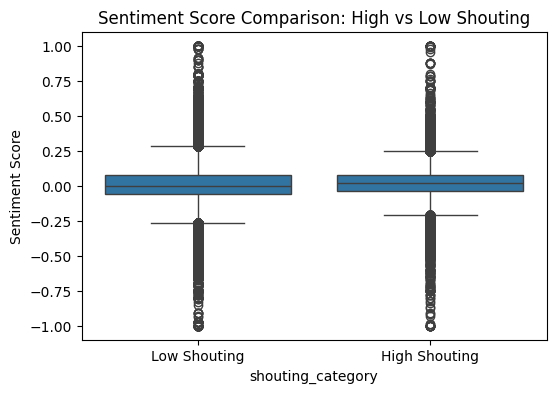

In [12]:
"""Hypothesis 5: Complaints with more "shouting" tend to have 
more negative sentiment score"""

# Calculate shouting intensity
data_eda["shouting_intensity"] = (
    data_eda["all_caps_count"] + 
    data_eda["exclamation_count"] + 
    data_eda["question_count"] + 
    data_eda["elongated_count"]
)

# Categorize into high-shouting vs low-shouting
data_eda["shouting_category"] = data_eda["shouting_intensity"].apply(
    lambda x: "High Shouting" if x > 5 else "Low Shouting"
)

# Compare mean sentiment score
high_shouting_mean = data_eda[data_eda["shouting_category"] == "High Shouting"]["sentiment_score"].mean()
low_shouting_mean = data_eda[data_eda["shouting_category"] == "Low Shouting"]["sentiment_score"].mean()

print("High Shouting Mean Sentiment Score:", high_shouting_mean)
print("Low Shouting Mean Sentiment Score:", low_shouting_mean)

# Boxplot comparison
plt.figure(figsize=(6, 4))
sb.boxplot(x="shouting_category", y="sentiment_score", data=data_eda)
plt.title("Sentiment Score Comparison: High vs Low Shouting")
plt.ylabel("Sentiment Score")
plt.show()

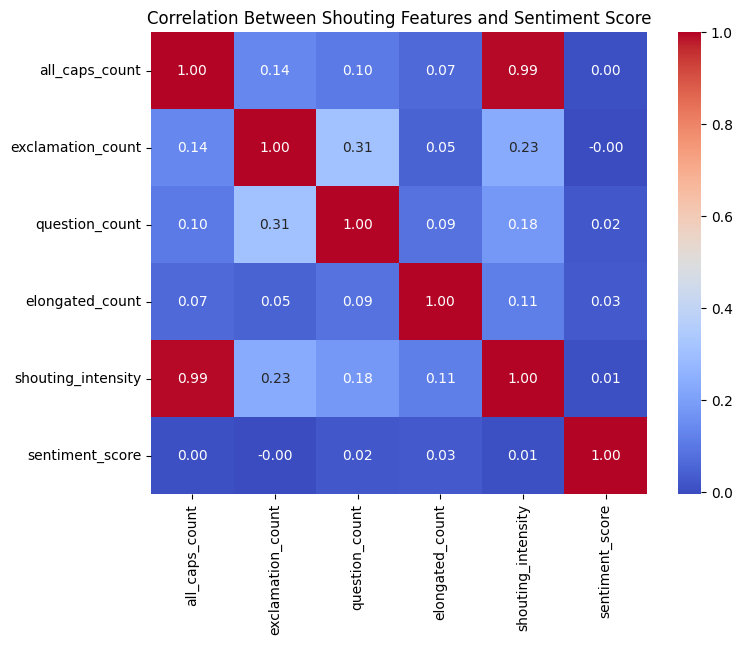

In [28]:
"""Hypothesis 5: Complaints with more "shouting" tend to have 
more negative sentiment score"""

# Check correlation between shouting_features and sentiment_score
shouting_features = ["all_caps_count", "exclamation_count", 
                     "question_count", "elongated_count", "shouting_intensity","sentiment_score"]
correlation_matrix = data_eda[shouting_features].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sb.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Shouting Features and Sentiment Score")
plt.show()

In [13]:
data_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 367267 entries, 29904 to 912553
Data columns (total 27 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   Date received                 367267 non-null  object  
 1   Product                       367267 non-null  object  
 2   Sub-product                   316921 non-null  object  
 3   Issue                         367267 non-null  object  
 4   Sub-issue                     253959 non-null  object  
 5   Consumer complaint narrative  367267 non-null  object  
 6   Company public response       173301 non-null  object  
 7   Company                       367267 non-null  object  
 8   State                         365901 non-null  object  
 9   ZIP code                      281676 non-null  object  
 10  Tags                          64405 non-null   object  
 11  Consumer consent provided?    367267 non-null  object  
 12  Submitted via                 3

Mean Sentiment Score (Disputed): 0.010028463742104084
Mean Sentiment Score (Not Disputed): 0.009994356014125565


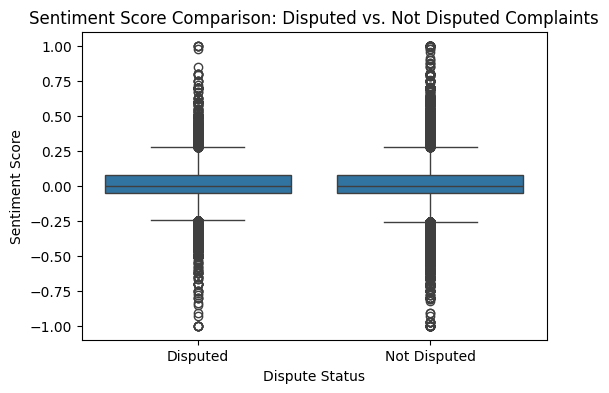

In [30]:
""" Hypothesis 6: Complaint with more negative sentiment score is 
more likely to get disputed"""

# Group complaints by dispute status
disputed = data_eda[data_eda["Consumer disputed?"] == "Yes"]
not_disputed = data_eda[data_eda["Consumer disputed?"] == "No"]

# Compare mean sentiment scores
print("Mean Sentiment Score (Disputed):", disputed["sentiment_score"].mean())
print("Mean Sentiment Score (Not Disputed):", not_disputed["sentiment_score"].mean())

# Create a DataFrame for plotting
plot_data = pd.concat([
    pd.DataFrame({"Sentiment Score": disputed["sentiment_score"], "Dispute Status": "Disputed"}),
    pd.DataFrame({"Sentiment Score": not_disputed["sentiment_score"], "Dispute Status": "Not Disputed"})
])

# Plot boxplot for comparison
plt.figure(figsize=(6, 4))
sb.boxplot(x="Dispute Status", y="Sentiment Score", data=plot_data)
plt.title("Sentiment Score Comparison: Disputed vs. Not Disputed Complaints")
plt.ylabel("Sentiment Score")
plt.show()

In [31]:
""" Check issue category distribution to select 5 from them"""

pd.set_option('display.max_rows', None)
# Get counts
issue_counts = data_eda['Issue'].value_counts()
# Get normalized proportion percentages
issue_percentages = data_eda['Issue'].value_counts(normalize=True) * 100
# Combine both into a single DataFrame
issue_summary = pd.DataFrame({'Issue': issue_counts.index, 
                              'Count': issue_counts.values, 
                              'Proportion Percentage': issue_percentages.values})

# Show result
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None) 
display(issue_summary)

,Issue,Count,Proportion Percentage
0,Incorrect information on your report,41370,11.264285
1,Problem with a credit reporting company's investigation into an existing problem,22381,6.093932
2,Incorrect information on credit report,20162,5.489739
3,Attempts to collect debt not owed,19230,5.235973
4,Cont'd attempts collect debt not owed,16836,4.584131
5,"Loan servicing, payments, escrow account",14717,4.007166
6,Improper use of your report,13567,3.694043
7,Communication tactics,11341,3.087944
8,"Loan modification,collection,foreclosure",10774,2.933561
9,Trouble during payment process,9147,2.490559


In [14]:
""" Top 5 frequent issues in each product category"""
product_col = "Product"
issue_col = "Issue"  

# Compute top 5 issues
top_issues_by_product = (
    data_eda.groupby(product_col)[issue_col]
    .value_counts()
    .groupby(level=0)
    .head(5)
    .reset_index(name="Count") 
)

display(top_issues_by_product)

,Product,Issue,Count
0,Bank account or service,"Account opening, closing, or management",6331
1,Bank account or service,Deposits and withdrawals,3424
2,Bank account or service,Problems caused by my funds being low,2084
3,Bank account or service,Using a debit or ATM card,1596
4,Bank account or service,"Making/receiving payments, sending money",1432
...,...,...,...
84,Vehicle loan or lease,Incorrect information on your report,461
85,Virtual currency,Other service issues,8
86,Virtual currency,Fraud or scam,4
87,Virtual currency,Other transaction issues,2


In [15]:
""" Check product category distribution for selected issue category """

# Define the 5 selected issues
selected_issues = [
    "Fraud or scam",
    "Identity theft / Fraud / Embezzlement",
    "Trouble during payment process",
    "Took or threatened to take negative or legal action",
    "Incorrect information on credit report",
    "Attempts to collect debt not owed"
]

# Filter the data for selected issues
filtered_data = data_eda[data_eda["Issue"].isin(selected_issues)]

# Count occurrences of each product per issue
issue_product_counts = (
    filtered_data.groupby(["Issue", "Product"])
    .size()
    .reset_index(name="Count")
)

# Print the results with better formatting
for issue in selected_issues:
    print(f"\n{'=' * 60}\n📌 Issue: {issue}\n{'-' * 60}")

    issue_data = issue_product_counts[issue_product_counts["Issue"] == issue]

    for _, row in issue_data.iterrows():
        print(f"  - {row['Product']:<50} {row['Count']:>6}")  # Aligning text & numbers

print("=" * 60)  # Final separator


📌 Issue: Fraud or scam
------------------------------------------------------------
  - Credit reporting, credit repair services, or other personal consumer reports    152
  - Money transfer, virtual currency, or money service   1443
  - Money transfers                                       507
  - Other financial service                               125
  - Prepaid card                                          310
  - Virtual currency                                        4

📌 Issue: Identity theft / Fraud / Embezzlement
------------------------------------------------------------
  - Credit card                                          1716

📌 Issue: Trouble during payment process
------------------------------------------------------------
  - Mortgage                                             9147

📌 Issue: Took or threatened to take negative or legal action
------------------------------------------------------------
  - Debt collection                                      54

In [16]:
""" Drop unnecessary columns """

# Define columns to drop
columns_to_drop = [
    "Date received", "Product", "Sub-product", "Sub-issue", 
    "Company public response", "Company", "State", "ZIP code", 
    "Tags", "Consumer consent provided?", "Submitted via", 
    "Date sent to company", "Company response to consumer", 
    "Timely response?", "Consumer disputed?", "Complaint ID"
]
data_prep = data_eda.drop(columns=columns_to_drop)

# Display basic info of data_prep
data_prep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 367267 entries, 29904 to 912553
Data columns (total 11 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Issue                         367267 non-null  object 
 1   Consumer complaint narrative  367267 non-null  object 
 2   Complaint_Length              367267 non-null  int64  
 3   Word_Count                    367267 non-null  int64  
 4   sentiment_score               367267 non-null  float64
 5   all_caps_count                367267 non-null  int64  
 6   exclamation_count             367267 non-null  int64  
 7   question_count                367267 non-null  int64  
 8   elongated_count               367267 non-null  int64  
 9   shouting_intensity            367267 non-null  int64  
 10  shouting_category             367267 non-null  object 
dtypes: float64(1), int64(7), object(3)
memory usage: 41.7+ MB


In [17]:
""" Filter the selected issue categories and rename them"""

# Define issue category mapping
category_mapping = {
    "Fraud or scam": "fraud_scam_identity_theft",  
    "Identity theft / Fraud / Embezzlement": "fraud_scam_identity_theft",
    "Trouble during payment process": "trouble_during_payment_process",
    "Took or threatened to take negative or legal action": "threatened_negative_legal_action",
    "Incorrect information on credit report": "incorrect_info_credit_report",
    "Attempts to collect debt not owed": "attempt_collect_debt_not_owed"
}

# Filter the dataset
selected_issues = list(category_mapping.keys())
data_prep = data_prep[data_prep["Issue"].isin(selected_issues)].copy()

# Show before rename issue category count
print("Before rename issue category:")
data_prep["Issue"].value_counts()

Before rename issue category:


Issue
Incorrect information on credit report                 20162
Attempts to collect debt not owed                      19230
Trouble during payment process                          9147
Took or threatened to take negative or legal action     5473
Fraud or scam                                           2541
Identity theft / Fraud / Embezzlement                   1716
Name: count, dtype: int64

In [18]:
# Rename issue categories
data_prep["Issue"] = data_prep["Issue"].map(category_mapping)

# Display the value count of each issue category
print("\nAfter rename issue category:")
data_prep["Issue"].value_counts()


After rename issue category:


Issue
incorrect_info_credit_report        20162
attempt_collect_debt_not_owed       19230
trouble_during_payment_process       9147
threatened_negative_legal_action     5473
fraud_scam_identity_theft            4257
Name: count, dtype: int64

In [19]:
""" Detect potential text issues in Consumer complaint narrative """

# Check text issues of complaint narrative
data_prep = data_prep.copy()

# Define functions to detect text issues
# Detect emojis
def has_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

# Detect special characters or symbols
special_char_pattern = re.compile(r'[^\w\s.,!?;:()\-\']')
def has_special_characters(text):
    return bool(special_char_pattern.search(text))

# Detect consecutive redundant words
def has_redundant_words(text):
    return bool(re.search(r'\b(\w+)\s+\1\b', text))

# Detect redundant punctuations
def has_redundant_punctuation(text):
    return bool(re.search(r'([.,!?;:()\-])\1+', text))

# Detect leading whitespace
def has_leading_whitespace(text):
    return bool(re.match(r'^\s+', text))

# Detect number/values/integers/float/date ($1800, 2 days, 14/6/2018)
def has_value(text):
    return bool(re.search(r'\d+', text))

# Detect URL
url_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
www_pattern = re.compile(r'www\.[a-zA-Z0-9-]+(?:\.[a-zA-Z]{2,})+')
def has_url(text):
    return bool(url_pattern.search(text) or www_pattern.search(text))

# Detect HTML tags <>
html_pattern = re.compile(r'<.*?>')
def has_html_tags(text):
    return bool(html_pattern.search(text))

# Detect contractions (I'll, I'm, you're, haven't)
def has_contraction(text):
    return any(contractions.fix(word) != word for word in text.split())

# Detect repetitive characters
def has_repetitive_characters(text):
    return bool(re.search(r'([a-zA-Z])\1{2,}', text))

# List of issue detection functions
issue_detectors = {
    "Has_Emoji": has_emoji,
    "Has_Special_Characters": has_special_characters,
    "Has_Leading_Whitespace": has_leading_whitespace,
    "Has_Redundant_Words": has_redundant_words,
    "Has_Value": has_value,
    "Has_URL": has_url,
    "Has_HTML_Tags": has_html_tags,
    "Has_Contraction": has_contraction,
    "Has_Repetitive_Characters": has_repetitive_characters
}

# Detect issues and count occurrences
issue_counts = {}
for issue_name, func in issue_detectors.items():
    count = data_prep['Consumer complaint narrative'].apply(func).sum()
    issue_counts[issue_name] = count
    # If issue appears, create new column for the count
    if count > 0:
        data_prep[issue_name] = data_prep['Consumer complaint narrative'].apply(func)

# Display issue summary
print("Issue counts in the dataset:")
for issue_name, count in issue_counts.items():
    print(f"- {issue_name.replace('_', ' ')}: {count}")

# Define function to show safe sample
def safe_sample(dataframe, condition, num_samples):
    matching_rows = dataframe[condition] if condition.name in dataframe else []
    sample_size = min(len(matching_rows), num_samples)
    return matching_rows.sample(sample_size) if sample_size > 0 else pd.DataFrame()

# Show complaint narrative samples with corresponding text issues
pd.set_option('display.max_colwidth', None)

for issue_name, count in issue_counts.items():
    if count > 0:
        print(f"\nSample reviews with {issue_name.replace('_', ' ').lower()}:")
        print(safe_sample(data_prep, data_prep[issue_name], 3)['Consumer complaint narrative'])

Issue counts in the dataset:
- Has Emoji: 0
- Has Special Characters: 38187
- Has Leading Whitespace: 0
- Has Redundant Words: 3469
- Has Value: 37853
- Has URL: 159
- Has HTML Tags: 545
- Has Contraction: 14298
- Has Repetitive Characters: 850

Sample reviews with has special characters:
722223                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [20]:
""" Text preprocessing to handle aforementioned text issues """

# Define the RepeatReplacer class for handling repetitive characters
class RepeatReplacer:
    def __init__(self):
        self.repeat_regexp = re.compile(r'(\w*)(\w)\2(\w*)')
        self.repl = r'\1\2\3'
 
    def replace(self, word):
        # Check if the word is valid in WordNet
        if wordnet.synsets(word):  
            return word
        repl_word = self.repeat_regexp.sub(self.repl, word)
        # If the word was changed, continue reducing
        if repl_word != word:  
            return self.replace(repl_word)
        else:  # Return the reduced word
            return repl_word
 
# Initialize the replacer
replacer = RepeatReplacer()

# Define function to process the text issues
def clean_text(text):
    # Lowercase all words
    text = text.lower()
    # Expand contractions
    text = contractions.fix(text)
    # Remove URLs starting with http/https
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    # Remove URLs starting with www
    text = re.sub(r'www\.[a-zA-Z0-9-]+(?:\.[a-zA-Z]{2,})+', '', text)
    # Remove html tags with the content inside "<P/>"
    text = re.sub(r'<\s*\w+\s*/>', '', text)
    # Remove words with values
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    # Remove redundant punctuations
    text = re.sub(r'([.,!?;:()\-])\1+', r'\1', text)
    # Expand contractions again
    text = contractions.fix(text)
    # Remove all punctuation to facilitate shortening of repetitive character
    text = re.sub(r'(?<!\w)-|-(?!\w)|[^\w\s-]', ' ', text)
    # Shorten repetitive letters
    text = ' '.join([replacer.replace(word) for word in text.split()])
    # Remove redundant words
    text = re.sub(r'\b(\w+)( \1)+\b', r'\1', text)
    
    return text

# Create new column for the cleaned review text
data_prep['Complaint_cleaned'] = data_prep['Consumer complaint narrative'].apply(clean_text)

# Check the review_text_cleaned still have the aforementioned issues or not
data_prep['Cleaned_Has_Special_Characters'] = data_prep['Complaint_cleaned'].apply(has_special_characters)
data_prep['Cleaned_Has_Redundant_Words'] = data_prep['Complaint_cleaned'].apply(has_redundant_words)
data_prep['Cleaned_Has_Value'] = data_prep['Complaint_cleaned'].apply(has_value)
data_prep['Cleaned_Has_URL'] = data_prep['Complaint_cleaned'].apply(has_url)
data_prep['Cleaned_Has_HTML_Tags'] = data_prep['Complaint_cleaned'].apply(has_html_tags)
data_prep['Cleaned_Has_Contraction'] = data_prep['Complaint_cleaned'].apply(has_contraction)
data_prep['Cleaned_Has_Repetitive_Char'] = data_prep['Complaint_cleaned'].apply(has_repetitive_characters)

# Summarize the findings
print(f"Number of complaints with special characters: {data_prep['Cleaned_Has_Special_Characters'].sum()}")
print(f"Number of complaints with redundant words: {data_prep['Cleaned_Has_Redundant_Words'].sum()}")
print(f"Number of complaints with values: {data_prep['Cleaned_Has_Value'].sum()}")
print(f"Number of complaints with URLs: {data_prep['Cleaned_Has_URL'].sum()}")
print(f"Number of complaints with contractions: {data_prep['Cleaned_Has_Contraction'].sum()}")
print(f"Number of complaints with HTML tags: {data_prep['Cleaned_Has_HTML_Tags'].sum()}")
print(f"Number of complaints with repetitive characters: {data_prep['Cleaned_Has_Repetitive_Char'].sum()}")

Number of complaints with special characters: 0
Number of complaints with redundant words: 0
Number of complaints with values: 0
Number of complaints with URLs: 0
Number of complaints with contractions: 257
Number of complaints with HTML tags: 0
Number of complaints with repetitive characters: 243


In [41]:
""" Display comparison before text preprocessing and after text preprocessing """

# Define function to display issues for comparison
def display_issues(data_prep, issue_column, issue_name):
    filtered_data = data_prep[data_prep[issue_column]]
    print(f"\nRows with {issue_name}:")
    return filtered_data[['Consumer complaint narrative', 'Complaint_cleaned']].head(3)

# Display rows special characters
display_issues(data_prep, 'Has_Special_Characters', 'Special Characters')


Rows with Special Characters:


,Consumer complaint narrative,Complaint_cleaned
35079,"Starting in // I started receiving calls from ability recovery solutions regarding a Medical bill they claimed wasn't paid and I told them I was approved for SSI and Medicaid in //. I had been fighting for for a few years altogether, and they backdated the Effective date for Medicaid back to // they told me to call the hospitals and have them pull the accounts they had sent to collections back and file them with Medicaid instead. The hospital that the bill came from told me they pulled them all back and they were paid and closed. Well, I started getting calls from the collection company, and when I said to them that debt was paid they got rude and said to send proof to them, then they might close it. But when I tried to communicate with them about it they got hateful on the phone and threating towards me, and I called the hospital the bill came from, and they said they shouldn't be collecting on that debt, and they tried to contact them. but they refused to take it off my credit report and kept calling multiple times daily threating legal action and hurting my credit and because of them, my credit score dropped down really low. Also, they never sent proof in the mail about the debt when requested",starting in i started receiving calls from ability recovery solutions regarding a medical bill they claimed was not paid and i told them i was approved for si and medicaid in i had been fighting for a few years altogether and they backdated the effective date for medicaid back to they told me to call the hospitals and have them pull the accounts they had sent to collections back and file them with medicaid instead the hospital that the bill came from told me they pulled them all back and they were paid and closed well i started getting calls from the collection company and when i said to them that debt was paid they got rude and said to send proof to them then they might close it but when i tried to communicate with them about it they got hateful on the phone and threating towards me and i called the hospital the bill came from and they said they should not be collecting on that debt and they tried to contact them but they refused to take it off my credit report and kept calling multiple times daily threating legal action and hurting my credit and because of them my credit score dropped down really low also they never sent proof in the mail about the debt when requested
35946,"// - called Rushmore Loan Management Services for pay off amount // - Rushmore mailed letter with payoff amount of {$0.00} and recording fee of {$73.00} for total amount owed by //. // - letter received via mail ; made online payment via wire through for pay off amount at , CST, with tracking # given from , see *email* confirmation. Your money transfer 's complete. The money will be available in CASHIERING DEPARTMENT RUSHMORE LOAN MANAGEMENT 's bank account by //. Need help? Chat online or call us toll free 24/7 at . Thanks for using . ________________________________________ For a mobile transaction, this is your receipt. For all other transactions this is a summary of your online receipt. ________________________________________ Your tracking number ( ) is : Transaction Date : // ET. Recd alert from of credit filing of delinquency ; contacted Rushmore. They said they never received payment ; I gave them all the information of the receipt of submitting. I've called numerous times and they kept saying they never received. Gave them the tracking # I had. There is no one else I can speak with ; there is no email address that can be used to communicate and deliver documentation. Either fax or regular mail. No attempt on their part to track receipt of said money using the information provided. rec 'd another statement dated // indicating owing {$0.00}. Again I called and resubmitted the information regarding payment information ; they replied they had no way to track it, as they never received. Another notifica

In [40]:
# Display rows with redundant words
display_issues(data_prep, 'Has_Redundant_Words', 'Redundant Words')


Rows with Redundant Words:


,Consumer complaint narrative,Complaint_cleaned
35079,"Starting in // I started receiving calls from ability recovery solutions regarding a Medical bill they claimed wasn't paid and I told them I was approved for SSI and Medicaid in //. I had been fighting for for a few years altogether, and they backdated the Effective date for Medicaid back to // they told me to call the hospitals and have them pull the accounts they had sent to collections back and file them with Medicaid instead. The hospital that the bill came from told me they pulled them all back and they were paid and closed. Well, I started getting calls from the collection company, and when I said to them that debt was paid they got rude and said to send proof to them, then they might close it. But when I tried to communicate with them about it they got hateful on the phone and threating towards me, and I called the hospital the bill came from, and they said they shouldn't be collecting on that debt, and they tried to contact them. but they refused to take it off my credit report and kept calling multiple times daily threating legal action and hurting my credit and because of them, my credit score dropped down really low. Also, they never sent proof in the mail about the debt when requested",starting in i started receiving calls from ability recovery solutions regarding a medical bill they claimed was not paid and i told them i was approved for si and medicaid in i had been fighting for a few years altogether and they backdated the effective date for medicaid back to they told me to call the hospitals and have them pull the accounts they had sent to collections back and file them with medicaid instead the hospital that the bill came from told me they pulled them all back and they were paid and closed well i started getting calls from the collection company and when i said to them that debt was paid they got rude and said to send proof to them then they might close it but when i tried to communicate with them about it they got hateful on the phone and threating towards me and i called the hospital the bill came from and they said they should not be collecting on that debt and they tried to contact them but they refused to take it off my credit report and kept calling multiple times daily threating legal action and hurting my credit and because of them my credit score dropped down really low also they never sent proof in the mail about the debt when requested
38307,RASH CURTIS & ASSOCIATES is reporting a ridiculous amount of 11 collections on my credit report that do NOT belong to me in first place. I was never a patient of Original creditor - whom I contacted and they had nothing available to provide me to prove the ownership or to validate this account. I attempted numverous times to speak to someone in person at Rush and Curtis only to be told that I need to write them a letter. Today after a total of 5 letters 3 months in I have NOT heard anything back from them. I disputed these 11 collections with credit bureaus but they sent me letters stating that rash and Curtis has validated these accounts ... how ... when I was never a patient at verity medical foundation how are they validating .THIS IS FRAUD .... today I was given a message from my receptionist that rash and Curtis called asking for a payment they pretended that I advised them to call my work and have my accountant to pay these over the phone. THIS IS FRAUD ON A TOTALLY DIFFERENT LEVEL WHY WHY ARE THEY GETTING AWAY WITH THIS. I RECORDED A CALL AND WILL BE SENDING THIS TO FTC AND OTHER OTHORITIES IF THESE ERRONEOUS COLLECTIONS ARE NOT REMOVED FROM MY CREDIT REPORT IMMEDIATELY ...,rash curtis associates is reporting a ridiculous amount of collections on my credit report that do not belong to me in first place i was never a patient of original creditor whom i contacted and they had nothing available to provide me to prove the ownership or to validate this account i attempted numverous times to speak to someon

In [41]:
# Display rows that have values & numbers
display_issues(data_prep, 'Has_Value', 'Values')


Rows with Values:


,Consumer complaint narrative,Complaint_cleaned
35946,"// - called Rushmore Loan Management Services for pay off amount // - Rushmore mailed letter with payoff amount of {$0.00} and recording fee of {$73.00} for total amount owed by //. // - letter received via mail ; made online payment via wire through for pay off amount at , CST, with tracking # given from , see *email* confirmation. Your money transfer 's complete. The money will be available in CASHIERING DEPARTMENT RUSHMORE LOAN MANAGEMENT 's bank account by //. Need help? Chat online or call us toll free 24/7 at . Thanks for using . ________________________________________ For a mobile transaction, this is your receipt. For all other transactions this is a summary of your online receipt. ________________________________________ Your tracking number ( ) is : Transaction Date : // ET. Recd alert from of credit filing of delinquency ; contacted Rushmore. They said they never received payment ; I gave them all the information of the receipt of submitting. I've called numerous times and they kept saying they never received. Gave them the tracking # I had. There is no one else I can speak with ; there is no email address that can be used to communicate and deliver documentation. Either fax or regular mail. No attempt on their part to track receipt of said money using the information provided. rec 'd another statement dated // indicating owing {$0.00}. Again I called and resubmitted the information regarding payment information ; they replied they had no way to track it, as they never received. Another notification of now the delinquency of over 60 days. // - another call to Rushmore asking for assistance of tracking my payment and resolving the credit reporting. Still no assistance in helping. Therefore, I went to my bank and REWIRED ANOTHER PAYMENT. // - CST resent ANOTHER wire transfer with an additional cost to me of {$25.00} -- Also, contacted on // and they have record from , Rushmore Loan Management Services received funds //. Trace # is . // - again called Rushmore to give them information that I just wired ANOTHER PAYMENT and was told to call back on Friday, // to verify they received. // - called and they verified payment received and closed account. I asked about next step in resolving credit reporting and also let them know they now have received TWO payments from me. Gave them additional information again for THEIR bank with a tracking # . Their records indicate a follow up is needed by me next Wednesday, //. Asked them to report to credit agencies their reporting that the account was not delinquent which affected my CREDIT SCORE greatly. They indicated they would send to consumer affairs department for investigation however it is still under investigation. They offer no customer service to assist in rectifying the situation other than the customer doing all the calling ; following up. I was told to call //, or I can mail/fax communication and wait again for reply. There is no other communication other than the one customer service line and you are unable to speak with anyone else ; no supervisor or anyone other than the rep on the phone. This loan was first taken from and the account was turned over in // to Rushmore Loan. In six years paying the mortgage for a payoff amount of {$0.00} this company has ruined my credit and is making no attempts to assist in correcting the problem. As of today //, Rushmore has now an additional {$73.00} due to the double payment in which they can not tell me how or when the payment will be reissued back to me. Again, no one to speak with at all to assist in resolving issue. I have made every attempt possible to rectify the situation with no assistance whatsoever from Rushmore other than being treated like an individual who is trying NOT to pay a {$0.00} debt when I clearly paid a {$15000.00} debt I owed timely. I am looking for restitution of my {$73.00} over payment ; in addition to clearing my credit report of false information.

In [42]:
# Display rows that have urls
display_issues(data_prep, 'Has_URL', 'URLs')


Rows with URLs:


,Consumer complaint narrative,Complaint_cleaned
47190,"I received a notification from my mortgage company, LoanCare which stated that my mortgage payment was not made for the month of // in the amount of {$570.00}. I was able to obtain the cancelled checks for the // and // from which had sent the payment to the following address : . . , PA It is clear to see on the back of check # on // was deposited into a account. The back of check # on // reflects the correct account of deposit as which signifies LoanCare . I forwarded copies of both of these cancelled checks to LoanCare on // and was given a confirmation # hoping that LoanCare would rectify the problem. I called , which is a subsidiary of some sort of Loancare, which resulted in a recording informing me to log into my account at www.myloancare.com. I have gone to my bank and stopped the bi-monthly withdrawals from my checking account by .",i received a notification from my mortgage company loancare which stated that my mortgage payment was not made for the month of in the amount of i was able to obtain the cancelled checks for the and from which had sent the payment to the following address pa it is clear to see on the back of check on was deposited into a account the back of check on reflects the correct account of deposit as which signifies loancare i forwarded copies of both of these cancelled checks to loancare on and was given a confirmation hoping that loancare would rectify the problem i called which is a subsidiary of some sort of loancare which resulted in a recording informing me to log into my account at i have gone to my bank and stopped the bi-monthly withdrawals from my checking account by
48336,"We have received NOTHING by mail but has apparently transferred our mtg without proper notification. I already scheduled my payment for // online through the page it is their only option to pay online as I have since they started handling the loan. Top of page had red letter heading about IF YOUR LOAN WAS TRANSFERRED ... So when done I went to my email acct and logged in today // and In an Email dated // so at earliest if I checked emails everyday I would have recvd it // I find a notice from saying they are transferring our loan as of //. WTH? That is a 1 week notice for something as BIG as Changing where we send our Mtg payments? And NOTHING IN WRITING IN THE MAIL? And I am supposed to send my payments to Mr. Cooper DBA as Nationstar Mtg? This does not even sound real OR Legit, Mr. Cooper DBA? This is the email I received. To : // at is the servicer for the loan ending in . You should have received a Transfer of Servicing Notice from us indicating that, effective // ( "" Transfer Date '' ), the servicing of your mortgage loan will transfer to Nationstar Mortgage LLC d/b/a Mr. Cooper ( "" Mr. Cooper '' ). This means that Mr. Cooper will start accepting payments on // at Nationstar Mortgage LLC d/b/a Mr. Cooper, Payment Processing, , , T . If you have scheduled any payments for after the Transfer Date through , those payments will be cancelled and you will need to contact Mr. Cooper to reschedule them. If you use online bill pay through you financial institution, you will need to change the payment information to Mr. Cooper. Nothing about the terms of your mortgage loan will change. You should receive a letter after the Transfer Date from Mr. Cooper with your new loan number, additional information and instructions for setting up a new online secure account at www.mrcooper.com. In the meantime, you can find additional information on our website here. If you have not made your // payment, you can still make your payment quickly and easily online until //. Remember, all payments made on or after // should be made to Mr. Cooper. Sincerely, Seterus , Inc . They say after won't even be able to access documents, but only documents available are tax no other files for transfer from B of A or anything have anything in them now ... provides no number for live contact via pho

In [45]:
# Display contractions
display_issues(data_prep, 'Has_Contraction', 'Contractions')


Rows with Contractions:


,Consumer complaint narrative,Complaint_cleaned
35079,"Starting in // I started receiving calls from ability recovery solutions regarding a Medical bill they claimed wasn't paid and I told them I was approved for SSI and Medicaid in //. I had been fighting for for a few years altogether, and they backdated the Effective date for Medicaid back to // they told me to call the hospitals and have them pull the accounts they had sent to collections back and file them with Medicaid instead. The hospital that the bill came from told me they pulled them all back and they were paid and closed. Well, I started getting calls from the collection company, and when I said to them that debt was paid they got rude and said to send proof to them, then they might close it. But when I tried to communicate with them about it they got hateful on the phone and threating towards me, and I called the hospital the bill came from, and they said they shouldn't be collecting on that debt, and they tried to contact them. but they refused to take it off my credit report and kept calling multiple times daily threating legal action and hurting my credit and because of them, my credit score dropped down really low. Also, they never sent proof in the mail about the debt when requested",starting in i started receiving calls from ability recovery solutions regarding a medical bill they claimed was not paid and i told them i was approved for si and medicaid in i had been fighting for a few years altogether and they backdated the effective date for medicaid back to they told me to call the hospitals and have them pull the accounts they had sent to collections back and file them with medicaid instead the hospital that the bill came from told me they pulled them all back and they were paid and closed well i started getting calls from the collection company and when i said to them that debt was paid they got rude and said to send proof to them then they might close it but when i tried to communicate with them about it they got hateful on the phone and threating towards me and i called the hospital the bill came from and they said they should not be collecting on that debt and they tried to contact them but they refused to take it off my credit report and kept calling multiple times daily threating legal action and hurting my credit and because of them my credit score dropped down really low also they never sent proof in the mail about the debt when requested
35946,"// - called Rushmore Loan Management Services for pay off amount // - Rushmore mailed letter with payoff amount of {$0.00} and recording fee of {$73.00} for total amount owed by //. // - letter received via mail ; made online payment via wire through for pay off amount at , CST, with tracking # given from , see *email* confirmation. Your money transfer 's complete. The money will be available in CASHIERING DEPARTMENT RUSHMORE LOAN MANAGEMENT 's bank account by //. Need help? Chat online or call us toll free 24/7 at . Thanks for using . ________________________________________ For a mobile transaction, this is your receipt. For all other transactions this is a summary of your online receipt. ________________________________________ Your tracking number ( ) is : Transaction Date : // ET. Recd alert from of credit filing of delinquency ; contacted Rushmore. They said they never received payment ; I gave them all the information of the receipt of submitting. I've called numerous times and they kept saying they never received. Gave them the tracking # I had. There is no one else I can speak with ; there is no email address that can be used to communicate and deliver documentation. Either fax or regular mail. No attempt on their part to track receipt of said money using the information provided. rec 'd another statement dated // indicating owing {$0.00}. Again I called and resubmitted the information regarding payment information ; they replied they had no way to track it, as they never received. Another notifica

In [44]:
# Display rows for HTML tags
display_issues(data_prep, 'Has_HTML_Tags', 'HTML Tags')


Rows with HTML Tags:


Consumer complaint narrative  \
58786                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 // I awoke to a series of emails from Paypal. Two of them stated that I added a new address to my account. Two of them stated that I added a new credit card to my account, two emails stated that there were funds sent out of the account for purchase, followed by an email stating that there appeared to be suspicious transactions and an email or two about changing my password. Obviously, my account was hacked, as I did not authorize or initiate any of the transactions. I went into my account ( dont remember if I followed a link from one of the emails, or entered the account separately ) and changed my password. At this point, it looked like Paypal was aware that there was an issue and it looked like theyd take care of it. // I noticed that a {$2900.00} charge appeared on my credit card. Instinctively, I called and reported that the charge was fraudulent. told me they would take care of it and removed the charge from my account. What I found ou

In [43]:
# Display rows for repetitive letters
display_issues(data_prep, 'Has_Repetitive_Characters', 'Repetitive Characters')


Rows with Repetitive Characters:


Consumer complaint narrative  \
44240                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [47]:
# Check for the remaining contractions in Complaint_cleaned
display_issues(data_prep, 'Cleaned_Has_Contraction', 'Contraction (Complaint_cleaned)')


Rows with Contraction (Complaint_cleaned):


,Consumer complaint narrative,Complaint_cleaned
41446,"Please read attached file it Has the complaint details along with clear and convincing evidence this collection should never exist knowing the facts stated in details in the attached file. Threatening and suggesting negative consequences on my credit report sustain. This company didnt do what it said it will. Playing those tactics of vague replying not answering the real question this complaint asks all the violators of rights to answer. Why this collection if its works on behalf on or why not used the auto payment which is valid to get paid for what it alleges that I owe? If anything legitimate or if its charges are legitimate, what prevents from debiting my credit account that it did regularly and I never stopped ? Showing off all those paper? I have documents I could use to sue thus collection and both and I reserve right to do so any time without prior notice and without waiving my rights .so checking my credit today using my basic credit monitoring service and I saw this Sprints collection from source Receivables Management ( SRM ) ( correction on the exact name of the current collection is Source Receivable management ) still on my credit file or report .another important thing. I never claimed fraud to anyone in regard to this matter. created that by itself and it will assume responsibility for saying something I didnt state .you need to comply to law after u showed you all the proofs that is not serious about getting paid and they broke their policy of auto payment and I have copy of that policy. They need to have a life and let me on peace before they receive a legal summon from a U.S Marshall and then it would be late to settle because you will all pay big legal price. Please dont say something I didnt say in my complaint. Your interim response before is rejected at its entirely and stop threatening and harassing me. those desperate tactics from all the violators to cause me more harms than theyve done already, It is noted and it will be used in a court of law if necessary. All stated herein is to my current state of knowledge belief and understanding and it is subject to anything or any correction by me only at any time without prior notice and without waiving my rights. Please refer to the attached file for more factual information with proofs attached within the file. Does or SRM have any court order to abuse my rights?",please read attached file it has the complaint details along with clear and convincing evidence this collection should never exist knowing the facts stated in details in the attached file threatening and suggesting negative consequences on my credit report sustain this company did not do what it said it will playing those tactics of vague replying not answering the real question this complaint asks all the violators of rights to answer why this collection if its works on behalf on or why not used the auto payment which is valid to get paid for what it alleges that i owe if anything legitimate or if its charges are legitimate what prevents from debiting my credit account that it did regularly and i never stopped showing off all those paper i have documents i could use to sue thus collection and both and i reserve right to do so any time without prior notice and without waiving my rights so checking my credit today using my basic credit monitoring service and i saw this sprints collection from source receivables management srm correction on the exact name of the current collection is source receivable management still on my credit file or report another important thing i never claimed fraud to anyone in regard to this matter created that by itself and it will assume responsibility for saying something i did not state you need to comply to law after you showed you all the proofs that is not serious about getting paid and they broke their policy of auto payment and i have copy of that policy they need to have a life and let me on peace before they

In [46]:
# Check for the remaining repetitive character in Complaint_cleaned
display_issues(data_prep, 'Cleaned_Has_Repetitive_Char', 'Repetitive Character (Complaint_cleaned)')


Rows with Repetitive Character (Complaint_cleaned):


Consumer complaint narrative  \
45799  CONDITIONAL ACCEPTANCE AND COUNTER-OFFER FOR ACCOUNT SETTLEMENT AND CLOSURE Certified # : c/o . , WI, // Trustee in care of MS. PRINCIPAL CHIEF EECUTIVE OFFICER REGISTERED AGENT JPMORGAN CHASE CREDIT CARD , DE, This is a legal notice. Please read it carefully as it means what it says, do not ignore it. Respondent- NOTICE TO PRINCIPAL IS NOTICE TO AGENT AND NOTICE TO AGENT IS NOTICE TO PRINCIPAL RE : CONDITIONAL ACCEPTANCE FOR VALUE FOR PROOF OF CLAIM UPON CORPORATIONS CONTRACT, FOR DETERMINATION OF MEETING OF THE MINDS, FRAUD ON THE CONTRACT, AND/OR AN UNCONSCIONABLE CONTRACT AND/OR AGREEMENT FOR COMMERCIAL DISCHARGE, ENDING ACCOUNT No. : . Dear Ms. : On //, you were sent Notice of Adequate of Due Performance. This notice was sent by Certified Mail # . You did not respond accordingly. As soon as you provide the information requested, ( information which I believe I am entitled to under state and federal law ), in this conditional acceptance and counter-offer, I will gladly and timely fulfill my obligation. I am conditionally accepting your offer for the unverified items contained in the Account Ending # , upon proof of claim that : I, : , the undersigned decedent and authorized representative and trustee of the estate named person known as . Do hereby accept and agree to pay all debts, charges and obligations associated with the following account : upon proof of claim that the following conditions are met. 1. I demand proof of claim, that you provide a furnish a copy of Form 1099-A or an acceptable substitute statement also provide me with your federal tax identification number [ W-9 ] and your Internal Revenue Service at my above referenced address within 30 days. Failure to do so may result in a fine from the Internal Revenue Service division of the UNITED STATES Department OF THE TREASURY. 2. [ Per UCC 3-501 ( b ) ( 2 ) ], I demand proof of claim in that you : ( i ) EHIBIT THE INSTRUMENT THAT CREATED THE LIABILITY by providing a certified copy of the contract/compact/agreement/negotiable instrument which creates or created the liability for to pay or perform, per your claim. If it exists, provide a certified copy of the valid, two-party contract containing both parties signatures, which COMPELS me, a living Man to give you any real monies in the form of Silver or Gold for the alleged debt. Further, as Secured Party AND Creditor, I aver that I am acting in PRIVATE and IN HONOR. In order to REMAIN IN HONOR and NOT DISHONOR you or the Law, I ask for clarity on this question : Are you ( or your employer or any other party ) demanding/asking/requesting/requiring that I, a living Man give you property belonging to another - in this case, the FEDERAL RESERVE BANK ? If this is, in fact, the case, please PRINT YOUR NAME HERE : _________________________________________________________________________________________ and then SIGN YOUR NAME HERE : _________________________________________________________________________. 3. Per [ UCC 3-501 ( b ) ( 2 ) ], I demand proof of claim in that you : ( ii ) GIVE REASONABLE IDENTIFICATION OF THE PERSON MAKING PRESENTMENT AND PROVIDE EVIDENCE OF YOUR AUTHORITY TO MAKE IT, IF MADE FOR ANOTHER by identifying your company/corporation/agency by full name and place and date of birth ( such as the date of incorporation as well as the place/location of incorporation and/or the law used to create it. Please kindly provide a certified copy of proof of the authority that makes you the HOLDER IN DUE COURSE, to include the name of the Original Creditor, should this presentment be made on behalf of or for another. 4. Per [ UCC 3-501 ], should you fail to produce proof of necessary endorsement, I, without dishonoring your presentment, may : 1. ( i ) Return your presentment or 2. ( ii ) Refuse to pay or accept your claim/presentment for failure of the claim/presentment to comply with the terms of the instrument or 3. ( iii ) Refuse to pay or accept your claim/presentment 

In [ ]:
# Drop rows where 'Complaint_cleaned' is null or consists of whitespace only
data_cleaned = data_prep.copy()
data_cleaned = data_cleaned.dropna(subset=['Complaint_cleaned'])
data_cleaned = data_cleaned[data_cleaned['Complaint_cleaned'].str.strip() != '']

# Drop the original 'Consumer complaint narrative' column
data_cleaned = data_cleaned.drop(columns=['Consumer complaint narrative'])

# Rename 'Complaint_cleaned' to 'Complaint'
data_cleaned = data_cleaned.rename(columns={'Complaint_cleaned': 'Complaint'})

# Create new dataframe of 'Complaint' and 'Issue'
data_cleaned = data_cleaned[['Complaint', 'Issue']]

data_cleaned

,Complaint,Issue
35079,starting in i started receiving calls from ability recovery solutions regarding a medical bill they claimed was not paid and i told them i was approved for si and medicaid in i had been fighting for a few years altogether and they backdated the effective date for medicaid back to they told me to call the hospitals and have them pull the accounts they had sent to collections back and file them with medicaid instead the hospital that the bill came from told me they pulled them all back and they were paid and closed well i started getting calls from the collection company and when i said to them that debt was paid they got rude and said to send proof to them then they might close it but when i tried to communicate with them about it they got hateful on the phone and threating towards me and i called the hospital the bill came from and they said they should not be collecting on that debt and they tried to contact them but they refused to take it off my credit report and kept calling multiple times daily threating legal action and hurting my credit and because of them my credit score dropped down really low also they never sent proof in the mail about the debt when requested,attempt_collect_debt_not_owed
35946,called rushmore loan management services for pay off amount rushmore mailed letter with payoff amount of and recording fee of for total amount owed by letter received via mail made online payment via wire through for pay off amount at cst with tracking given from see email confirmation your money transfer s complete the money will be available in cashiering department rushmore loan management s bank account by need help chat online or call us toll free at thanks for using _ for a mobile transaction this is your receipt for all other transactions this is a summary of your online receipt _ your tracking number is transaction date et recd alert from of credit filing of delinquency contacted rushmore they said they never received payment i gave them all the information of the receipt of submitting i have called numerous times and they kept saying they never received gave them the tracking i had there is no one else i can speak with there is no email address that can be used to communicate and deliver documentation either fax or regular mail no attempt on their part to track receipt of said money using the information provided rec would another statement dated indicating owing again i called and resubmited the information regarding payment information they replied they had no way to track it as they never received another notification of now the delinquency of over days another call to rushmore asking for assistance of tracking my payment and resolving the credit reporting still no assistance in helping therefore i went to my bank and rewired another payment cst resent another wire transfer with an additional cost to me of also contacted on and they have record from rushmore loan management services received funds trace is again called rushmore to give them information that i just wired another payment and was told to call back on friday to verify they received called and they verified payment received and closed account i asked about next step in resolving credit reporting and also let them know they now have received two payments from me gave them additional information again for their bank with a tracking their records indicate a follow up is needed by me next wednesday asked them to report to credit agencies their reporting that the account was not delinquent which affected my credit score greatly they indicated they would send to consumer affairs department for investigation however it is still under investigation they offer no customer service to assist in rectifying the situation other than the customer doing all the calling following up i was told to call or i can mail fax communication and wait again for reply there is no other communication other than the one customer service line and you are unabl

In [19]:
""" Tokenization using NLTK """
# Tokenize Review_text using NLTK regexp tokenization
pattern = r"[a-zA-Z0-9]+(?:-[a-zA-Z0-9]+)*|[.,!?;'\-\"()[]]"

data_cleaned['Tokenized_complaint'] = data_cleaned['Complaint'].apply(
    lambda x: regexp_tokenize(x, pattern))

data_cleaned

,Complaint,Issue,Tokenized_complaint
35079,starting in i started receiving calls from ability recovery solutions regarding a medical bill they claimed was not paid and i told them i was approved for si and medicaid in i had been fighting for a few years altogether and they backdated the effective date for medicaid back to they told me to call the hospitals and have them pull the accounts they had sent to collections back and file them with medicaid instead the hospital that the bill came from told me they pulled them all back and they were paid and closed well i started getting calls from the collection company and when i said to them that debt was paid they got rude and said to send proof to them then they might close it but when i tried to communicate with them about it they got hateful on the phone and threating towards me and i called the hospital the bill came from and they said they should not be collecting on that debt and they tried to contact them but they refused to take it off my credit report and kept calling multiple times daily threating legal action and hurting my credit and because of them my credit score dropped down really low also they never sent proof in the mail about the debt when requested,attempt_collect_debt_not_owed,"[starting, in, i, started, receiving, calls, from, ability, recovery, solutions, regarding, a, medical, bill, they, claimed, was, not, paid, and, i, told, them, i, was, approved, for, si, and, medicaid, in, i, had, been, fighting, for, a, few, years, altogether, and, they, backdated, the, effective, date, for, medicaid, back, to, they, told, me, to, call, the, hospitals, and, have, them, pull, the, accounts, they, had, sent, to, collections, back, and, file, them, with, medicaid, instead, the, hospital, that, the, bill, came, from, told, me, they, pulled, them, all, back, and, they, were, paid, and, closed, well, i, started, getting, calls, ...]"
35946,called rushmore loan management services for pay off amount rushmore mailed letter with payoff amount of and recording fee of for total amount owed by letter received via mail made online payment via wire through for pay off amount at cst with tracking given from see email confirmation your money transfer s complete the money will be available in cashiering department rushmore loan management s bank account by need help chat online or call us toll free at thanks for using _ for a mobile transaction this is your receipt for all other transactions this is a summary of your online receipt _ your tracking number is transaction date et recd alert from of credit filing of delinquency contacted rushmore they said they never received payment i gave them all the information of the receipt of submitting i have called numerous times and they kept saying they never received gave them the tracking i had there is no one else i can speak with there is no email address that can be used to communicate and deliver documentation either fax or regular mail no attempt on their part to track receipt of said money using the information provided rec would another statement dated indicating owing again i called and resubmited the information regarding payment information they replied they had no way to track it as they never received another notification of now the delinquency of over days another call to rushmore asking for assistance of tracking my payment and resolving the credit reporting still no assistance in helping therefore i went to my bank and rewired another payment cst resent another wire transfer with an additional cost to me of also contacted on and they have record from rushmore loan management services received funds trace is again called rushmore to give them information that i just wired another payment and was told to call back on friday to verify they received called and they verified payment received and closed account i asked about next step in resolving credit reporting and also let them know they now have received two payments from me gave 

In [20]:
""" POS Tagging and Lemmatization before stopword removal to ensure correct POS tagging """

# Initialize the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

# Convert POS tag to format understood by WordNetLemmatizer
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        # Default to noun if no match
        return wordnet.NOUN  

# Function to lemmatize a list of tokens with POS tagging
def lemmatize_tokens(tokens):
    # Get POS tags for the tokens
    pos_tags = pos_tag(tokens)  
    return [lemmatizer.lemmatize(token.lower(), get_wordnet_pos(tag)) for token, tag in pos_tags]


# Apply lemmatization to the 'Tokenized_complaint' column
data_cleaned['Lemmatized_complaint'] = data_cleaned['Tokenized_complaint'].apply(lemmatize_tokens)
 
print("\nLemmatization completed successfully for 'Tokenized_complaint' with POS tagging.")

print("\nAfter lemmatization: ")
data_cleaned[['Tokenized_complaint','Lemmatized_complaint']].head()


Lemmatization completed successfully for 'Tokenized_complaint' with POS tagging.

After lemmatization: 


,Tokenized_complaint,Lemmatized_complaint
35079,"[starting, in, i, started, receiving, calls, from, ability, recovery, solutions, regarding, a, medical, bill, they, claimed, was, not, paid, and, i, told, them, i, was, approved, for, si, and, medicaid, in, i, had, been, fighting, for, a, few, years, altogether, and, they, backdated, the, effective, date, for, medicaid, back, to, they, told, me, to, call, the, hospitals, and, have, them, pull, the, accounts, they, had, sent, to, collections, back, and, file, them, with, medicaid, instead, the, hospital, that, the, bill, came, from, told, me, they, pulled, them, all, back, and, they, were, paid, and, closed, well, i, started, getting, calls, ...]","[start, in, i, start, receive, call, from, ability, recovery, solution, regard, a, medical, bill, they, claim, be, not, pay, and, i, tell, them, i, be, approve, for, si, and, medicaid, in, i, have, be, fight, for, a, few, year, altogether, and, they, backdate, the, effective, date, for, medicaid, back, to, they, tell, me, to, call, the, hospital, and, have, them, pull, the, account, they, have, send, to, collection, back, and, file, them, with, medicaid, instead, the, hospital, that, the, bill, come, from, tell, me, they, pull, them, all, back, and, they, be, pay, and, close, well, i, start, get, call, ...]"
35946,"[called, rushmore, loan, management, services, for, pay, off, amount, rushmore, mailed, letter, with, payoff, amount, of, and, recording, fee, of, for, total, amount, owed, by, letter, received, via, mail, made, online, payment, via, wire, through, for, pay, off, amount, at, cst, with, tracking, given, from, see, email, confirmation, your, money, transfer, s, complete, the, money, will, be, available, in, cashiering, department, rushmore, loan, management, s, bank, account, by, need, help, chat, online, or, call, us, toll, free, at, thanks, for, using, for, a, mobile, transaction, this, is, your, receipt, for, all, other, transactions, this, is, a, summary, of, your, online, ...]","[call, rushmore, loan, management, service, for, pay, off, amount, rushmore, mail, letter, with, payoff, amount, of, and, record, fee, of, for, total, amount, owe, by, letter, receive, via, mail, make, online, payment, via, wire, through, for, pay, off, amount, at, cst, with, track, give, from, see, email, confirmation, your, money, transfer, s, complete, the, money, will, be, available, in, cashier, department, rushmore, loan, management, s, bank, account, by, need, help, chat, online, or, call, u, toll, free, at, thanks, for, use, for, a, mobile, transaction, this, be, your, receipt, for, all, other, transaction, this, be, a, summary, of, your, online, ...]"
36345,"[about, mid, a, door, to, door, salesman, came, and, offered, bug-spraying, services, for, out, home, he, said, he, would, get, us, a, great, rate, at, for, the, first, service, and, per, service, for, the, rest, of, the, year, we, agreed, and, got, a, charge, for, to, start, on, then, a, month, later, on, i, got, a, charge, for, since, this, was, well, over, the, promised, amount, i, immediately, disputed, the, amount, above, with, my, credit, card, company, that, dispute, was, lost, and, i, had, to, pay, so, we, refused, further, payments, and, services, now, we, are, getting, a, bill, for, ...]","[about, mid, a, door, to, door, salesman, come, and, offer, bug-spraying, service, for, out, home, he, say, he, would, get, u, a, great, rate, at, for, the, first, service, and, per, service, for, the, rest, of, the, year, we, agree, and, get, a, charge, for, to, start, on, then, a, month, later, on, i, get, a, charge, for, since, this, be, well, over, the, promised, amount, i, immediately, dispute, the, amount, above, with, my, credit, card, company, that, dispute, be, lose, and, i, have, to, pay, so, we, refuse, further, payment, and, service, now, we, be, get, a, bill, for, ...]"
36411,"[claimed, that, i, owed, them, due, to, clerical, errors, on, their, part, even, though, i, paid, the

In [21]:
""" Stop words, Single Letter Tokens & Two Identical Letter Tokens Removal """

# Define stopwords and negation words
stop_words = set(stopwords.words('english'))
negation_words = {"no", "not", "never", "none", "nobody", "nothing", "nowhere", "neither"}
custom_stopwords = stop_words - negation_words

# Function to remove stopwords, single-letter and two identical letter tokens
def remove_stopwords(tokens):
    filtered_words = [word for word in tokens if word.lower() not in custom_stopwords
                      and (not re.fullmatch(r'[a-zA-Z]{1,2}', word) or len(set(word)) > 1)]
    return filtered_words


# Apply the function to remove stopwords from tokenized reviews
data_cleaned['Lemmatized_complaint_no_stopwords'] = data_cleaned['Lemmatized_complaint'].apply(remove_stopwords)

# Display results
data_cleaned[['Tokenized_complaint','Lemmatized_complaint','Lemmatized_complaint_no_stopwords']].head()

,Tokenized_complaint,Lemmatized_complaint,Lemmatized_complaint_no_stopwords
35079,"[starting, in, i, started, receiving, calls, from, ability, recovery, solutions, regarding, a, medical, bill, they, claimed, was, not, paid, and, i, told, them, i, was, approved, for, si, and, medicaid, in, i, had, been, fighting, for, a, few, years, altogether, and, they, backdated, the, effective, date, for, medicaid, back, to, they, told, me, to, call, the, hospitals, and, have, them, pull, the, accounts, they, had, sent, to, collections, back, and, file, them, with, medicaid, instead, the, hospital, that, the, bill, came, from, told, me, they, pulled, them, all, back, and, they, were, paid, and, closed, well, i, started, getting, calls, ...]","[start, in, i, start, receive, call, from, ability, recovery, solution, regard, a, medical, bill, they, claim, be, not, pay, and, i, tell, them, i, be, approve, for, si, and, medicaid, in, i, have, be, fight, for, a, few, year, altogether, and, they, backdate, the, effective, date, for, medicaid, back, to, they, tell, me, to, call, the, hospital, and, have, them, pull, the, account, they, have, send, to, collection, back, and, file, them, with, medicaid, instead, the, hospital, that, the, bill, come, from, tell, me, they, pull, them, all, back, and, they, be, pay, and, close, well, i, start, get, call, ...]","[start, start, receive, call, ability, recovery, solution, regard, medical, bill, claim, not, pay, tell, approve, si, medicaid, fight, year, altogether, backdate, effective, date, medicaid, back, tell, call, hospital, pull, account, send, collection, back, file, medicaid, instead, hospital, bill, come, tell, pull, back, pay, close, well, start, get, call, collection, company, say, debt, pay, get, rude, say, send, proof, might, close, try, communicate, get, hateful, phone, threating, towards, call, hospital, bill, come, say, not, collect, debt, try, contact, refuse, take, credit, report, keep, call, multiple, time, daily, threating, legal, action, hurt, credit, credit, score, drop, really, low, also, never, send, proof, ...]"
35946,"[called, rushmore, loan, management, services, for, pay, off, amount, rushmore, mailed, letter, with, payoff, amount, of, and, recording, fee, of, for, total, amount, owed, by, letter, received, via, mail, made, online, payment, via, wire, through, for, pay, off, amount, at, cst, with, tracking, given, from, see, email, confirmation, your, money, transfer, s, complete, the, money, will, be, available, in, cashiering, department, rushmore, loan, management, s, bank, account, by, need, help, chat, online, or, call, us, toll, free, at, thanks, for, using, for, a, mobile, transaction, this, is, your, receipt, for, all, other, transactions, this, is, a, summary, of, your, online, ...]","[call, rushmore, loan, management, service, for, pay, off, amount, rushmore, mail, letter, with, payoff, amount, of, and, record, fee, of, for, total, amount, owe, by, letter, receive, via, mail, make, online, payment, via, wire, through, for, pay, off, amount, at, cst, with, track, give, from, see, email, confirmation, your, money, transfer, s, complete, the, money, will, be, available, in, cashier, department, rushmore, loan, management, s, bank, account, by, need, help, chat, online, or, call, u, toll, free, at, thanks, for, use, for, a, mobile, transaction, this, be, your, receipt, for, all, other, transaction, this, be, a, summary, of, your, online, ...]","[call, rushmore, loan, management, service, pay, amount, rushmore, mail, letter, payoff, amount, record, fee, total, amount, owe, letter, receive, via, mail, make, online, payment, via, wire, pay, amount, cst, track, give, see, email, confirmation, money, transfer, complete, money, available, cashier, department, rushmore, loan, management, bank, account, need, help, chat, online, call, toll, free, thanks, use, mobile, transaction, receipt, transaction, summary, online, receipt, track, number, transaction, date, et, recd, alert, credit

In [22]:
""" Non-english words removal """

# Initialize US and UK English dictionaries
us_dict = enchant.Dict("en_US")
uk_dict = enchant.Dict("en_GB")
 
# Detect non-english words that are not in the dictionaries
def detect_non_english(words):
    return [word for word in words if not us_dict.check(word) and not uk_dict.check(word)]
 
# Remove non-English words 
def remove_non_english_words(tokens):
    return [word for word in tokens if us_dict.check(word) or uk_dict.check(word)]
 
data_cleaned['Non_english_words'] = data_cleaned['Lemmatized_complaint_no_stopwords'].apply(detect_non_english)
 
# Count non-English words per row and sum
data_cleaned['Num_non_english_words'] = data_cleaned['Non_english_words'].apply(len)
total_non_english_before_removal = data_cleaned['Num_non_english_words'].sum()
 
data_cleaned['Complaint_cleaned'] = data_cleaned['Lemmatized_complaint_no_stopwords'].apply(remove_non_english_words)
 
# Recalculate non-English words count after cleaning (should be 0 as they are removed)
data_cleaned['Num_non_english_after_removal'] = data_cleaned['Complaint_cleaned'].apply(
    lambda tokens: len(detect_non_english(tokens))
)
total_non_english_after_removal = data_cleaned['Num_non_english_after_removal'].sum()
 
# Display the results
print(f"Total non-English words detected: {total_non_english_before_removal}")
print(f"Total non-English words detected after removal: {total_non_english_after_removal}")
data_cleaned[['Lemmatized_complaint_no_stopwords','Non_english_words','Complaint_cleaned',]].head()

Total non-English words detected: 182826
Total non-English words detected after removal: 0


,Lemmatized_complaint_no_stopwords,Non_english_words,Complaint_cleaned
35079,"[start, start, receive, call, ability, recovery, solution, regard, medical, bill, claim, not, pay, tell, approve, si, medicaid, fight, year, altogether, backdate, effective, date, medicaid, back, tell, call, hospital, pull, account, send, collection, back, file, medicaid, instead, hospital, bill, come, tell, pull, back, pay, close, well, start, get, call, collection, company, say, debt, pay, get, rude, say, send, proof, might, close, try, communicate, get, hateful, phone, threating, towards, call, hospital, bill, come, say, not, collect, debt, try, contact, refuse, take, credit, report, keep, call, multiple, time, daily, threating, legal, action, hurt, credit, credit, score, drop, really, low, also, never, send, proof, ...]","[threating, threating]","[start, start, receive, call, ability, recovery, solution, regard, medical, bill, claim, not, pay, tell, approve, si, medicaid, fight, year, altogether, backdate, effective, date, medicaid, back, tell, call, hospital, pull, account, send, collection, back, file, medicaid, instead, hospital, bill, come, tell, pull, back, pay, close, well, start, get, call, collection, company, say, debt, pay, get, rude, say, send, proof, might, close, try, communicate, get, hateful, phone, towards, call, hospital, bill, come, say, not, collect, debt, try, contact, refuse, take, credit, report, keep, call, multiple, time, daily, legal, action, hurt, credit, credit, score, drop, really, low, also, never, send, proof, mail, debt, ...]"
35946,"[call, rushmore, loan, management, service, pay, amount, rushmore, mail, letter, payoff, amount, record, fee, total, amount, owe, letter, receive, via, mail, make, online, payment, via, wire, pay, amount, cst, track, give, see, email, confirmation, money, transfer, complete, money, available, cashier, department, rushmore, loan, management, bank, account, need, help, chat, online, call, toll, free, thanks, use, mobile, transaction, receipt, transaction, summary, online, receipt, track, number, transaction, date, et, recd, alert, credit, filing, delinquency, contact, rushmore, say, never, receive, payment, give, information, receipt, submit, call, numerous, time, keep, say, never, receive, give, tracking, no, one, else, speak, no, email, address, use, communicate, ...]","[rushmore, rushmore, cst, rushmore, rushmore, rushmore, cst, rushmore, rushmore, friday, wednesday, rushmore, rushmore, rushmore]","[call, loan, management, service, pay, amount, mail, letter, payoff, amount, record, fee, total, amount, owe, letter, receive, via, mail, make, online, payment, via, wire, pay, amount, track, give, see, email, confirmation, money, transfer, complete, money, available, cashier, department, loan, management, bank, account, need, help, chat, online, call, toll, free, thanks, use, mobile, transaction, receipt, transaction, summary, online, receipt, track, number, transaction, date, et, recd, alert, credit, filing, delinquency, contact, say, never, receive, payment, give, information, receipt, submit, call, numerous, time, keep, say, never, receive, give, tracking, no, one, else, speak, no, email, address, use, communicate, deliver, documentation, either, fax, regular, ...]"
36345,"[mid, door, door, salesman, come, offer, bug-spraying, service, home, say, would, get, great, rate, first, service, per, service, rest, year, agree, get, charge, start, month, later, get, charge, since, well, promised, amount, immediately, dispute, amount, credit, card, company, dispute, lose, pay, refuse, payment, service, get, bill, seem, exorbitant, different, product, purchase, total, service, total, paid, total, not, sure, bill, come, per, understanding, pay, agreed, amount, already, service, receive]",[],"[mid, door, door, salesman, come, offer, bug-spraying, service, home, say, would, get, great, rate, first, service, per, service, rest, year, agree, get, charge, start, month, later, get, charge, since, well, pr

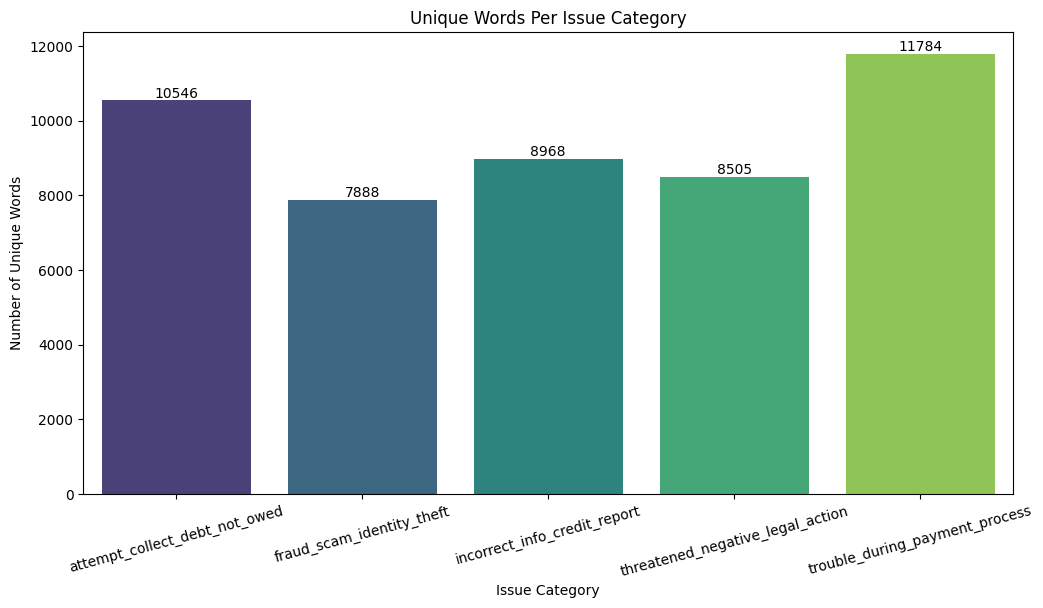

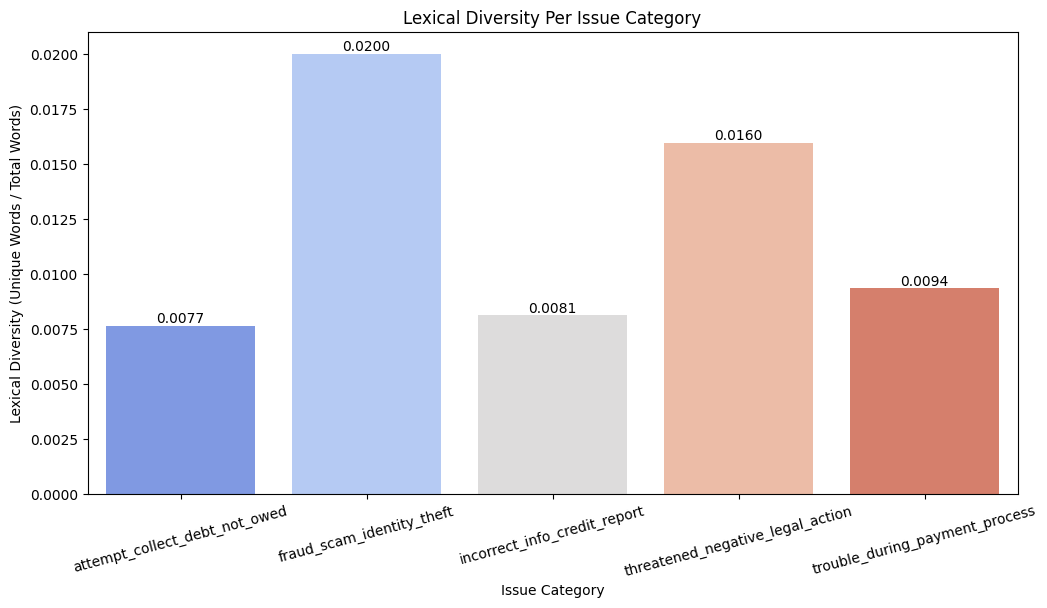

In [34]:
""" Lexical diversity and unique word of each issue category """

# Function to count unique words per issue category
def count_unique_words(token_lists):
    all_words = [word for tokens in token_lists for word in tokens] 
    return len(set(all_words))

# Function to compute lexical diversity per issue category
def lexical_diversity(token_lists):
    all_words = [word for tokens in token_lists for word in tokens]  
    total_words = len(all_words)
    unique_words = len(set(all_words))
    return unique_words / total_words if total_words > 0 else 0  # Avoid division by zero

# Compute unique words and lexical diversity per issue
unique_words_per_issue = data_cleaned.groupby('Issue')['Complaint_cleaned'].apply(count_unique_words)
lexical_diversity_per_issue = data_cleaned.groupby('Issue')['Complaint_cleaned'].apply(lexical_diversity)

# Plot unique words per issue category
plt.figure(figsize=(12, 6))
ax = sb.barplot(x=unique_words_per_issue.index, y=unique_words_per_issue.values, hue=unique_words_per_issue.index, palette='viridis')
plt.legend([],[], frameon=False)  # Hide legend
plt.xticks(rotation=15)
plt.xlabel('Issue Category')
plt.ylabel('Number of Unique Words')
plt.title('Unique Words Per Issue Category')

# Add labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.show()

# Plot lexical diversity per issue category
plt.figure(figsize=(12, 6))
ax2 = sb.barplot(x=lexical_diversity_per_issue.index, y=lexical_diversity_per_issue.values, hue=lexical_diversity_per_issue.index, palette='coolwarm')
plt.legend([],[], frameon=False)  # Hide legend
plt.xticks(rotation=15)
plt.xlabel('Issue Category')
plt.ylabel('Lexical Diversity (Unique Words / Total Words)')
plt.title('Lexical Diversity Per Issue Category')

# Add labels on bars
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.4f}', 
                 (p.get_x() + p.get_width() / 2, p.get_height()), 
                 ha='center', va='bottom', fontsize=10)

plt.show()

<Figure size 1000x600 with 0 Axes>

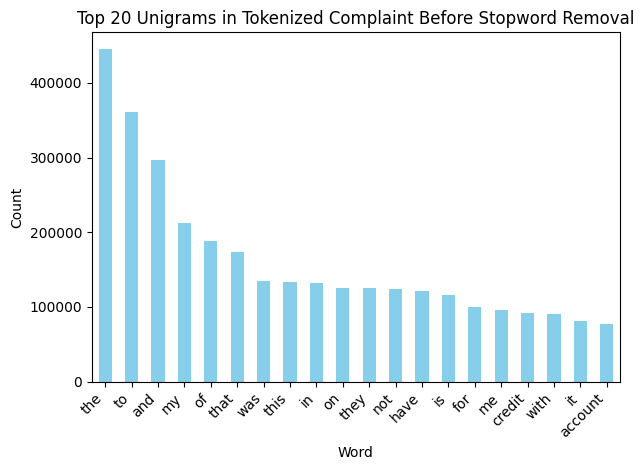

<Figure size 1000x600 with 0 Axes>

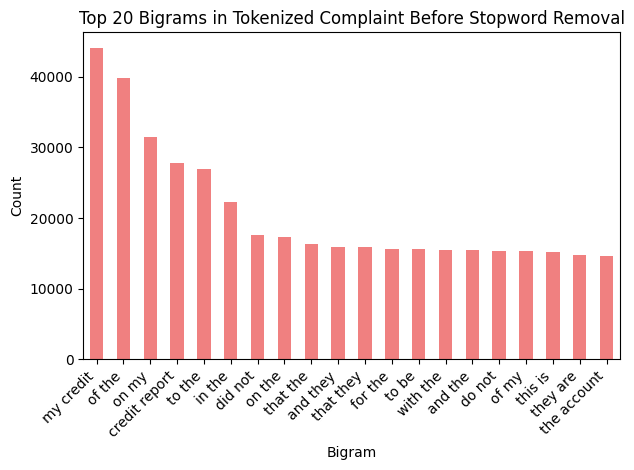

<Figure size 1000x600 with 0 Axes>

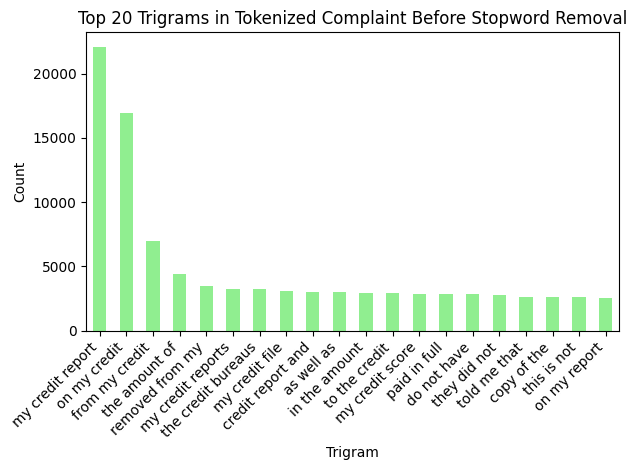

In [35]:
"""" Top 20 unigram, bigram, trigram before stopword removal """

# Function to get top N n-grams from Tokenized_complaint
def get_top_n_ngrams(tokens_list, n=None, ngram_range=(1, 1)):
    # Join tokens into a string for CountVectorizer to process
    corpus = [' '.join(tokens) for tokens in tokens_list]
    
    # Initialize the CountVectorizer with n-gram range (unigram, bigram, trigram)
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)  
    # Transform the tokens into a bag of words and sum
    bag_of_words = vec.transform(corpus)  
    sum_words = bag_of_words.sum(axis=0)  
    ngrams_freq = [(ngram, sum_words[0, idx]) for ngram, idx in vec.vocabulary_.items()]
    ngrams_freq = sorted(ngrams_freq, key=lambda x: x[1], reverse=True)
    return ngrams_freq[:n]

# Get top 20 unigrams
common_words = get_top_n_ngrams(data_cleaned['Tokenized_complaint'], 20, ngram_range=(1, 1))

# Get top 20 bigrams
top_bigrams = get_top_n_ngrams(data_cleaned['Tokenized_complaint'], 20, ngram_range=(2, 2))

# Get top 20 trigrams
top_trigrams = get_top_n_ngrams(data_cleaned['Tokenized_complaint'], 20, ngram_range=(3, 3))

# Convert the list of top 20 words and their frequencies to DataFrames
df_unigrams = pd.DataFrame(common_words, columns=['Word', 'Count'])
df_bigrams = pd.DataFrame(top_bigrams, columns=['Bigram', 'Count'])
df_trigrams = pd.DataFrame(top_trigrams, columns=['Trigram', 'Count'])

# Plot the top 20 unigrams' frequencies as a bar chart
plt.figure(figsize=(10,6))
df_unigrams.sort_values('Count', ascending=False).plot(kind='bar', x='Word', y='Count', color='skyblue', legend=False)
plt.title('Top 20 Unigrams in Tokenized Complaint Before Stopword Removal')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot the top 20 bigrams' frequencies as a bar chart
plt.figure(figsize=(10,6))
df_bigrams.sort_values('Count', ascending=False).plot(kind='bar', x='Bigram', y='Count', color='lightcoral', legend=False)
plt.title('Top 20 Bigrams in Tokenized Complaint Before Stopword Removal')
plt.xlabel('Bigram')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot the top 20 trigrams' frequencies as a bar chart
plt.figure(figsize=(10,6))
df_trigrams.sort_values('Count', ascending=False).plot(kind='bar', x='Trigram', y='Count', color='lightgreen', legend=False)
plt.title('Top 20 Trigrams in Tokenized Complaint Before Stopword Removal')
plt.xlabel('Trigram')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

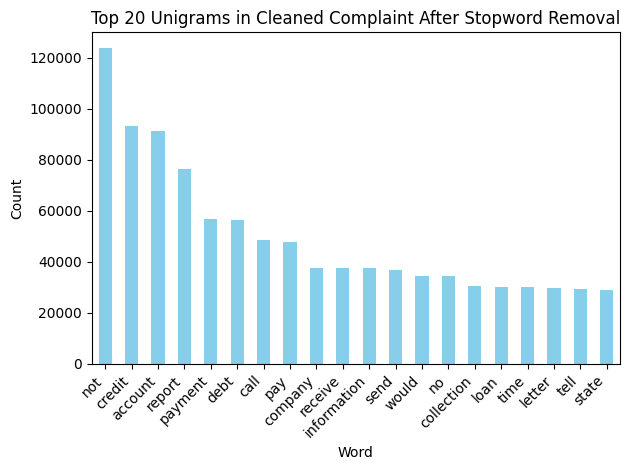

<Figure size 1000x600 with 0 Axes>

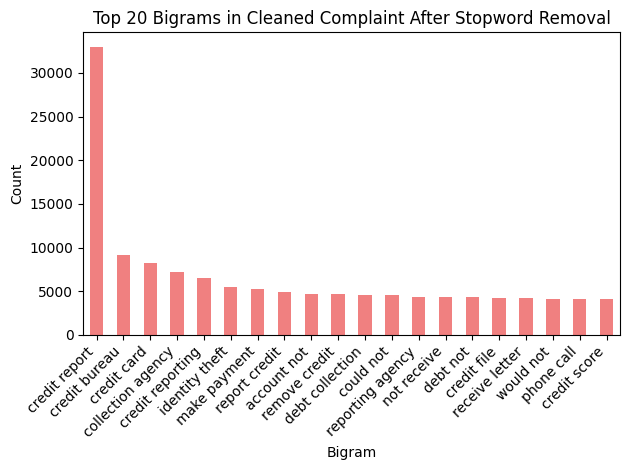

<Figure size 1000x600 with 0 Axes>

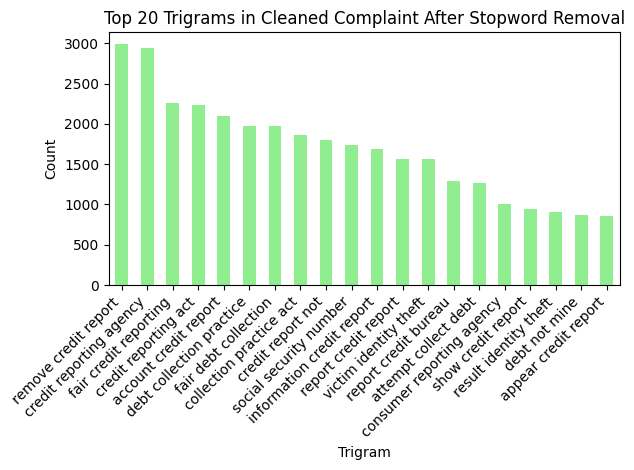

In [36]:
"""" Top 20 unigram, bigram, trigram after stopword removal """

# Function to get top N n-grams from Tokenized_complaint
def get_top_n_ngrams(tokens_list, n=None, ngram_range=(1, 1)):
    # Join tokens into a string for CountVectorizer to process
    corpus = [' '.join(tokens) for tokens in tokens_list]
    
    # Initialize the CountVectorizer with n-gram range (unigram, bigram, trigram)
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)  
    # Transform the tokens into a bag of words and sum
    bag_of_words = vec.transform(corpus)  
    sum_words = bag_of_words.sum(axis=0)  
    ngrams_freq = [(ngram, sum_words[0, idx]) for ngram, idx in vec.vocabulary_.items()]
    ngrams_freq = sorted(ngrams_freq, key=lambda x: x[1], reverse=True)
    return ngrams_freq[:n]

# Get top 20 unigram
common_words = get_top_n_ngrams(data_cleaned['Complaint_cleaned'], 20, ngram_range=(1, 1))

# Get top 20 bigrams
top_bigrams = get_top_n_ngrams(data_cleaned['Complaint_cleaned'], 20, ngram_range=(2, 2))

# Get top 20 trigrams
top_trigrams = get_top_n_ngrams(data_cleaned['Complaint_cleaned'], 20, ngram_range=(3, 3))

# Convert the list of top 20 words and their frequencies to DataFrames
df_unigrams = pd.DataFrame(common_words, columns=['Word', 'Count'])
df_bigrams = pd.DataFrame(top_bigrams, columns=['Bigram', 'Count'])
df_trigrams = pd.DataFrame(top_trigrams, columns=['Trigram', 'Count'])

# Plot the top 20 unigrams' frequencies as a bar chart
plt.figure(figsize=(10,6))
df_unigrams.sort_values('Count', ascending=False).plot(kind='bar', x='Word', y='Count', color='skyblue', legend=False)
plt.title('Top 20 Unigrams in Cleaned Complaint After Stopword Removal')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot the top 20 bigrams' frequencies as a bar chart
plt.figure(figsize=(10,6))
df_bigrams.sort_values('Count', ascending=False).plot(kind='bar', x='Bigram', y='Count', color='lightcoral', legend=False)
plt.title('Top 20 Bigrams in Cleaned Complaint After Stopword Removal')
plt.xlabel('Bigram')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot the top 20 trigrams' frequencies as a bar chart
plt.figure(figsize=(10,6))
df_trigrams.sort_values('Count', ascending=False).plot(kind='bar', x='Trigram', y='Count', color='lightgreen', legend=False)
plt.title('Top 20 Trigrams in Cleaned Complaint After Stopword Removal')
plt.xlabel('Trigram')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


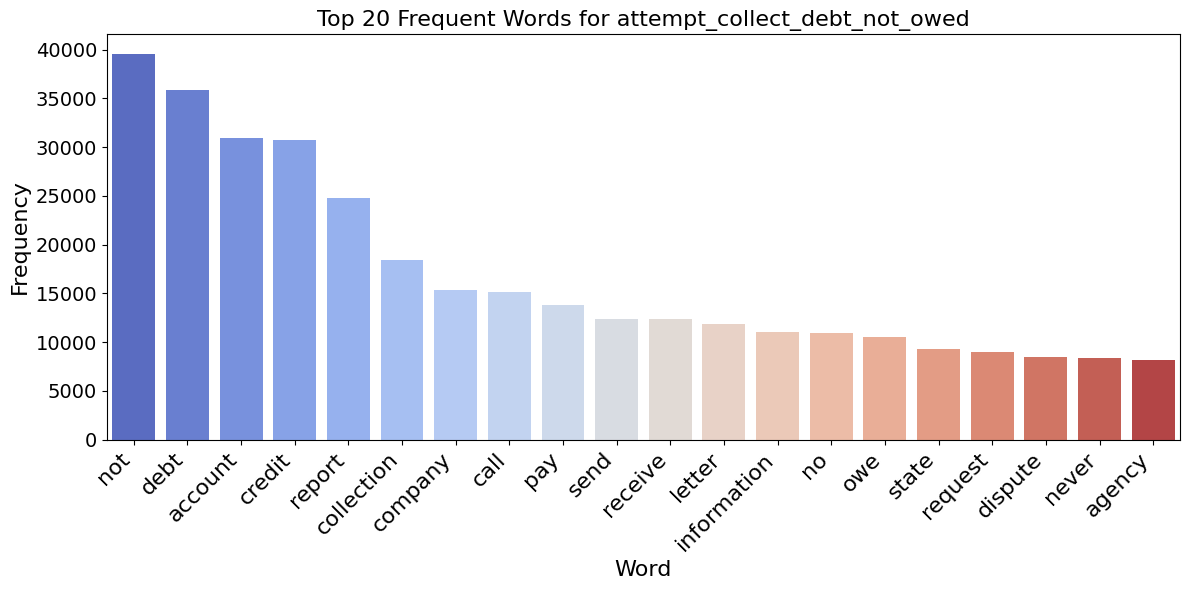

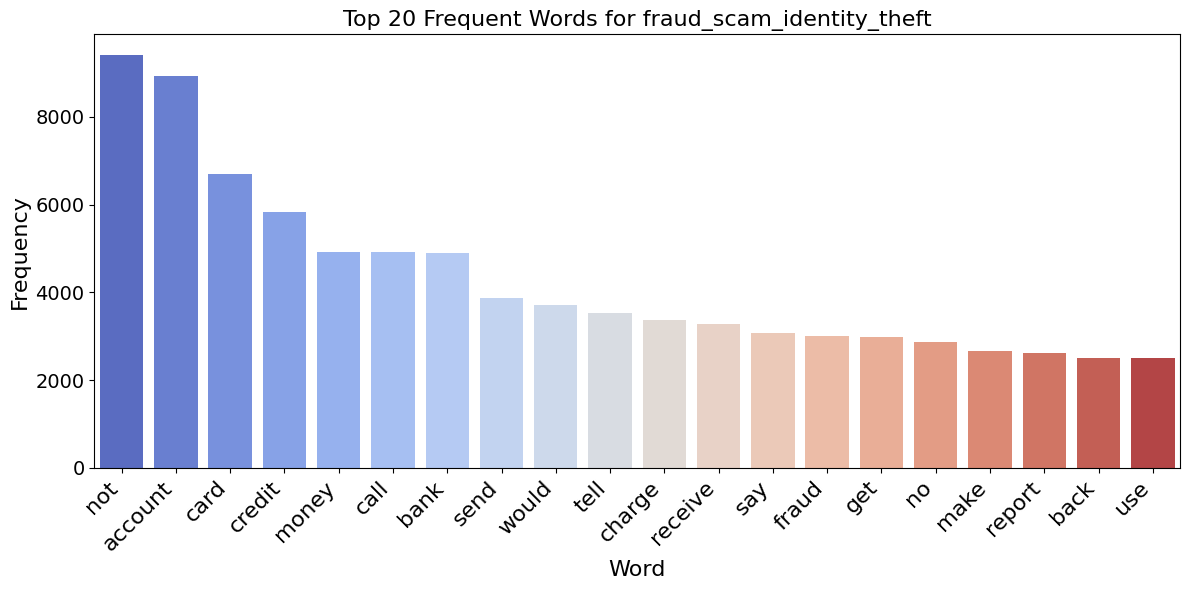

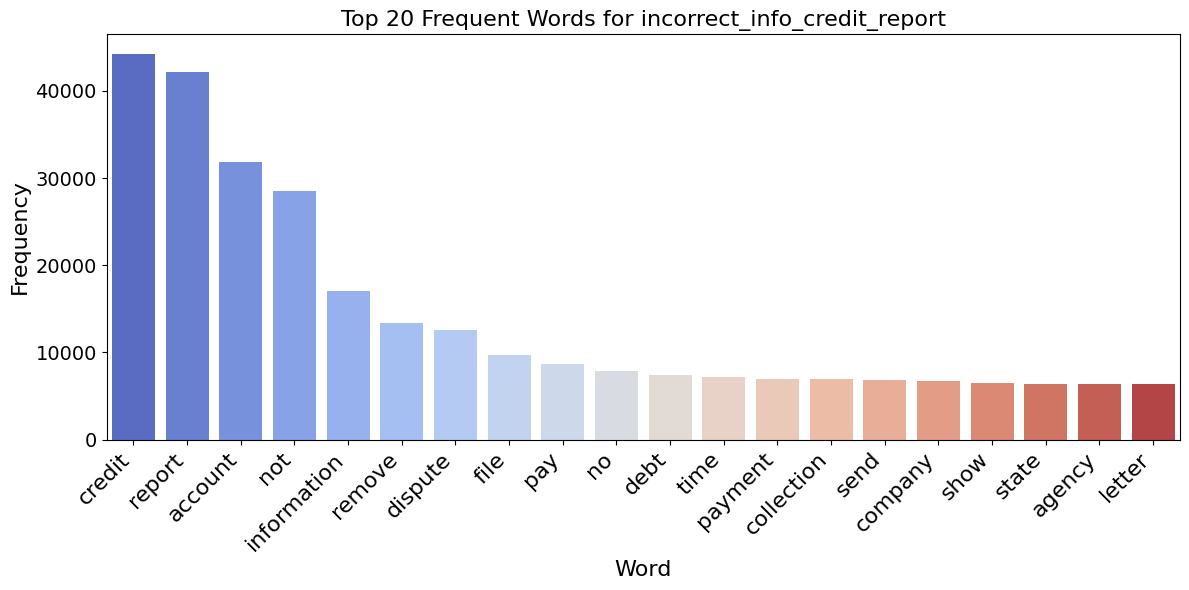

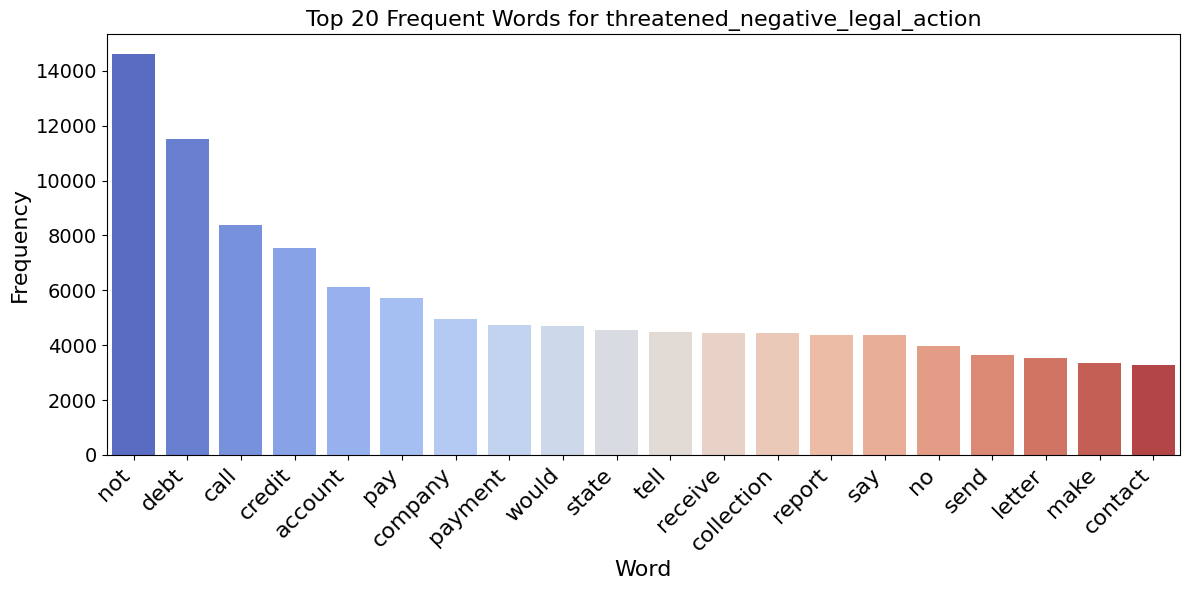

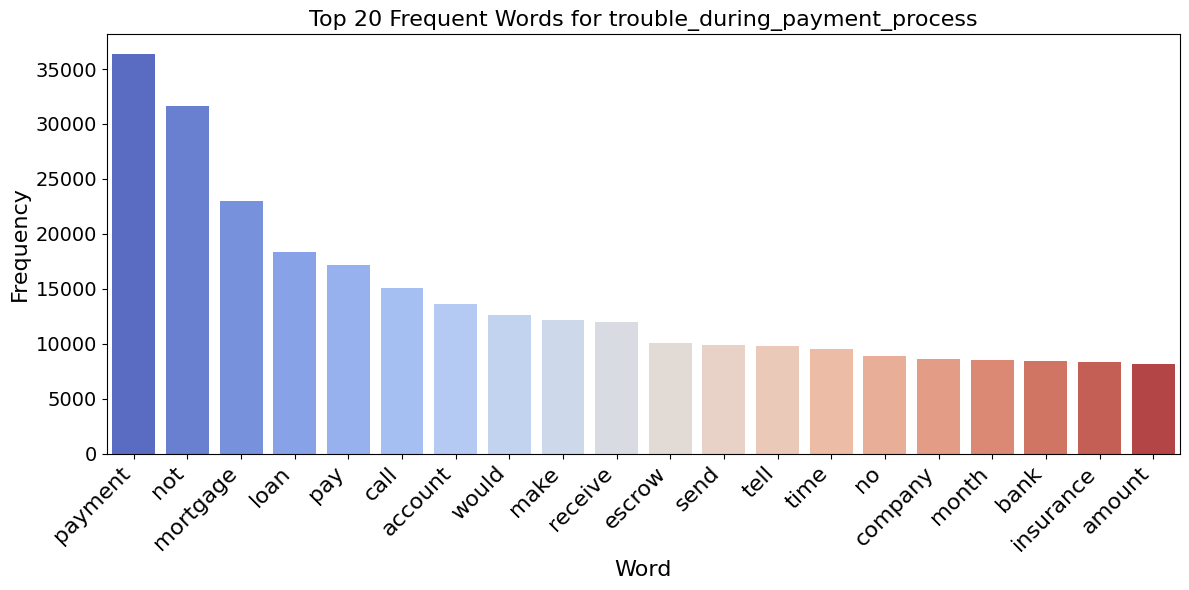

In [37]:
""" Top 20 frequent words for each issue category """

# Get top 20 frequent keywords per issue category
top_unigrams_per_issue = (
    data_cleaned.groupby('Issue')['Complaint_cleaned']
    .apply(lambda x: get_top_n_ngrams(x, 20, ngram_range=(1, 1)))
)

# Convert to DataFrame for easy manipulation
unigram_dfs = []
for issue, unigram_list in top_unigrams_per_issue.items():
    df = pd.DataFrame(unigram_list, columns=['Word', 'Frequency'])
    df['Issue'] = issue
    unigram_dfs.append(df)

unigram_df = pd.concat(unigram_dfs).reset_index(drop=True)

# Plot for each issue
for issue in unigram_df['Issue'].unique():
    issue_df = unigram_df[unigram_df['Issue'] == issue]
    plt.figure(figsize=(12, 6))
    sb.barplot(data=issue_df, x='Word', y='Frequency', hue='Word', palette='coolwarm', legend=False)
    plt.xlabel('Word', fontsize = 16)
    plt.ylabel('Frequency', fontsize = 16)
    plt.title(f'Top 20 Frequent Words for {issue}', fontsize = 16)
    plt.xticks(rotation=45, ha='right', fontsize = 16) 
    plt.yticks(fontsize = 14)
    plt.tight_layout()
    plt.show()

In [38]:
# Make a copy of the data_cleaned
cleaned_data = data_cleaned.copy()
# Drop unnecessary columns to keep only the cleaned tokens and target label
cleaned_data = cleaned_data[['Complaint_cleaned', 'Issue']]

# Save the cleaned dataset as csv file 
cleaned_data.to_csv("cleaned_data.csv", index = False)
print("Successfully saved cleaned_data as csv file.")

Successfully saved cleaned_data as csv file.


In [39]:
# Load and read the saved cleaned_data csv
cleaned_data = pd.read_csv("cleaned_data.csv")
cleaned_data

,Complaint_cleaned,Issue
0,"['start', 'start', 'receive', 'call', 'ability', 'recovery', 'solution', 'regard', 'medical', 'bill', 'claim', 'not', 'pay', 'tell', 'approve', 'si', 'medicaid', 'fight', 'year', 'altogether', 'backdate', 'effective', 'date', 'medicaid', 'back', 'tell', 'call', 'hospital', 'pull', 'account', 'send', 'collection', 'back', 'file', 'medicaid', 'instead', 'hospital', 'bill', 'come', 'tell', 'pull', 'back', 'pay', 'close', 'well', 'start', 'get', 'call', 'collection', 'company', 'say', 'debt', 'pay', 'get', 'rude', 'say', 'send', 'proof', 'might', 'close', 'try', 'communicate', 'get', 'hateful', 'phone', 'towards', 'call', 'hospital', 'bill', 'come', 'say', 'not', 'collect', 'debt', 'try', 'contact', 'refuse', 'take', 'credit', 'report', 'keep', 'call', 'multiple', 'time', 'daily', 'legal', 'action', 'hurt', 'credit', 'credit', 'score', 'drop', 'really', 'low', 'also', 'never', 'send', 'proof', 'mail', 'debt', 'request']",attempt_collect_debt_not_owed
1,"['call', 'loan', 'management', 'service', 'pay', 'amount', 'mail', 'letter', 'payoff', 'amount', 'record', 'fee', 'total', 'amount', 'owe', 'letter', 'receive', 'via', 'mail', 'make', 'online', 'payment', 'via', 'wire', 'pay', 'amount', 'track', 'give', 'see', 'email', 'confirmation', 'money', 'transfer', 'complete', 'money', 'available', 'cashier', 'department', 'loan', 'management', 'bank', 'account', 'need', 'help', 'chat', 'online', 'call', 'toll', 'free', 'thanks', 'use', 'mobile', 'transaction', 'receipt', 'transaction', 'summary', 'online', 'receipt', 'track', 'number', 'transaction', 'date', 'et', 'recd', 'alert', 'credit', 'filing', 'delinquency', 'contact', 'say', 'never', 'receive', 'payment', 'give', 'information', 'receipt', 'submit', 'call', 'numerous', 'time', 'keep', 'say', 'never', 'receive', 'give', 'tracking', 'no', 'one', 'else', 'speak', 'no', 'email', 'address', 'use', 'communicate', 'deliver', 'documentation', 'either', 'fax', 'regular', 'mail', 'no', 'attempt', 'part', 'track', 'receipt', 'say', 'money', 'use', 'information', 'provide', 'rec', 'would', 'another', 'statement', 'date', 'indicate', 'owe', 'call', 'resubmit', 'information', 'regard', 'payment', 'information', 'reply', 'no', 'way', 'track', 'never', 'receive', 'another', 'notification', 'delinquency', 'day', 'another', 'call', 'ask', 'assistance', 'track', 'payment', 'resolve', 'credit', 'reporting', 'still', 'no', 'assistance', 'help', 'therefore', 'go', 'bank', 'rewire', 'another', 'payment', 'resent', 'another', 'wire', 'transfer', 'additional', 'cost', 'also', 'contact', 'record', 'loan', 'management', 'service', 'receive', 'fund', 'trace', 'call', 'give', 'information', 'wire', 'another', 'payment', 'tell', 'call', 'back', 'verify', 'receive', 'call', 'verify', 'payment', 'receive', 'close', 'account', 'ask', 'next', 'step', 'resolve', 'credit', 'reporting', 'also', 'let', 'know', 'receive', 'two', 'payment', 'give', 'additional', 'information', 'bank', 'track', 'record', 'indicate', 'follow', 'need', 'next', 'ask', 'report', 'credit', 'agency', 'reporting', 'account', 'not', 'delinquent', 'affect', 'credit', 'score', 'greatly', 'indicate', 'would', 'send', 'consumer', 'affair', 'department', 'investigation', 'however', 'still', 'investigation', 'offer', 'no', 'customer', 'service', 'assist', 'rectify', 'situation', 'customer', 'call', 'follow', 'tell', 'call', 'mail', 'fax', 'communication', 'wait', 'reply', 'no', 'communication', 'one', 'customer', 'service', 'line', 'unable', 'speak', 'anyone', 'else', 'no', 'supervisor', 'anyone', 'rep', 'phone', 'loan', 'first', 'take', 'account', 'turn', 'loan', 'six', 'year', 'pay', 'mortgage', 'payoff', 'amount', 'company', 'ruin', 'credit', 'make', 'no', 'attempt', 'assist', 'correct', 'problem', 'today', 'additional', 'due', 'double', 'payment', 'not', 'tell', 'payment', 'reissue', 'back', 'no', 'one', 'speak', 'assist', 'resolve', 'issue', 'make', 'every', 'attempt', 'possible', 'rectify', 'situation', 'no', 'assistance

In [ ]:
""" Split cleaned_data dataset into train and test set """

# Perform train-test split (80% train, 20% test)
train_data, test_data = train_test_split(cleaned_data, test_size=0.2, random_state=42)

# Save train-test split as csv file
train_data.to_csv("train_data.csv", index = False)
test_data.to_csv("test_data.csv", index = False)

print("Train-test split done and saved as csv file.")

Train-test split done and saved as csv file.


In [44]:
test_data

,Complaint_cleaned,Issue
12486,"['debt', 'name', 'appear', 'credit', 'report', 'name', 'no', 'account', 'number', 'inaccurate']",attempt_collect_debt_not_owed
28447,"['recently', 'purchase', 'mortgage', 'service', 'right', 'receive', 'letter', 'email', 'direction', 'access', 'mortgage', 'online', 'try', 'repeatedly', 'access', 'mortgage', 'use', 'link', 'week', 'start', 'message', 'pop', 'indicate', 'website', 'could', 'not', 'process', 'request', 'try', 'back', 'later', 'also', 'number', 'website', 'splash', 'screen', 'finally', 'call', 'number', 'entire', 'menu', 'speak', 'luckily', 'live', 'understand', 'well', 'enough', 'push', 'option', 'greet', 'english', 'speaking', 'rep', 'tell', 'aware', 'issue', 'greeting', 'telephone', 'menu', 'say', 'wait', 'receive', 'welcome', 'package', 'mail', 'try', 'call', 'back', 'try', 'resolve', 'issue', 'welcome', 'message', 'still', 'would', 'everyone', 'loan', 'transfer', 'part', 'transaction', 'deal', 'issue', 'no', 'idea', 'correct', 'week', 'elapse', 'first', 'call', 'subsequent', 'call', 'phone', 'number', 'try']",trouble_during_payment_process
26095,"['receive', 'multiple', 'phone', 'call', 'sometimes', 'per', 'day', 'block', 'number', 'spoofed', 'number', 'etc', 'agent', 'dismissive', 'tell', 'debt', 'send', 'error', 'apply', 'receive', 'credit', 'card', 'end', 'use', 'dental', 'work', 'receipt', 'cash', 'payment', 'try', 'call', 'synchrony', 'bank', 'debt', 'seem', 'originate', 'say', 'debt', 'sell', 'not', 'retrieve', 'information', 'would', 'clear', 'name', 'agent', 'company', 'hear', 'information', 'not', 'seem', 'interested', 'repeatedly', 'say', 'want', 'discuss', 'pay', 'try', 'disengage', 'conversation', 'drive', 'child', 'need', 'attention', 'agent', 'firmly', 'try', 'keep', 'attention', 'call']",attempt_collect_debt_not_owed
18091,"['home', 'instal', 'not', 'work', 'right', 'keep', 'connectivity', 'issue', 'contact', 'several', 'time', 'check', 'thing', 'end', 'take', 'time', 'correct', 'time', 'tell', 'want', 'service', 'work', 'right', 'understand', 'eventually', 'get', 'someone', 'home', 'confirm', 'align', 'dish', 'wrong', 'month', 'issue', 'apply', 'new', 'home', 'loan', 'come', 'not', 'know', 'go', 'collection', 'well', 'totally', 'wrong', 'admit', 'installation', 'error', 'level', 'technician', 'waive', 'equipment', 'charge', 'also', 'admit', 'not', 'bill', 'light', 'issue', 'hand', 'learn', 'system', 'inc', 'collection', 'relate', 'error', 'bill', 'pay', 'collection', 'reference', 'bogus', 'immediately', 'remove', 'confirm', 'pay', 'agreed']",attempt_collect_debt_not_owed
7822,"['receive', 'letter', 'frost', 'attempt', 'collect', 'debt', 'spoke', 'ask', 'debt', 'state', 'debt', 'money', 'owe', 'hospital', 'stay', 'reach', 'concern', 'debt', 'explain', 'female', 'insurance', 'suppose', 'cover', 'debt', 'not', 'cover', 'full', 'medicaid', 'would', 'tell', 'call', 'get', 'id', 'number', 'call', 'medicaid', 'provide', 'number', 'also', 'call', 'frost', 'record', 'explain', 'speak', 'original', 'creditor', 'provide', 'medicaid', 'information', 'ask', 'party', 'need', 'follow', 'concern', 'debt', 'say', 'issue', 'would', 'contact', 'via', 'phone', 'email', 'receive', 'alert', 'phone', 'state', 'account', 'collection', 'immediately', 'contact', 'collection', 'agency', 'original', 'creditor', 'hospital', 'everyone', 'record', 'contact', 'concern', 'debt', 'except', 'state', 'late', 'apply', 'medicaid', 'id', 'reach', 'multiple', 'time', 'although', 'not', 'receive', 'communication']",attempt_collect_debt_not_owed
...,...,...
9207,"['may', 'concern', 'victim', 'identity', 'theft', 'result', 'account', 'fraudulently', 'open', 'name', 'ally', 'financial', 'one', 'many', 'account', 'obtain', 'result', 'provide', 'document', 'police', 'report', 'victim', 'advocacy', 'document', 'contact', 'creditor', 'ally', 'financial', 'credit', 'bureau', 'advise', 'not', 'debt', 'late', 'payment', 'information', 'fraudulent', 'account', 'negatively', 'impact', 'credit', 'score', 'unfair', 

In [43]:
train_data

,Complaint_cleaned,Issue
4928,"['law', 'office', 'nelson', 'win', 'judgment', 'amount', 'take', 'step', 'borrow', 'money', 'owe', 'fear', 'husband', 'job', 'go', 'bank', 'send', 'wire', 'transfer', 'full', 'amount', 'document', 'proof', 'transfer', 'complete', 'pay', 'judgment', 'full', 'instruct', 'call', 'complete', 'inform', 'would', 'touch', 'within', 'day', 'would', 'soon', 'satisfaction', 'judgement', 'would', 'file', 'court', 'remove', 'credit', 'contact', 'several', 'occasion', 'speak', 'multiple', 'people', 'leave', 'message', 'superior', 'request', 'time', 'give', 'receipt', 'proof', 'payment', 'satisfaction', 'judgment', 'fulfill', 'end', 'legal', 'requirement', 'promise', 'never', 'actually', 'anything', 'six', 'year', 'still', 'issue', 'not', 'act', 'unable', 'get', 'home', 'loan', 'credit', 'still', 'suffer', 'company', 'seem', 'unconcerned', 'fulfil', 'legal', 'obligation', 'quick', 'threaten', 'take', 'advantage', 'people', 'unaware', 'debt', 'collection', 'law', 'procedure']",threatened_negative_legal_action
43671,"['not', 'duplicate', 'complaint', 'respond', 'back', 'regard', 'letter', 'send', 'consumer', 'relation', 'may', 'concern', 'ref', 'intent', 'file', 'suit', 'violation', 'send', 'previous', 'letter', 'certified', 'mail', 'copy', 'receipt', 'enclose', 'request', 'remove', 'inaccurate', 'information', 'file', 'fail', 'accordingly', 'show', 'judge', 'account', 'inaccurate', 'violate', 'fair', 'credit', 'reporting', 'act', 'ignore', 'request', 'investigate', 'item', 'previous', 'letter', 'send', 'certify', 'mail', 'state', 'reason', 'investigation', 'reason', 'not', 'frivolous', 'way', 'final', 'request', 'not', 'prompt', 'conduct', 'proper', 'investigation', 'account', 'question', 'send', 'proof', 'say', 'investigation', 'file', 'civil', 'suit', 'county', 'court', 'damage', 'take', 'credit', 'seriously', 'lack', 'professionalism', 'assistance', 'unacceptable', 'well', 'aware', 'right', 'intend', 'pursue', 'maximum', 'anticipate', 'response', 'sincerely']",incorrect_info_credit_report
57645,"['find', 'tax', 'lien', 'credit', 'report', 'file', 'state', 'owe', 'year', 'base', 'solely', 'fact', 'license', 'accord', 'average', 'licensee', 'pay', 'state', 'income', 'tax', 'figure', 'owe', 'back', 'tax', 'move', 'resident', 'tax', 'year', 'transaction', 'department', 'indicate', 'license', 'issue', 'non-working', 'status', 'may', 'not', 'perform', 'licensed', 'activity', 'file', 'tax', 'lien', 'place', 'copy', 'passport', 'leave', 'move', 'not', 'resident', 'since', 'transcript', 'show', 'no', 'income', 'also', 'copy', 'license', 'show', 'license', 'status', 'start', 'look', 'job', 'since', 'move', 'false', 'credit', 'report', 'public', 'record', 'make', 'really', 'hard', 'not', 'impossible', 'find', 'decent', 'job', 'know', 'point', 'advice', 'would', 'greatly', 'appreciated', 'thank']",incorrect_info_credit_report
18415,"['agency', 'year', 'ago', 'company', 'run', 'credit', 'card', 'clearly', 'email', 'cancel', 'continue', 'bill', 'need', 'invoice', 'cancel', 'send', 'info', 'collection', 'agency', 'collection', 'agency', 'come', 'keep', 'mind', 'already', 'cancel', 'twice', 'feel', 'like', 'bait', 'tactic', 'require', 'overly', 'difficult', 'cancellation', 'process', 'frustrated', 'already', 'cancel', 'twice']",attempt_collect_debt_not_owed
36765,"['account', 'report', 'credit', 'report', 'open', 'close', 'charge', 'since']",incorrect_info_credit_report
...,...,...
54343,"['report', 'wrong', 'date', 'old', 'bankruptcy', 'already', 'dispute', 'account', 'many', 'time', 'not', 'remove', 'already', 'send', 'proof', 'correct', 'date', 'correct', 'date']",incorrect_info_credit_report
38158,"['paid', 'charge-of', 'account', 'state', 'live', 'statute', 'limitation', 'pay', 'charge-of', 'account', 'year', 'produce', 'signature', 'write', 'contract', 'otherwise', 'year', 'code', 'first', 'delinquency', 'occur', 'report', 'derogatory', 'information', 'violation', 'law', 'persist', 'report', 'account', 'concern', 'sti